# **Billionaires Statistics Dataset - Data Mining Project Course**

## Group Members:

* **Anna Martina Visone** - avisone@unal.edu.co
* **Nicolás Martínez López** - nmartinezl@unal.edu.co
* **Miller Estiven Barrera Gonzalez** - mbarrerag@unal.edu.co
* **Sergio Andres Castro Vargas** - secastrov@unal.edu.co


## Universidad Nacional De Colombia - Bogotá Campus

## Notebook Introduction:
This file contains a comprehensive dataset compiled from various reputable sources, including official reports, government databases, financial institutions, and reputable publications such as Forbes, Bloomberg, and World Bank. The dataset covers a wide range of topics, including wealth distribution, demographic trends, economic indicators, and geographic coordinates.

The data was collected through a combination of manual data collection and automated data extraction techniques. Manual data collection involved researchers and analysts gathering information from official reports, publications, and reputable websites. Automated data extraction techniques, such as web scraping tools and APIs, were also utilized to extract data from online sources in a structured format.

# Libraries

In [ ]:
%pip install requests

In [ ]:
import numpy as np # For linear algebra
import pandas as pd # For reading data (csv file)
import matplotlib.pyplot as plt # For plotting charts
import seaborn as sns # For Data Visualization
from scipy.stats import trim_mean
import requests
import time
import re
from collections import Counter

# Get dataset from kaggle

Main dataset containing 5,000 job listings enriched with AI adoption signals, skill requirements, salary dynamics, and societal risk indicators.

In [ ]:
!curl -L -o /content/billionaires-statistics-dataset.zip\
https://www.kaggle.com/api/v1/datasets/download/endofnight17j03/billionaires-statistics-dataset



  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  139k  100  139k    0     0   174k      0 --:--:-- --:--:-- --:--:--  174k


In [ ]:
!unzip /content/billionaires-statistics-dataset.zip

Archive:  /content/billionaires-statistics-dataset.zip
  inflating: Billionaires Statistics Dataset.csv  


In [ ]:
df = pd.read_csv("/content/Billionaires Statistics Dataset.csv")
df.head()


,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


# Analize data

## Size

In [ ]:
df.shape

(2640, 35)

There are 2640 rows and 35 columns




## Columns description

In [ ]:
df.columns

Index(['rank', 'finalWorth', 'category', 'personName', 'age', 'country',
       'city', 'source', 'industries', 'countryOfCitizenship', 'organization',
       'selfMade', 'status', 'gender', 'birthDate', 'lastName', 'firstName',
       'title', 'date', 'state', 'residenceStateRegion', 'birthYear',
       'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country',
       'gdp_country', 'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'latitude_country', 'longitude_country'],
      dtype='object')

*   **Rank**: The numerical ranking of a person or entity in a list or category.
*   **finalWorth**: The final worth or net worth of a person or entity, typically in terms of monetary value.
*   **category**: The category or classification of a person or entity, such as "entrepreneur", "investor", "celebrity", etc.
*   **personName**: The name of a person.
*   **age**: The age of a person.
*   **country**: The country of residence or origin of a person or entity.
*   **city**: The city of residence or origin of a person or entity.
*   **source**: The source or origin of wealth or fame for a person or entity.
*   **industries**: The industries or sectors in which a person or entity operates or is associated with.
*   **countryOfCitizenship**: The country of citizenship of a person.
*  **organization**: The organization or company with which a person is associated.
*   **selfMade**: Indicates whether a person is self-made or inherited wealth/fame.
*   **status**: "D" represents self-made billionaires (Founders/Entrepreneurs) and "U" indicates inherited or unearned wealth.
*   **gender**: The gender of a person.
*   **birthDate** : The date of birth of a person.
*   **lastName**: The last name or surname of a person.
*  **firstName**: The first name of a person.
*   **title**: The title or honorific used for a person, such as "Mr.", "Mrs.", "Dr.", etc.
*   **date**: The date associated with a particular event or data entry.
*   **state**: The state or region of residence or origin of a person or entity.
*   **residenceStateRegion**: The state or region of residence of a person or entity.
*   **birthYear**: The year of birth of a person.
*   **birthMonth**: The month of birth of a person.
*   **birthDay**: The day of birth of a person.
*   **cpi_country**: Consumer Price Index (CPI) for a specific country.
*   **cpi_change_country**: Change in Consumer Price Index (CPI) for a specific country.
*   **gdp_country**: Gross Domestic Product (GDP) for a specific country.
*   **gross_tertiary_education_enrollment**: Gross tertiary education enrollment rate for a specific country.
*   **gross_primary_education_enrollment_country**: Gross primary education enrollment rate for a specific country.
*   **life_expectancy_country**: Life expectancy for a specific country.
*   **tax_revenue_country_country**: Tax revenue for a specific country.
*   **total_tax_rate_country**: Total tax rate for a specific country.
*   **population_country**: Population of a specific country.
*   **latitude_country**: Latitude coordinates of a specific country.
*   **longitude_country**: Longitude coordinates of a specific country.

## **Data types of columns**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rank                                        2640 non-null   int64  
 1   finalWorth                                  2640 non-null   int64  
 2   category                                    2640 non-null   object 
 3   personName                                  2640 non-null   object 
 4   age                                         2575 non-null   float64
 5   country                                     2602 non-null   object 
 6   city                                        2568 non-null   object 
 7   source                                      2640 non-null   object 
 8   industries                                  2640 non-null   object 
 9   countryOfCitizenship                        2640 non-null   object 
 10  organization

In the previous table, we can observe that our dataset contains different data types across its columns. In total, four main data types can be identified: integers (int64), decimals (float64), categorical values (object), and booleans (bool).

The integer (int64) variables, such as rank and finalWorth, represent discrete numerical values. In the case of rank, it indicates the position of each individual within the billionaires ranking, while finalWorth corresponds to the final net worth of each person.

On the other hand, decimal (float64) variables include attributes such as age, birthYear, cpi_country, and life_expectancy_country.
Categorical (object) variables represent textual information or categories, such as personName, country, industries, gender, and source. These columns describe qualitative characteristics of the billionaires and their context.

Finally, the dataset also contains a boolean (bool) variable, selfMade, which indicates whether the individual's wealth was self-made or inherited.

Additionally, it can be observed that some columns contain missing values, such as organization, title, and state. This suggests that this information is not available for all records and may require treatment during the data cleaning stage.

In [ ]:
df['gdp_country'] = df['gdp_country'].str.replace('$','').replace(',','', regex=True).astype(float)

<Axes: >

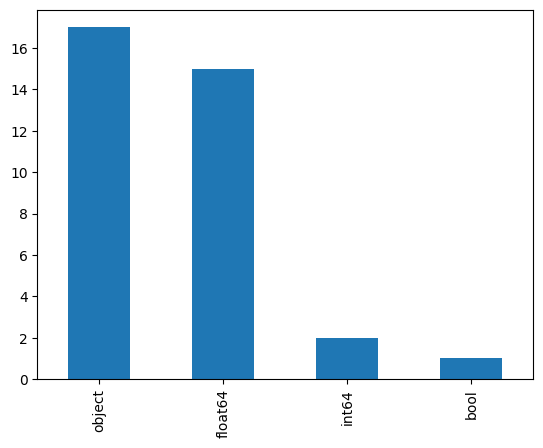

In [ ]:
df.dtypes.value_counts().plot(kind="bar")

Also, we plotted the distribution of the data types in our dataset. We can observe that there are many descriptive variables and numeric variables. However, there are relatively few integer and boolean variables.

## Null values

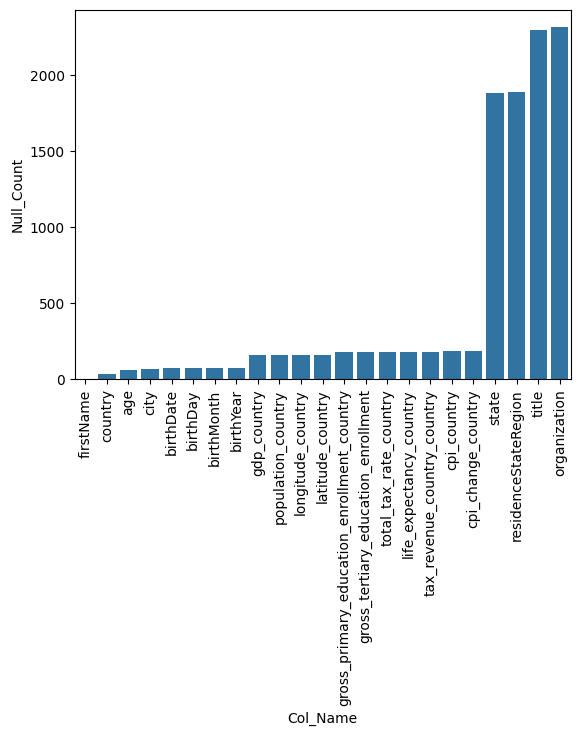

In [ ]:
cols_with_null_values = df.isnull().sum()[df.isnull().sum()>0].sort_values().reset_index()
cols_with_null_values.columns = ['Col_Name', 'Null_Count']

plt.figure(dpi=100)
sns.barplot(data=cols_with_null_values, x='Col_Name', y='Null_Count')
plt.xticks(rotation=90);

## Analysis of categorical variables

We are goint to analyzed each of the categorical columns (18 in total)

In [ ]:
df.describe(include="object")

,category,personName,country,city,source,industries,countryOfCitizenship,organization,status,gender,birthDate,lastName,firstName,title,date,state,residenceStateRegion
count,2640,2640,2602,2568,2640,2640,2640,325,2640,2640,2564,2640,2637,339,2640,753,747
unique,18,2638,78,741,906,18,77,294,6,2,2060,1736,1770,97,2,45,5
top,Finance & Investments,Wang Yanqing & family,United States,New York,Real estate,Finance & Investments,United States,Meta Platforms,D,M,1/1/1965 0:00,Li,John,Investor,4/4/2023 5:01,California,West
freq,372,2,754,99,151,372,735,4,1223,2303,19,44,40,44,2638,178,248


We observe a total of 78 different countries, 741 unique cities, and 906 distinct sources of wealth, spanning more than 18 industries.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(len(categorical_cols))

def plot_categorical_column(column):
    df[column].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categories in {column}")
    plt.ylabel("Count")
    plt.xlabel(column)
    plt.show()

17


### Category

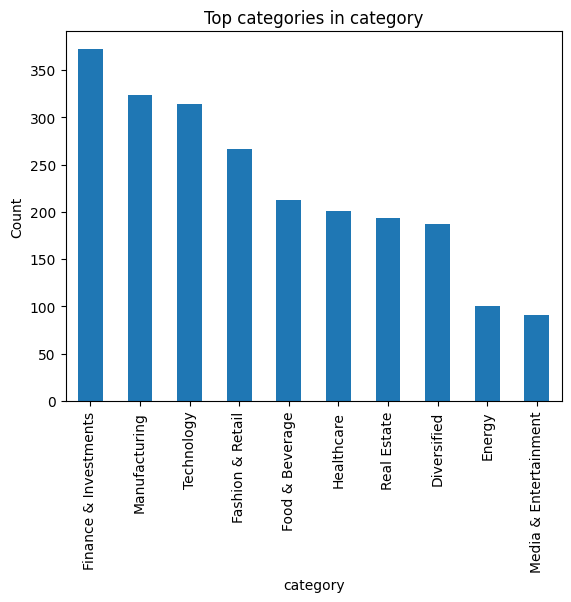

In [ ]:
plot_categorical_column(categorical_cols[0])

We observed that the industries where billionaires are most concentrated are Finance & Investments, Manufacturing, Technology, Fashion & Retail, and Food & Beverage. This suggests that these sectors tend to generate the largest fortunes, likely due to their global market reach, high scalability, and strong economic influence.

### Person Name

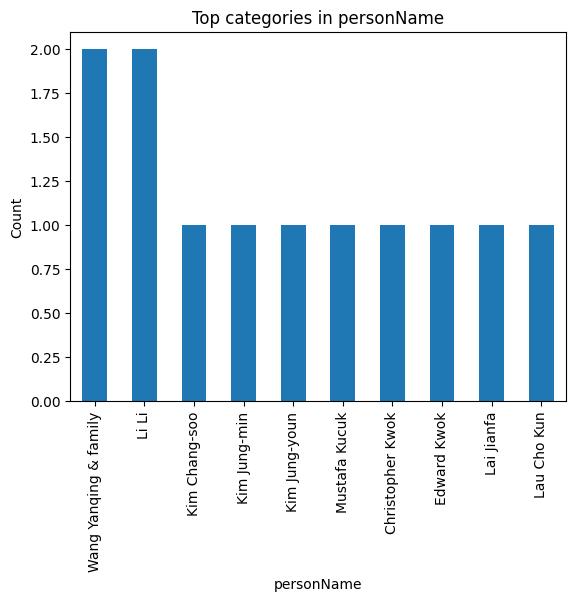

In [ ]:
plot_categorical_column(categorical_cols[1])

The names of individuals are likely not a particularly relevant column for the analysis; however, we noticed that there are two repeated names. We need to make sure that they do not correspond to the same person, and if they do, they should be removed to avoid duplicate records.

### Country

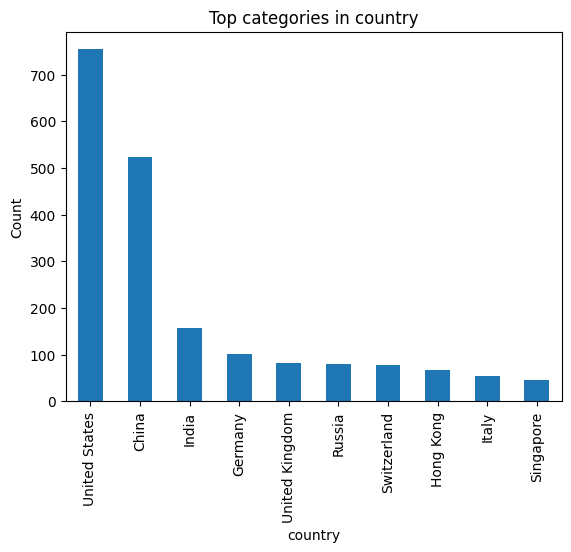

In [ ]:
plot_categorical_column(categorical_cols[2])

In [ ]:
#see how many countries there are
unique_countries = df[categorical_cols[2]].unique()
print(len(unique_countries))


79


We observe that the United States has the largest number of billionaires (more than 700), followed by China (more than 500) and India (more than 150). This pattern may be related to factors such as population size and the scale of their economies.

The United States and China have the largest economies in the world in terms of GDP, which creates more opportunities for large companies, investments, and wealth generation. A larger economy typically supports more industries, financial markets, and technological development, all of which can contribute to the creation of billionaires.

In addition, China and India have extremely large populations, which increases the number of potential entrepreneurs, investors, and business leaders. With larger populations and expanding economies, the probability of generating very high levels of wealth also increases.

Therefore, the high number of billionaires in these countries may reflect a combination of economic size, population scale, and strong business ecosystems, rather than being purely a result of bias in the dataset.

### City

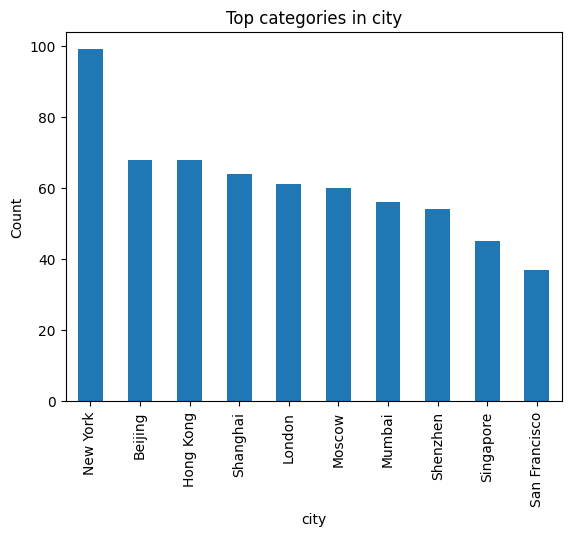

In [ ]:
plot_categorical_column(categorical_cols[3])

We noticed that the cities where billionaires are located are global financial and economic centers. It can be inferred that billionaires tend to live where there are investment opportunities, businesses, and luxury services. We can also observe that urban wealth concentration is focused in cities with advanced infrastructure, business networks, legal and financial services, and large markets.

### Source

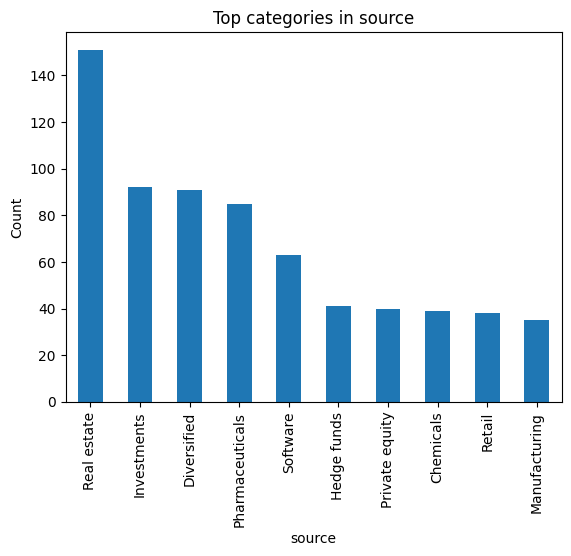

In [ ]:
plot_categorical_column(categorical_cols[4])

That real estate leads with +140 occurrences shows that many billionaires accumulate their wealth through property, highlighting the importance of real estate as a significant wealth generator. Investments and diversified follow, suggesting that another large group of billionaires builds their fortune through financial investments or varied businesses, spreading risks across sectors. Industries like pharmaceuticals and software, though with fewer occurrences, indicate high-value sectors that also create billionaires, reflecting the importance of technological innovation and healthcare in modern wealth accumulation. Overall, this shows that while real estate and traditional investments still dominate, specialized high-value sectors are also key to wealth creation.

### Industries

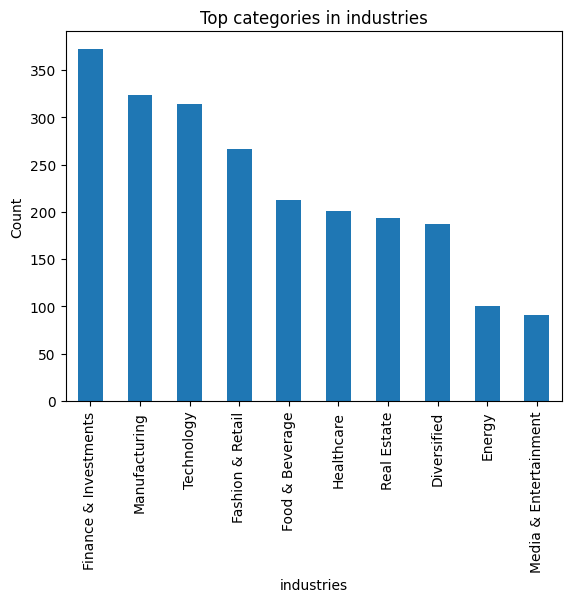

In [ ]:
plot_categorical_column(categorical_cols[5])

It is important to note the difference between **“source”** and **“industries”** when analyzing billionaire data. **“Source”** refers to the primary origin of a billionaire’s wealth, representing the single most significant contributor to their fortune, such as real estate or software. In contrast, **“industries”** lists all sectors where the individual operates or has business interests, which can include multiple areas like finance, technology, or manufacturing.

This explains the discrepancy in the histograms: while real estate dominates as a source of wealth, sectors like Finance & Investments, Manufacturing, and Technology appear more frequently in industries because billionaires often have diversified business activities.

Therefore, when interpreting these variables, it is crucial to keep in mind that **“source” shows the root of wealth, while “industries” reflects the broader economic involvement**.

### Country of Citizenship

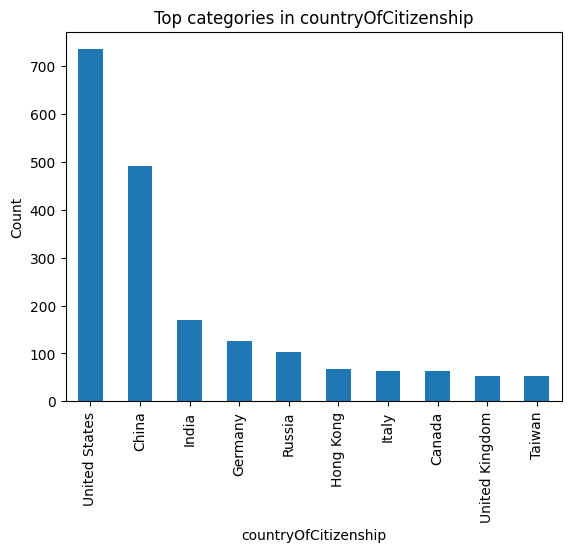

In [ ]:
plot_categorical_column(categorical_cols[6])

It appears that the trend in the data shows that billionaires generally live in the country of which they are citizens. While **“country”** represents the current country of residence and **“countryOfCitizenship”** represents legal citizenship, the histograms show similar patterns, with the United States, India, and China leading.

This suggests that most billionaires tend to reside in their home country, rather than relocating abroad. However, it is important to keep in mind that the two variables are conceptually different and could reveal interesting patterns for those who do live outside their country of citizenship.

### Organization

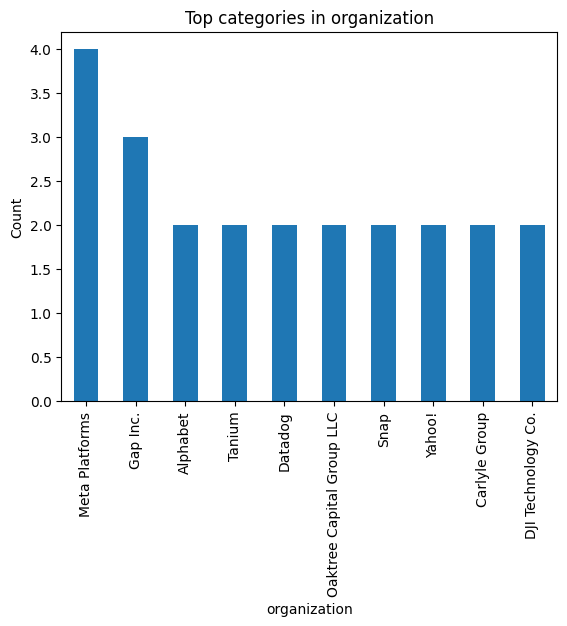

In [ ]:
plot_categorical_column(categorical_cols[7])

The few names that appear, such as Gap Inc or Meta Platforms, are exceptions. The **organization** variable is not representative for the majority of billionaires, and the large number of missing values indicates that wealth is often more personal or dispersed rather than tied to a single corporation.

### Status

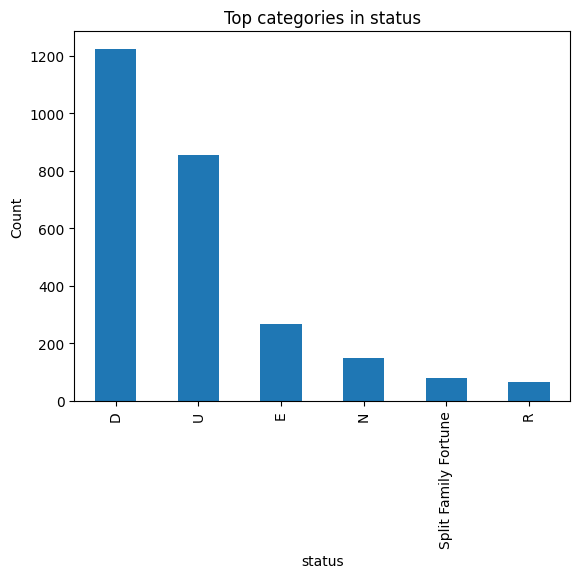

In [ ]:
plot_categorical_column(categorical_cols[8])

The histogram shows that most billionaires are **self-made**, while a smaller portion have **inherited wealth**, indicating that a large share of global wealth today comes from **entrepreneurship and personal creation** rather than inheritance.

Other categories, such as **E, N, R, or Split family fortune**, appear to represent special cases of combined or partially shared family wealth, but without clear definitions, they cannot be analyzed precisely. Overall, this variable confirms that the **majority of billionaires build their fortune through their own efforts**, although inherited wealth still plays a significant role.

### Gender

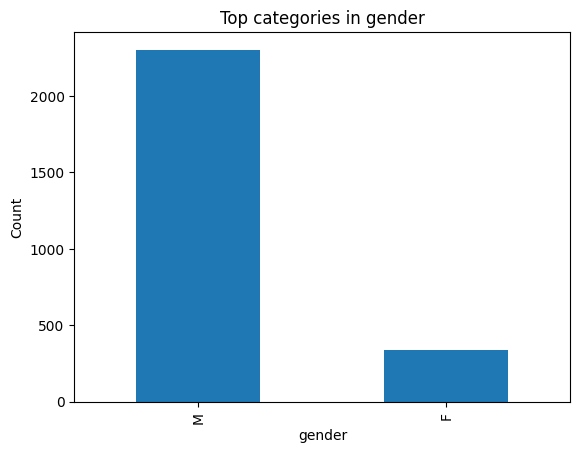

In [ ]:
plot_categorical_column(categorical_cols[9])

The histogram shows a significant gender gap among billionaires, with over 2,300 men compared to around 300 women. This disparity reflects historical and social factors, such as unequal access to education, financing, and business opportunities, rather than differences in ability, highlighting persistent gender inequality in global wealth.

### Birth Date

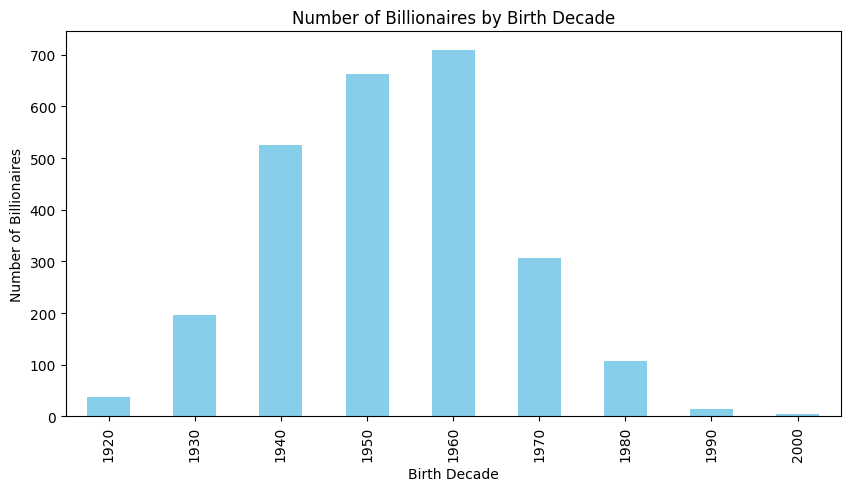

In [ ]:
df_copy = df.copy()

df_copy['birthDate'] = pd.to_datetime(df_copy['birthDate'], format='%m/%d/%Y %H:%M', errors='coerce')
df_copy['birthYear'] = df_copy['birthDate'].dt.year
df_copy['birth_decade'] = (df_copy['birthYear'] // 10 * 10).astype('Int64')
billionaires_by_decade = df_copy['birth_decade'].value_counts().sort_index()

plt.figure(figsize=(10,5))
billionaires_by_decade.plot(kind='bar', color='skyblue')
plt.title('Number of Billionaires by Birth Decade')
plt.xlabel('Birth Decade')
plt.ylabel('Number of Billionaires')
plt.show()

The histogram shows that most billionaires were born in the 1940s, 1950s, and 1960s, suggesting that reaching extreme wealth generally requires time, experience, and years of building businesses or investments.

**The birth years were grouped by decade because the month and day information was not fully reliable. Many records showed birthdays as 1/1, which likely indicates that missing dates were filled with a default value. Grouping by decade allows for a more robust analysis of generational trends among billionaires without being affected by these placeholder dates.**

### Last name

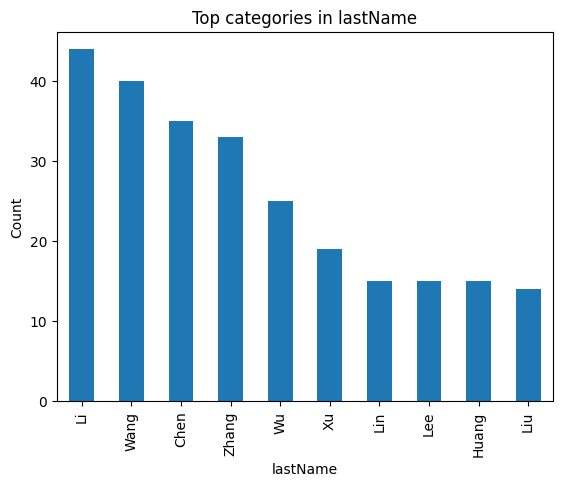

In [ ]:
plot_categorical_column(categorical_cols[11])

The histogram of last names shows that the most common are Li, Wang, and other Chinese or Asian surnames. This is likely due to the large population of China and Asia in general, where these surnames are extremely common. Therefore, the distribution of last names among billionaires probably **reflects global demographics** rather than any economic or wealth-related factor.

### First name

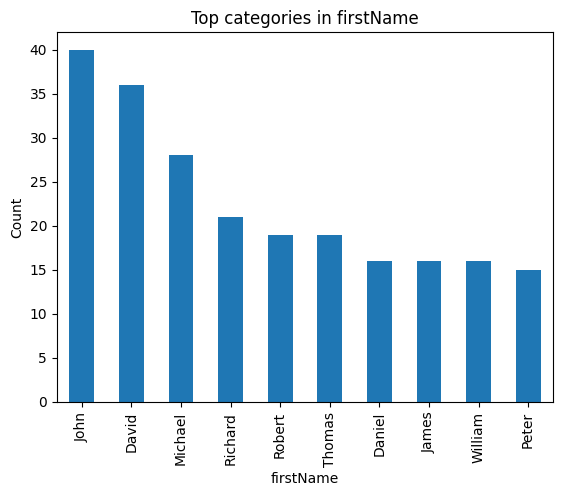

In [ ]:
plot_categorical_column(categorical_cols[12])

The histogram of first names shows that the most common names, such as John, David, Michael, and Richard, are predominantly Western. This reflects the fact that a large share of billionaires reside in Western countries like the United States and Europe. While last names reflect global population demographics, first names indicate the **regional concentration of billionaires in Western countries**.

### Title

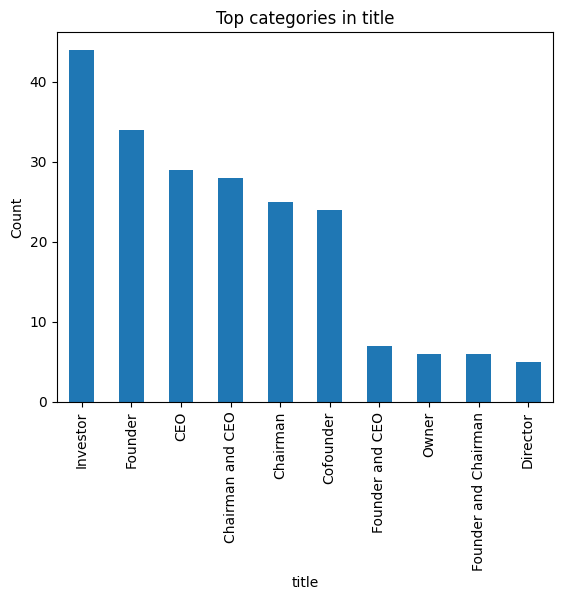

In [ ]:
plot_categorical_column(categorical_cols[13])

The histogram of titles shows a few occurrences such as Investor, Founder, and CEO, but with 2,330 missing values out of 2,640, the variable is largely incomplete. Due to the high number of missing entries, **no meaningful analysis can be conducted** on this variable.

### Date

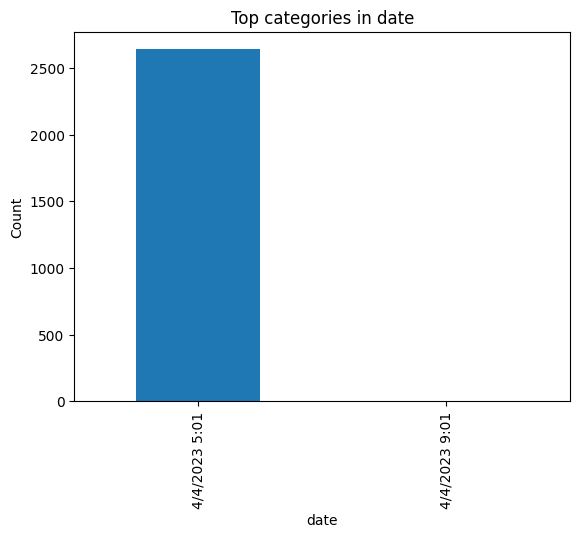

In [ ]:
plot_categorical_column(categorical_cols[14])

This only show us that all data was taken on 4/4/2023

### State

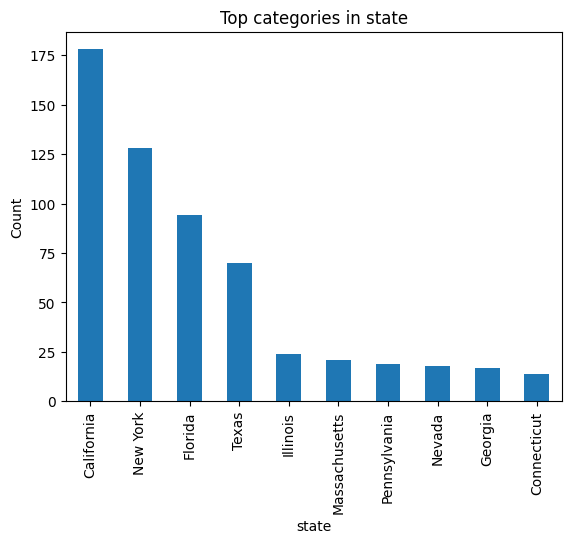

[nan 'Texas' 'Washington' 'Hawaii' 'Nebraska' 'New York' 'California'
 'Kansas' 'Arkansas' 'Oregon' 'Virginia' 'Wyoming' 'Nevada' 'Florida'
 'Pennsylvania' 'Massachusetts' 'Illinois' 'Tennessee' 'Connecticut'
 'Oklahoma' 'Michigan' 'Wisconsin' 'Colorado' 'Indiana' 'New Hampshire'
 'Georgia' 'Missouri' 'New Jersey' 'North Carolina' 'Iowa' 'Kentucky'
 'Maryland' 'Montana' 'Ohio' 'South Carolina' 'Arizona' 'Louisiana' 'Utah'
 'Rhode Island' 'Idaho' 'U.S. Virgin Islands' 'Minnesota' 'Maine'
 'Mississippi' 'South Dakota' 'Alabama']


In [ ]:
plot_categorical_column(categorical_cols[15])
unique_values = df[categorical_cols[15]].unique()

print(unique_values)

The **state** variable only applies to billionaires in the United States. The histogram shows that wealth is highly concentrated, with California (175), New York (125), Florida (90), and Texas (65) leading, while other states have fewer than 20 billionaires each. This reflects the concentration of economic and financial hubs in a few states.

### Residence state region

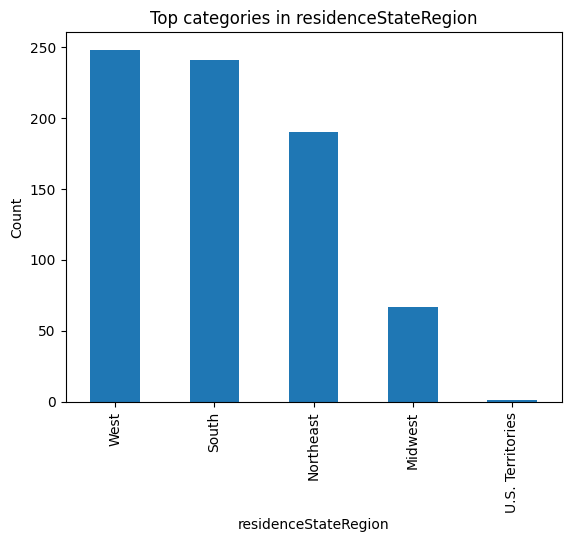

In [ ]:
plot_categorical_column(categorical_cols[16])

The **residenceStateRegion** variable groups U.S. states into larger regions. The histogram shows that most billionaires reside in the West (250) and South (240), followed by the Northeast (190), while the Midwest (50) and U.S. territories (1) have far fewer. This indicates that wealth in the U.S. is concentrated in key economic and technological hubs.

## Analysis of numerical variables

In [ ]:
df.describe().transpose()



,count,mean,std,min,25%,50%,75%,max
rank,2640.0,1.289159e+03,7.396937e+02,1.000000e+00,6.590000e+02,1.312000e+03,1.905000e+03,2.540000e+03
finalWorth,2640.0,4.623788e+03,9.834241e+03,1.000000e+03,1.500000e+03,2.300000e+03,4.200000e+03,2.110000e+05
age,2575.0,6.514019e+01,1.325810e+01,1.800000e+01,5.600000e+01,6.500000e+01,7.500000e+01,1.010000e+02
birthYear,2564.0,1.957183e+03,1.328252e+01,1.921000e+03,1.948000e+03,1.957000e+03,1.966000e+03,2.004000e+03
birthMonth,2564.0,5.740250e+00,3.710085e+00,1.000000e+00,2.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
birthDay,2564.0,1.209984e+01,9.918876e+00,1.000000e+00,1.000000e+00,1.100000e+01,2.100000e+01,3.100000e+01
cpi_country,2456.0,1.277552e+02,2.645295e+01,9.955000e+01,1.172400e+02,1.172400e+02,1.250800e+02,2.885700e+02
cpi_change_country,2456.0,4.364169e+00,3.623763e+00,-1.900000e+00,1.700000e+00,2.900000e+00,7.500000e+00,5.350000e+01
gdp_country,2476.0,1.158287e+13,9.575588e+12,3.154058e+09,1.736426e+12,1.991000e+13,2.142770e+13,2.142770e+13
gross_tertiary_education_enrollment,2458.0,6.722567e+01,2.134343e+01,4.000000e+00,5.060000e+01,6.560000e+01,8.820000e+01,1.366000e+02


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

numeric_cols.remove('rank')
numeric_cols.remove('birthMonth')
numeric_cols.remove('birthDay')

print(numeric_cols)

['finalWorth', 'age', 'birthYear', 'cpi_country', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'population_country', 'latitude_country', 'longitude_country']


We are not going to analize rank because it will not give us important information

In [ ]:
print(df.describe().transpose().shape[0])

17


There are 17 numeric columns

### Final Worth

finalWorth
count      2640.000000
mean       4623.787879
std        9834.240939
min        1000.000000
25%        1500.000000
50%        2300.000000
75%        4200.000000
max      211000.000000
Name: finalWorth, dtype: float64


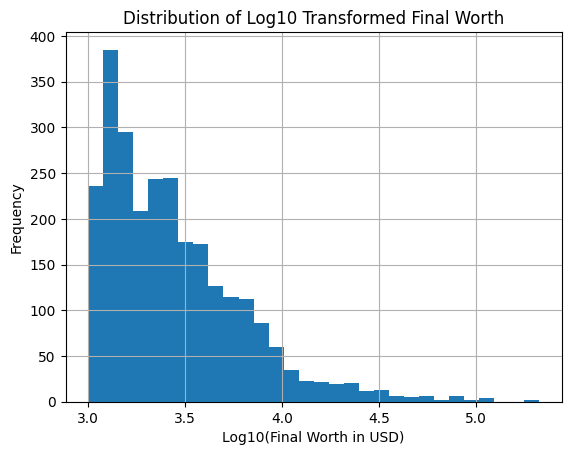

In [ ]:
print(numeric_cols[0])
print(df[numeric_cols[0]].describe())

np.log10(df['finalWorth']).hist(bins=30)

plt.xlabel('Log10(Final Worth in USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Log10 Transformed Final Worth')

plt.show()

The histogram shows a positively skewed (right-skewed) distribution. Most observations are concentrated between 3.0 and 3.5, while the frequency gradually decreases as the values increase. A long tail extends to the right up to approximately 5.2, indicating that a small number of observations have significantly higher values than the majority of the dataset.

### Age

age
count    2575.000000
mean       65.140194
std        13.258098
min        18.000000
25%        56.000000
50%        65.000000
75%        75.000000
max       101.000000
Name: age, dtype: float64
Mode of age: [60.0]
Robust mean of age (trimmed 10%): 65.76704545454545


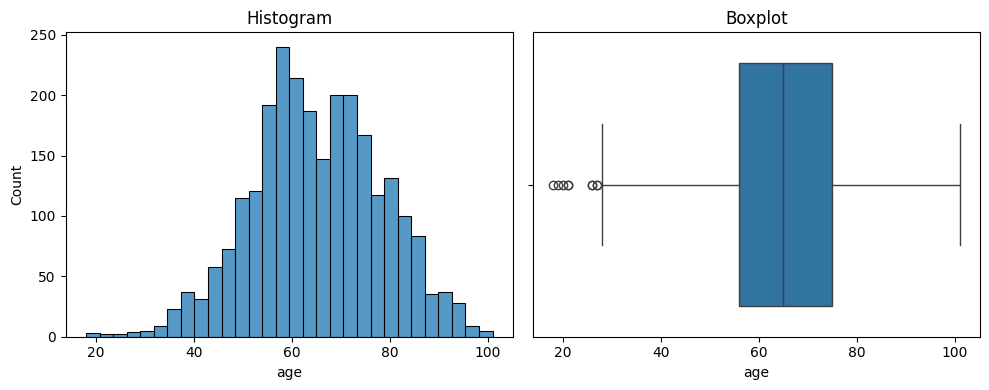

In [ ]:
print(numeric_cols[1])
print(df[numeric_cols[1]].describe())
mode_age = df[numeric_cols[1]].mode()
print(f"Mode of {numeric_cols[1]}: {mode_age.tolist()}")
robust_mean = trim_mean(df[numeric_cols[1]], proportiontocut=0.1)
print(f"Robust mean of {numeric_cols[1]} (trimmed 10%): {robust_mean}")

fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)

# Histograma
sns.histplot(data=df, x=numeric_cols[1], ax=ax[0])
ax[0].set_title("Histogram")

# Boxplot
sns.boxplot(data=df, x=numeric_cols[1], ax=ax[1])
ax[1].set_title("Boxplot")

plt.tight_layout()
plt.show()



1. The mean age is **65.14 years**, indicating that most billionaires are in their mid-60s. This aligns with the idea that accumulating extreme wealth usually takes decades of career and investment experience.

2. The standard deviation is **13.26**, showing a moderate spread around the mean. While most billionaires are clustered around 65, there is a considerable range of ages.

3. **Minimum age:** 18 years — some very young billionaires exist, likely from tech startups or inheritance.  
   **Maximum age:** 101 years — extremely wealthy individuals can maintain influence or assets well into old age.

4. **25th percentile:** 56 years  
   **Median (50th percentile):** 65 years  
   **75th percentile:** 75 years  
   This shows that **50% of billionaires are between 56 and 75 years old**, confirming that the majority are middle-aged to older adults.

5. The most common age (mode) is **60 years**, which aligns closely with the mean and median, suggesting a roughly symmetric distribution without extreme skew.

6. The **robust mean (trimmed 10%)** is **65.77 years**, slightly higher than the regular mean. This indicates that extremely young or extremely old billionaires slightly lower the overall mean, but the robust mean confirms the typical billionaire age is still mid-60s.

**Conclusion:** The age distribution shows that most billionaires are experienced adults in their 50s to 70s, reflecting the time required to build significant wealth. Young billionaires (18–30) are rare and often concentrated in tech or inherited wealth, while super-elderly billionaires (>90) are exceptions. Overall, the data suggests that extreme wealth is usually accumulated over decades, with a peak around the 60s.

### Birth Year

birthYear
count    2564.000000
mean     1957.183307
std        13.282516
min      1921.000000
25%      1948.000000
50%      1957.000000
75%      1966.000000
max      2004.000000
Name: birthYear, dtype: float64
Mode of birthYear: [1962.0]
Robust mean of birthYear (trimmed 10%): 1957.7253787878788


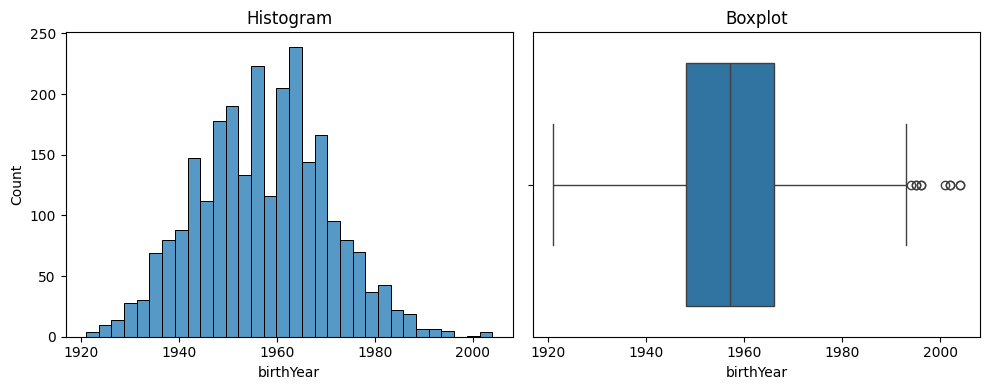

In [ ]:
column = numeric_cols[2]
print(column)
print(df[column].describe())
mode_age = df[column].mode()
print(f"Mode of {column}: {mode_age.tolist()}")
robust_mean = trim_mean(df[column], proportiontocut=0.1)
print(f"Robust mean of {column} (trimmed 10%): {robust_mean}")

fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)

# Histograma
sns.histplot(data=df, x=column, ax=ax[0])
ax[0].set_title("Histogram")

# Boxplot
sns.boxplot(data=df, x=column, ax=ax[1])
ax[1].set_title("Boxplot")

plt.tight_layout()
plt.show()


1. The dataset contains **2,564 billionaires** with recorded birth year, providing a solid sample for analyzing age trends.

2. The mean birth year is **1957.18**, which corresponds roughly to people in their mid-60s today, consistent with the average age of billionaires.

3. The standard deviation is **13.28**, indicating a moderate spread in birth years. Most billionaires were born between the late 1940s and mid-1960s.

4. **Earliest birth year:** 1921 — a few very elderly billionaires remain active or listed.  
   **Latest birth year:** 2004 — some very young billionaires exist, often from inheritance or recent tech ventures.

5. **25th percentile:** 1948  
   **Median (50th percentile):** 1957  
   **75th percentile:** 1966  
   This shows that **50% of billionaires were born between 1948 and 1966**, meaning most are middle-aged to older adults.

6. The most common birth year (mode) is **1962**, which aligns closely with the mean and median, suggesting a fairly symmetric distribution.

7. The **robust mean (trimmed 10%)** is **1957.73**, slightly higher than the regular mean. This confirms that extreme birth years (very young or very old) have minimal impact, and the typical billionaire was born around 1957.

**Conclusion:** The birth year distribution reflects that most billionaires are from the **Baby Boomer and early Generation X cohorts**. Younger billionaires are rare and typically result from tech startups or inheritance, while older billionaires are exceptions. Overall, wealth accumulation tends to favor those born in the mid-20th century, correlating with their current age in the 50s to 70s.

### Variables per country

In [ ]:
# Seleccionar country + columnas numéricas de interés
columns_to_keep = ['country'] + numeric_cols[3:12]

# Crear el DataFrame con solo esas columnas
data_per_country = df[columns_to_keep].copy()

# Eliminar filas donde todas las columnas numéricas sean NaN
data_per_country = data_per_country.dropna(subset=numeric_cols[3:12], how='all')

# Mantener solo un registro por país
data_per_country = data_per_country.drop_duplicates(subset='country', keep='first')


# Ordenar por país y resetear índices
data_per_country = data_per_country.sort_values('country').reset_index(drop=True)

# Revisar los primeros registros
data_per_country.head()




,country,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country
0,Algeria,151.36,2.0,1.699882e+11,51.4,109.9,76.7,37.2,66.1,43053054.0
1,Andorra,NaN,NaN,3.154058e+09,NaN,106.4,NaN,NaN,NaN,77142.0
2,Argentina,232.75,53.5,4.496634e+11,90.0,109.7,76.5,10.1,106.3,44938712.0
3,Armenia,129.18,1.4,1.367280e+10,54.6,92.7,74.9,20.9,22.6,2957731.0
4,Australia,119.80,1.6,1.392681e+12,113.1,100.3,82.7,23.0,47.4,25766605.0


In [ ]:
data_per_country.shape

(68, 10)

In [ ]:
#how many countries there are
unique_countries = data_per_country['country'].unique()
print(len(unique_countries))

68


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean

def describe_column(df, column):
    data_clean = df[column].dropna()


    print(f"=== Descriptive statistics for {column} ===")
    print(data_clean.describe())

    mad_value = np.mean(np.abs(data_clean - data_clean.mean()))
    print(f"Mean Absolute Deviation of {column}: {mad_value}")


    median_value = data_clean.median()
    print(f"Median of {column}: {median_value}")

    # Moda
    mode_val = data_clean.mode()
    print(f"Mode of {column}: {mode_val.tolist()}")

    # Media robusta (trimmed 10%)
    robust_mean_val = trim_mean(data_clean, proportiontocut=0.1)
    print(f"Robust mean of {column} (trimmed 10%): {robust_mean_val}")

def plot_boxplot(df, column, units=None):
    # Crear copia limpia
    data_clean = df[['country', column]].drop_duplicates(subset='country').dropna(subset=[column])

    plt.figure(figsize=(10,4))
    sns.boxplot(data=data_clean, x=column)

    # Agregar unidades al título si se pasan
    if units:
        plt.title(f"Boxplot of {column} ({units}) by Country")
    else:
        plt.title(f"Boxplot of {column} by Country")

    plt.show()


def get_outliers(df, column):
    data_clean = df[['country', column]].drop_duplicates(subset='country').dropna(subset=[column])

    # Calcular IQR
    Q1 = data_clean[column].quantile(0.25)
    Q3 = data_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar outliers
    outliers = data_clean[(data_clean[column] < lower_bound) |
                          (data_clean[column] > upper_bound)][['country', column]]

    return outliers

#### CPI country (Consumer price index per country)

=== Descriptive statistics for cpi_country ===
count    2456.000000
mean      127.755204
std        26.452951
min        99.550000
25%       117.240000
50%       117.240000
75%       125.080000
max       288.570000
Name: cpi_country, dtype: float64
Mean Absolute Deviation of cpi_country: 17.17845418121148
Median of cpi_country: 117.24
Mode of cpi_country: [117.24]
Robust mean of cpi_country (trimmed 10%): 122.44805188199389
-- Outliers --
        country  cpi_country
124     Nigeria       267.51
309       Egypt       288.57
444     Ukraine       281.66
498      Turkey       234.44
554   Argentina       232.75
1654    Uruguay       202.92


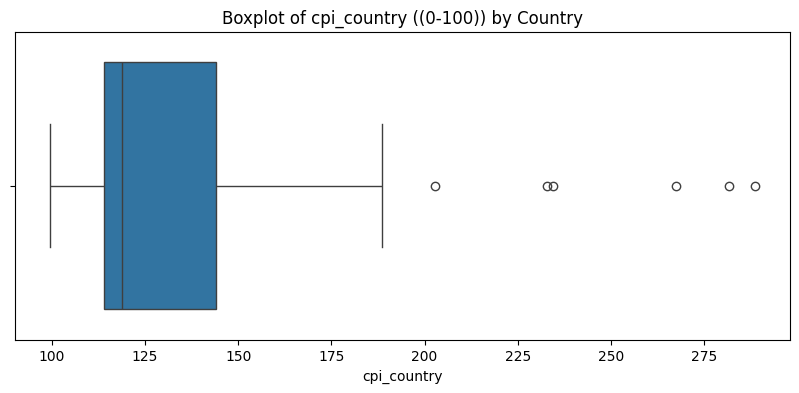

In [ ]:
column = numeric_cols[3]
units = "(0-100)"

describe_column(df, column)

outliers_cpi = get_outliers(df, column)
print("-- Outliers --")
print(outliers_cpi)

plot_boxplot(df, column, units=units)

1. The dataset contains **2,456 countries** (or entries per country) with recorded CPI values, which is a sufficient sample for analysis.

2. The mean CPI is **127.76**, indicating that on average, countries in this dataset have moderate CPI levels.  

3. The standard deviation is **26.45**, showing some variability in CPI values among countries, but not extreme for most.  

4. **Minimum CPI:** 99.55 — the lowest level recorded, indicating countries with relatively lower purchasing power or economic performance.  
   **Maximum CPI:** 288.57 — the highest value, which is an outlier compared to the majority.

5. **Quartiles:**  
   - 25th percentile: 117.24  
   - Median (50th percentile): 117.24  
   - 75th percentile: 125.08  
   This shows that **50% of countries have CPI values between 117.24 and 125.08**, meaning most countries are clustered around the lower-middle range.

6. The most common CPI value (mode) is **117.24**, aligning with the median, suggesting a concentration around this value.

7. The **robust mean (trimmed 10%)** is **127.09**, slightly lower than the regular mean, indicating that extreme high CPIs are affecting the average, but not dramatically.

8. **Outliers:**  
   The following countries have unusually high CPI values compared to the rest:  
   - Argentina: 232.75  
   - Egypt: 288.57  
   - Nigeria: 267.51  
   - Turkey: 234.44  
   - Ukraine: 281.66  
   - Uruguay: 202.92  
   These outliers indicate countries with **exceptionally high CPI**, which might reflect unique economic conditions or reporting differences.  

**Conclusion:**  
Most countries have CPI values clustered around **117–125**, representing typical levels. However, several countries stand out as outliers with extremely high CPI, which could influence mean-based analyses. These outliers should be considered carefully in further analysis, especially when comparing CPI with other economic indicators of billionaires.

#### CPI Change country

=== Descriptive statistics for cpi_change_country ===
count    2456.000000
mean        4.364169
std         3.623763
min        -1.900000
25%         1.700000
50%         2.900000
75%         7.500000
max        53.500000
Name: cpi_change_country, dtype: float64
Mean Absolute Deviation of cpi_change_country: 2.8005989453469002
Median of cpi_change_country: 2.9
Mode of cpi_change_country: [7.5]
Robust mean of cpi_change_country (trimmed 10%): 4.262105798575788
-- Outliers --
        country  cpi_change_country
8         India                 7.7
124     Nigeria                11.4
309       Egypt                 9.2
444     Ukraine                 7.9
498      Turkey                15.2
554   Argentina                53.5
1654    Uruguay                 7.9


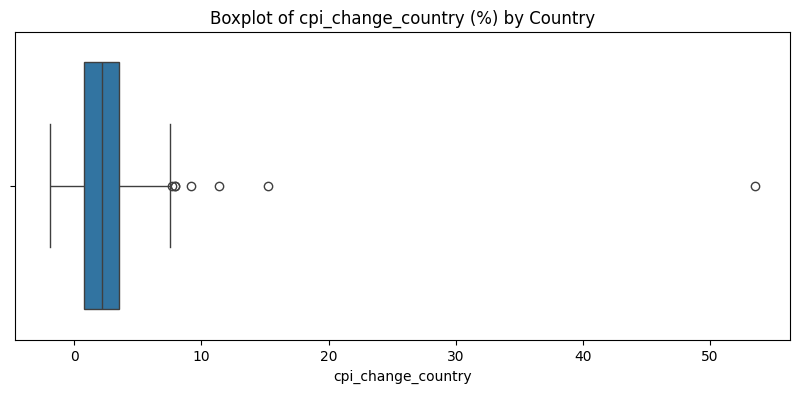

In [ ]:
column = numeric_cols[4]

describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "%" )


1. The dataset contains **2,456 entries** with recorded CPI change values for different countries, which is a sufficient sample for analysis.

2. The mean CPI change is **4.36%**, indicating that on average, countries are experiencing moderate inflation.

3. The standard deviation is **3.62**, showing that there is some variability in CPI changes between countries. Most countries have a moderate rate of inflation, but there are some with much higher values.

4. **Minimum CPI change:** -1.9% — a few countries experienced slight deflation.  
   **Maximum CPI change:** 53.5% — a clear outlier, representing extremely high inflation (Argentina).

5. **Quartiles:**  
   - 25th percentile: 1.7%  
   - Median (50th percentile): 2.9%  
   - 75th percentile: 7.5%  
   This shows that **50% of countries have CPI changes between 1.7% and 7.5%**, indicating that most countries have low to moderate inflation.

6. The most common CPI change (mode) is **7.5%**, which aligns with the upper quartile, suggesting that moderate inflation is frequent but there are countries with lower or higher changes as well.

7. The **robust mean (trimmed 10%)** is **4.56%**, slightly higher than the regular mean, indicating that extreme values like Argentina’s very high inflation affect the average but not dramatically.

8. **Outliers:**  
   The following countries have unusually high CPI changes:  
   - Argentina: 53.5%  
   - Egypt: 9.2%  
   - India: 7.7%  
   - Nigeria: 11.4%  
   - Turkey: 15.2%  
   - Ukraine: 7.9%  
   - Uruguay: 7.9%  
   These outliers indicate countries with **significantly higher inflation** than most others, which may impact the economy, purchasing power, and investment conditions.

**Conclusion:**  
Most countries experience **moderate inflation**, with CPI changes clustering around 1.7–7.5%. However, a few countries have extreme values, especially Argentina, which could distort averages and economic analysis. Understanding CPI change is important for assessing the **economic environment in which billionaires operate**, as high inflation can reduce real wealth while stable inflation favors predictable economic growth.

=== Descriptive statistics for gdp_country ===
count    2.476000e+03
mean     1.158287e+13
std      9.575588e+12
min      3.154058e+09
25%      1.736426e+12
50%      1.991000e+13
75%      2.142770e+13
max      2.142770e+13
Name: gdp_country, dtype: float64
Mean Absolute Deviation of gdp_country: 9513801769702.879
Median of gdp_country: 19910000000000.0
Mode of gdp_country: [21427700000000.0]
Robust mean of gdp_country (trimmed 10%): 11763389339807.875
-- Outliers --
            country   gdp_country
0            France  2.715518e+12
1     United States  2.142770e+13
8             India  2.611000e+12
14            China  1.991000e+13
26          Germany  3.845630e+12
38            Japan  5.081770e+12
39   United Kingdom  2.827113e+12
156           Italy  2.001244e+12
165          Brazil  1.839758e+12
190     South Korea  2.029000e+12


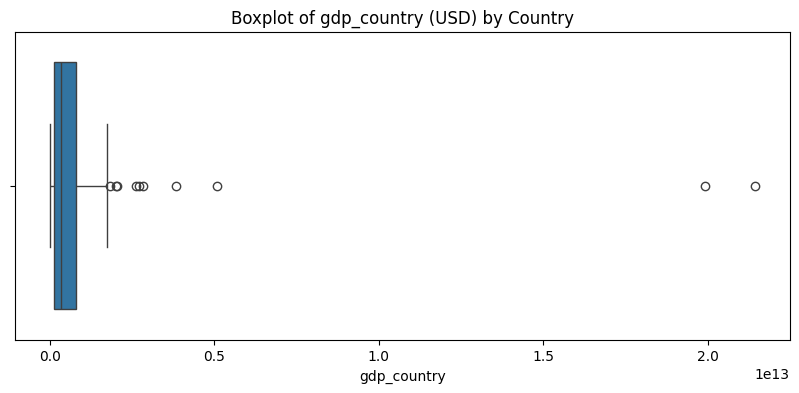

In [ ]:
column = numeric_cols[5]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "USD" )


1. The dataset contains **2,476 country entries** with recorded GDP values, providing a solid basis for analysis.

2. The mean GDP is approximately **1.16 × 10¹³**, indicating that the average economic size among countries in the dataset is large, but there is high variability.

3. The standard deviation is **9.58 × 10¹²**, which is very high, showing that GDP values vary significantly across countries.

4. **Minimum GDP:** 3.15 × 10⁹ — representing small economies.  
   **Maximum GDP:** 2.14 × 10¹³ — representing very large economies like the United States and China.

5. **Quartiles:**  
   - 25th percentile: 1.74 × 10¹²  
   - Median (50th percentile): 1.99 × 10¹³  
   - 75th percentile: 2.14 × 10¹³  
   This indicates that **half of the countries have GDPs between 1.74 × 10¹² and 2.14 × 10¹³**, but extreme high values push the median upward.

6. The most common GDP value (mode) is **2.14 × 10¹³**, which aligns with the maximum, showing that a few very large economies dominate the distribution.

7. The **robust mean (trimmed 10%)** is approximately **1.18 × 10¹³**, slightly lower than the raw mean, indicating that the extreme high GDPs (like the US and China) inflate the average.

8. **Outliers:**  
   The following countries have exceptionally high GDP compared to the rest:  
   - France: 2.72 × 10¹²  
   - United States: 2.14 × 10¹³  
   - India: 2.61 × 10¹²  
   - China: 1.99 × 10¹³  
   - Germany: 3.85 × 10¹²  
   - Japan: 5.08 × 10¹²  
   - United Kingdom: 2.83 × 10¹²  
   - Italy: 2.00 × 10¹²  
   - Brazil: 1.84 × 10¹²  
   - South Korea: 2.03 × 10¹²  

These outliers represent the **largest economies in the world**, which naturally have GDP values far above most other countries.

**Conclusion:**  
While the majority of countries have moderate GDP values, a few countries with very high GDP (like the US, China, Japan, Germany) act as outliers and heavily influence the mean. Understanding GDP outliers is crucial when analyzing **billionaire wealth** in relation to the size of the economy, as most billionaires are likely concentrated in these high-GDP countries.

#### Gross tertiary education enrollment

=== Descriptive statistics for gross_tertiary_education_enrollment ===
count    2458.000000
mean       67.225671
std        21.343426
min         4.000000
25%        50.600000
50%        65.600000
75%        88.200000
max       136.600000
Name: gross_tertiary_education_enrollment, dtype: float64
Mean Absolute Deviation of gross_tertiary_education_enrollment: 18.6038802243848
Median of gross_tertiary_education_enrollment: 65.6
Mode of gross_tertiary_education_enrollment: [88.2]
Robust mean of gross_tertiary_education_enrollment (trimmed 10%): 68.75350609756099
-- Outliers --
Empty DataFrame
Columns: [country, gross_tertiary_education_enrollment]
Index: []


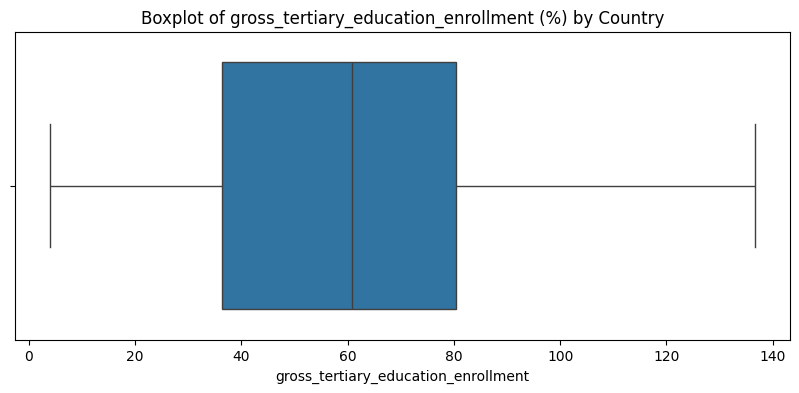

In [ ]:
column = numeric_cols[6]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "%" )


1. The dataset contains **2,458 country entries** with recorded gross tertiary education enrollment rates, providing a solid basis for analysis.

2. The mean enrollment rate is approximately **67.23%**, indicating that on average, around two-thirds of the population at tertiary education age (or outside it) are enrolled in higher education.

3. The standard deviation is **21.34**, showing moderate variability between countries. Some countries have very low enrollment, while others have extremely high rates.

4. **Minimum enrollment:** 4.0% — representing countries with very limited access to tertiary education.  
   **Maximum enrollment:** 136.6% — an outlier due to the "gross" nature of the indicator, which can exceed 100% if adults outside the official age group are enrolled.

5. **Quartiles:**  
   - 25th percentile: 50.6%  
   - Median (50th percentile): 65.6%  
   - 75th percentile: 88.2%  
   This shows that **50% of countries have enrollment rates between 50.6% and 88.2%**, meaning most countries provide moderate to high access to tertiary education.

6. The most common enrollment rate (mode) is **88.2%**, which aligns with the upper quartile, suggesting that relatively high enrollment is frequent among countries.

7. The **robust mean (trimmed 10%)** is approximately **68.75%**, slightly higher than the simple mean, indicating that the extreme low enrollments pull the average down a bit, but not dramatically.

8. **Outliers:**  
   There are **no outliers detected** for this variable according to the IQR method. This indicates that while some countries have very low or very high enrollment, they are not extreme enough compared to the distribution to be considered outliers.

**Conclusion:**  
Most countries have **moderate to high tertiary education enrollment rates**, typically between 50% and 88%. This reflects generally good access to higher education. Unlike other variables like GDP or CPI, **there are no extreme outliers**, so the distribution is relatively stable. High enrollment rates are relevant for understanding **human capital development** and potential for innovation and wealth creation in a country.

=== Descriptive statistics for gross_primary_education_enrollment_country ===
count    2459.000000
mean      102.858520
std         4.710977
min        84.700000
25%       100.200000
50%       101.800000
75%       102.600000
max       142.100000
Name: gross_primary_education_enrollment_country, dtype: float64
Mean Absolute Deviation of gross_primary_education_enrollment_country: 2.9724356882726175
Median of gross_primary_education_enrollment_country: 101.8
Mode of gross_primary_education_enrollment_country: [101.8]
Robust mean of gross_primary_education_enrollment_country (trimmed 10%): 101.92204164550533
-- Outliers --
      country  gross_primary_education_enrollment_country
103    Sweden                                       126.6
124   Nigeria                                        84.7
1564  Romania                                        85.2
1656    Nepal                                       142.1


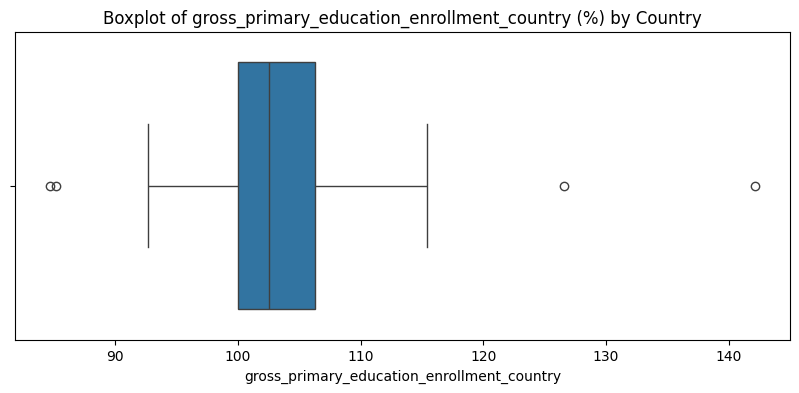

In [ ]:
column = numeric_cols[7]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "%" )


1. The dataset contains **2,459 country entries** with recorded gross primary education enrollment rates, giving a robust basis for analysis.

2. The mean enrollment rate is approximately **102.86%**, which is slightly above 100% due to the "gross" nature of the indicator (students outside the official primary school age are included).

3. The standard deviation is **4.71**, showing low variability between countries; most countries have very similar primary enrollment rates.

4. **Minimum enrollment:** 84.7% — a few countries have lower coverage.  
   **Maximum enrollment:** 142.1% — an extreme case, likely due to over-aged or under-aged students being enrolled in primary education.

5. **Quartiles:**  
   - 25th percentile: 100.2%  
   - Median (50th percentile): 101.8%  
   - 75th percentile: 102.6%  
   This shows that **50% of countries have enrollment rates between 100.2% and 102.6%**, indicating that **most countries achieve near-universal primary education**.

6. The most common enrollment rate (mode) is **101.8%**, which aligns closely with the median and the upper quartile, confirming the overall stability of primary education enrollment.

7. The **robust mean (trimmed 10%)** is approximately **101.92%**, slightly higher than the mean, indicating that outliers with very low or very high enrollment have minimal effect on the overall average.

8. **Outliers:**  
   A few countries deviate from the general trend:  
   - Sweden: 126.6%  
   - Nigeria: 84.7%  
   - Romania: 85.2%  
   - Nepal: 142.1%  

   These outliers represent countries with **unusually high or low primary enrollment rates**, likely due to enrollment of students outside the official age range (high values) or incomplete coverage (low values).

**Conclusion:**  
Most countries have **very high primary education enrollment**, typically around 100–102%. This reflects **near-universal access to primary schooling globally**. The few outliers highlight special cases, but overall the distribution is very tight, unlike other indicators such as GDP or CPI, showing that **primary education is widely achieved in almost all countries**.

=== Descriptive statistics for life_expectancy_country ===
count    2458.000000
mean       78.122823
std         3.730099
min        54.300000
25%        77.000000
50%        78.500000
75%        80.900000
max        84.200000
Name: life_expectancy_country, dtype: float64
Mean Absolute Deviation of life_expectancy_country: 2.6196285058469675
Median of life_expectancy_country: 78.5
Mode of life_expectancy_country: [78.5]
Robust mean of life_expectancy_country (trimmed 10%): 78.49329268292682
-- Outliers --
           country  life_expectancy_country
124        Nigeria                     54.3
157   South Africa                     63.9
1925      Tanzania                     65.0


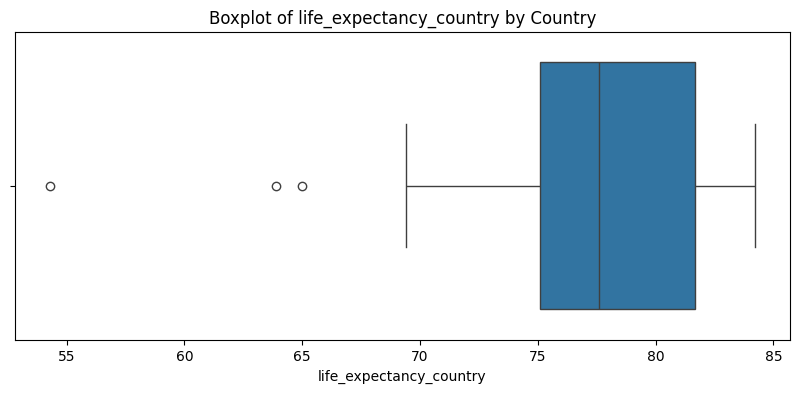

In [ ]:
column = numeric_cols[8]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column )


1. The dataset contains **2,458 country entries** with recorded life expectancy values, providing a solid basis for global comparison.

2. The mean life expectancy is approximately **78.12 years**, indicating that on average, people live almost 78 years across the countries in this dataset.

3. The standard deviation is **3.73**, showing moderate variability; most countries cluster around the mid to high 70s in life expectancy.

4. **Minimum life expectancy:** 54.3 years — indicating countries with significantly lower health outcomes.  
   **Maximum life expectancy:** 84.2 years — indicating countries with very high longevity.

5. **Quartiles:**  
   - 25th percentile: 77.0 years  
   - Median (50th percentile): 78.5 years  
   - 75th percentile: 80.9 years  
   This shows that **half of the countries have life expectancy between 77 and 80.9 years**, demonstrating a relatively tight distribution for most of the world.

6. The most common life expectancy (mode) is **78.5 years**, aligning with the median, showing that many countries fall close to the middle of the distribution.

7. The **robust mean (trimmed 10%)** is approximately **78.49 years**, very close to the simple mean, indicating that extreme low or high values have minimal impact on the average.

8. **Outliers:**  
   A few countries have unusually low life expectancy compared to the rest:  
   - Nigeria: 54.3 years  
   - South Africa: 63.9 years  
   - Tanzania: 65.0 years  

   These outliers likely reflect **lower healthcare access, higher disease burden, or socio-economic challenges** in these countries.

**Conclusion:**  
Most countries have **life expectancy between 77 and 81 years**, showing that globally, longevity is relatively high. The few outliers with lower life expectancy highlight regions facing significant **public health challenges**, which may also correlate with economic development and other socio-economic indicators such as education and GDP.

#### Tax revenue by country

=== Descriptive statistics for tax_revenue_country_country ===
count    2457.000000
mean       12.546235
std         5.368625
min         0.100000
25%         9.600000
50%         9.600000
75%        12.800000
max        37.200000
Name: tax_revenue_country_country, dtype: float64
Mean Absolute Deviation of tax_revenue_country_country: 3.9362267964628566
Median of tax_revenue_country_country: 9.6
Mode of tax_revenue_country_country: [9.6]
Robust mean of tax_revenue_country_country (trimmed 10%): 11.420183019827146
-- Outliers --
Empty DataFrame
Columns: [country, tax_revenue_country_country]
Index: []


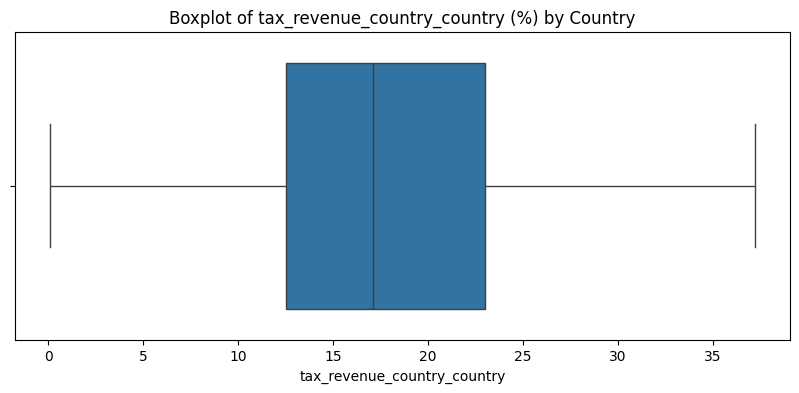

In [ ]:
column = numeric_cols[9]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "%" )


In [ ]:
# Ver cuál país tiene tax_revenue_country_country igual a 0.1
data_per_country[data_per_country['tax_revenue_country_country'] == 0.1][['country', 'tax_revenue_country_country']]

,country,tax_revenue_country_country
62,United Arab Emirates,0.1


In [ ]:
# Ver cuál país tiene tax_revenue_country_country igual a 37.2
data_per_country[data_per_country['tax_revenue_country_country'] == 37.2][['country', 'tax_revenue_country_country']]

,country,tax_revenue_country_country
0,Algeria,37.2


1. The dataset contains **2,457 country entries** with recorded tax revenue as a percentage of GDP, giving a solid basis for comparison.

2. The mean tax revenue is approximately **12.55%**, indicating that, on average, countries collect about 12–13% of their GDP in taxes.

3. The standard deviation is **5.37**, showing moderate variability between countries; some collect significantly more or less depending on their economic structure and fiscal policies.

4. **Minimum tax revenue:** 0.1% — United Arab Emirates, reflecting extremely low taxation due to reliance on oil revenues and minimal income or corporate taxes.  
   **Maximum tax revenue:** 37.2% — Algerie has high fiscal pressure relative to GDP.

5. **Quartiles:**  
   - 25th percentile: 9.6%  
   - Median (50th percentile): 9.6%  
   - 75th percentile: 12.8%  
   This indicates that **50% of countries collect between 9.6% and 12.8% of GDP in taxes**, showing that most countries have a relatively moderate tax-to-GDP ratio.

6. The most common value (mode) is **9.6%**, which aligns with the 25th percentile and median, indicating that **many countries cluster around this level** of taxation.

7. The **robust mean (trimmed 10%)** is **11.42%**, slightly lower than the raw mean, suggesting that some countries with very high tax revenue (like 37.2%) elevate the mean, but trimming reduces their influence.

8. **Outliers:**  
   No outliers were detected using the IQR method, meaning there are **no extreme deviations** that stand apart from the general distribution, though United Arab Emirates is an exceptionally low value in reality.

**Conclusion:**  
Most countries have **moderate tax revenue relative to their GDP**, typically between 9.6% and 12.8%.  
- **High values** reflect countries with strong fiscal systems and higher taxation rates.  
- **Low values** (like UAE’s 0.1%) reflect unique economic models with alternative income sources (oil, state-owned enterprises).  
This distribution highlights the diversity in **fiscal policies globally**, while showing that extreme values are rare.

#### Total tax rate country

=== Descriptive statistics for total_tax_rate_country ===
count    2458.000000
mean       43.963344
std        12.145296
min         9.900000
25%        36.600000
50%        41.200000
75%        59.100000
max       106.300000
Name: total_tax_rate_country, dtype: float64
Mean Absolute Deviation of total_tax_rate_country: 10.554678997723183
Median of total_tax_rate_country: 41.2
Mode of total_tax_rate_country: [36.6]
Robust mean of total_tax_rate_country (trimmed 10%): 44.21961382113822
-- Outliers --
       country  total_tax_rate_country
554  Argentina                   106.3


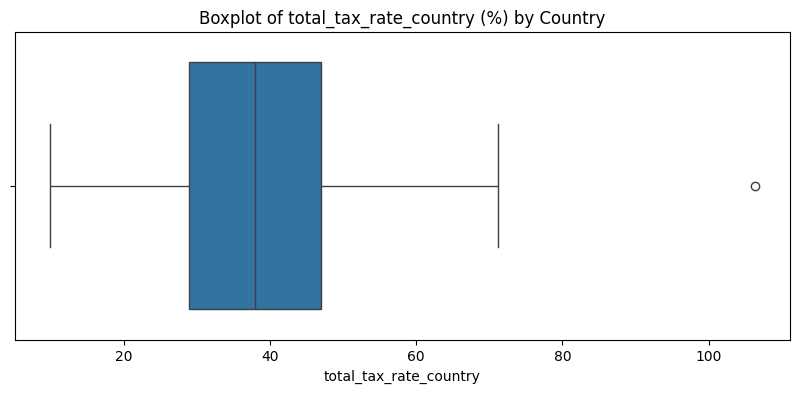

In [ ]:
column = numeric_cols[10]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "%" )


In [ ]:
# Filtrar solo la fila de Argentina
df[df["country"] == "Argentina"][["country", "total_tax_rate_country"]]

,country,total_tax_rate_country
554,Argentina,106.3
1054,Argentina,106.3
1596,Argentina,106.3
2156,Argentina,106.3


1. The dataset contains **2,458 country entries** with recorded total tax rates, providing a comprehensive overview of global fiscal pressure.

2. The mean total tax rate is approximately **43.96%**, indicating that, on average, countries impose a **moderate to high tax burden** on businesses and individuals.

3. The standard deviation is **12.15%**, showing considerable variability between countries; some countries have much lower or higher rates depending on their fiscal system.

4. **Minimum total tax rate:** 9.9% — countries with very low tax burdens, such as tax havens or nations with low taxation policies.  
   **Maximum total tax rate:** 106.3% — Argentina, an extreme case where effective combined taxes exceed 100%, reflecting very high income, corporate, and social contributions.

5. **Quartiles:**  
   - 25th percentile: 36.6%  
   - Median (50th percentile): 41.2%  
   - 75th percentile: 59.1%  
   This indicates that **50% of countries have total tax rates between 36.6% and 59.1%**, showing that most countries apply moderate to high fiscal pressure.

6. The most common value (mode) is **36.6%**, coinciding with the first quartile, indicating that many countries have relatively lower rates within the typical range.

7. The **robust mean (trimmed 10%)** is **44.22%**, slightly higher than the simple mean, suggesting that extreme values do not overly skew the average.

8. **Outliers:**  
   Only one outlier was detected:  
   - Argentina: 106.3% — an extremely high value indicating an exceptionally heavy combined tax burden on income, businesses, and social contributions.

**Conclusion:**  
Most countries have **total tax rates between 36% and 59%**, showing a generally high level of fiscal pressure worldwide.  
- **High extreme values**, like Argentina, reflect situations where combined taxes are extraordinarily high.  
- **Low extreme values**, like 9.9%, represent countries with very light taxation policies or special economic systems.  

Compared to `tax_revenue_country_country`, here we are looking at **the effective tax burden**, not the total revenue collected. A small country with a high total tax rate may collect little, whereas a large country with a low rate may still collect a lot of revenue.

#### Population country

=== Descriptive statistics for population_country ===
count    2.476000e+03
mean     5.102053e+08
std      5.542447e+08
min      3.801900e+04
25%      6.683440e+07
50%      3.282395e+08
75%      1.366418e+09
max      1.397715e+09
Name: population_country, dtype: float64
Mean Absolute Deviation of population_country: 483516087.43724173
Median of population_country: 328239523.0
Mode of population_country: [328239523.0]
Robust mean of population_country (trimmed 10%): 462330114.672553
-- Outliers --
           country  population_country
1    United States        3.282395e+08
8            India        1.366418e+09
14           China        1.397715e+09
55       Indonesia        2.702039e+08
124        Nigeria        2.009636e+08
165         Brazil        2.125594e+08


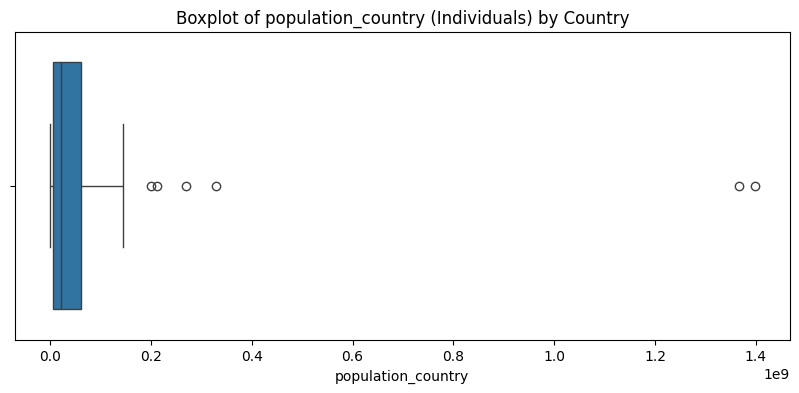

In [ ]:
column = numeric_cols[11]
describe_column(df, column)
outliers_cpi = get_outliers(df, column )
print("-- Outliers --")
print(outliers_cpi)
plot_boxplot(df, column, "Individuals" )


1. The dataset contains **2,476 country entries** with population data, providing a broad view of country sizes worldwide.

2. The mean population is approximately **510 million**, but this is **heavily influenced by very populous countries** like China, India, and the United States.

3. The standard deviation is **554 million**, indicating **extremely high variability** in country populations—from very small countries to gigantes like China and India.

4. **Minimum population:** 38,019 — very small states or territories.  
   **Maximum population:** 1,397,715,000 — China, the most populous country.  

5. **Quartiles:**  
   - 25th percentile: 66.8 million  
   - Median (50th percentile): 328.2 million  
   - 75th percentile: 1,366 million  
   This shows that **half of countries have populations between 328 million and 1.36 billion**, but the distribution is **strongly skewed** due to a few extremely large countries.

6. The most common value (mode) is **328,239,523**, which coincides with the population of the United States, reflecting a clustering around large but not extreme countries.

7. The **robust mean (trimmed 10%)** is **462 million**, slightly lower than the raw mean, showing that trimming extreme values reduces the influence of the largest countries like China and India.

8. **Outliers:**  
   Countries with exceptionally large populations include:  
   - China: 1.397 billion  
   - India: 1.366 billion  
   - United States: 328 million  
   - Indonesia: 270 million  
   - Brazil: 212 million  
   - Nigeria: 201 million  
   These outliers reflect **the fact that a few very large countries dominate global population statistics**, while most countries are much smaller.

**Conclusion:**  
Population distribution among countries is **highly skewed**, with a small number of very populous countries driving up the mean.  
- The median and robust mean provide better measures of a “typical” country population.  
- This is important when analyzing other metrics like GDP, tax revenue, or total tax rate, because **large countries can dominate totals and averages**, potentially masking trends in smaller countries.

### Linear relationships

<Axes: xlabel='cpi_country', ylabel='gross_tertiary_education_enrollment'>

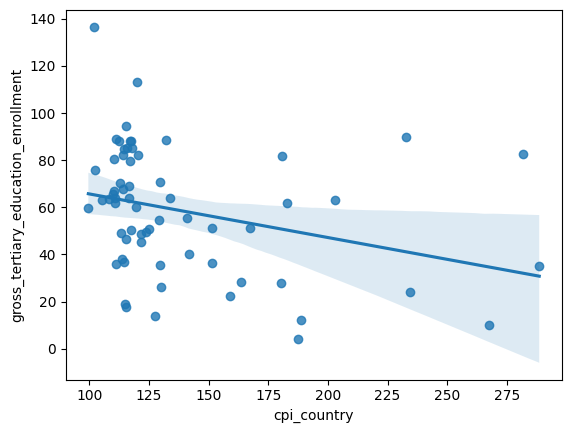

In [ ]:
sns.regplot(data=data_per_country, x='cpi_country', y='gross_tertiary_education_enrollment')


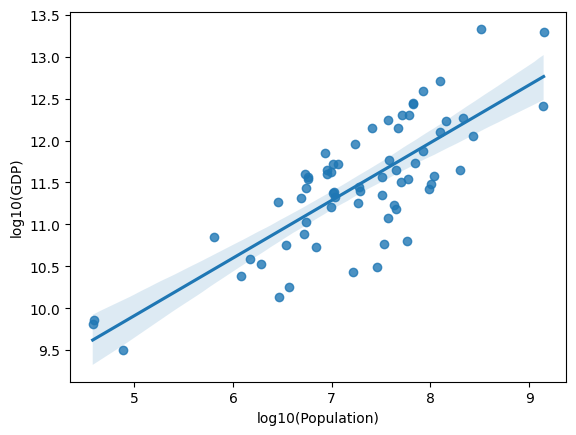

In [ ]:
sns.regplot(
    data=data_per_country,
    x=np.log10(data_per_country['population_country']),
    y=np.log10(data_per_country['gdp_country'])
)

plt.xlabel("log10(Population)")
plt.ylabel("log10(GDP)")
plt.show()

Text(0, 0.5, 'log10(GDP)')

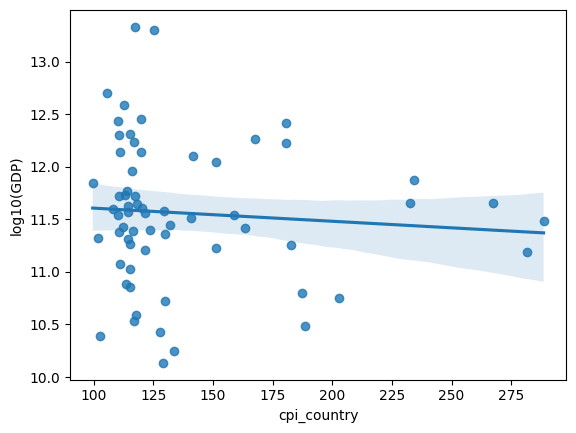

In [ ]:
import numpy as np

sns.regplot(
    data=data_per_country,
    x='cpi_country',
    y=np.log10(data_per_country['gdp_country'])
)

plt.ylabel("log10(GDP)")

<Axes: xlabel='total_tax_rate_country', ylabel='gdp_country'>

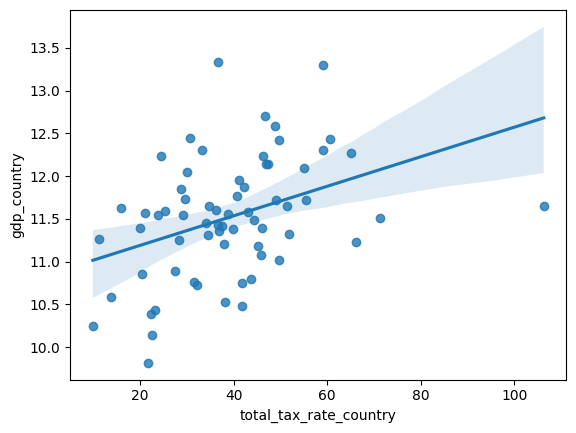

In [ ]:
sns.regplot(
    data=data_per_country,
    x='total_tax_rate_country',
    y=np.log10(data_per_country['gdp_country'])
)

<Axes: xlabel='gross_tertiary_education_enrollment', ylabel='life_expectancy_country'>

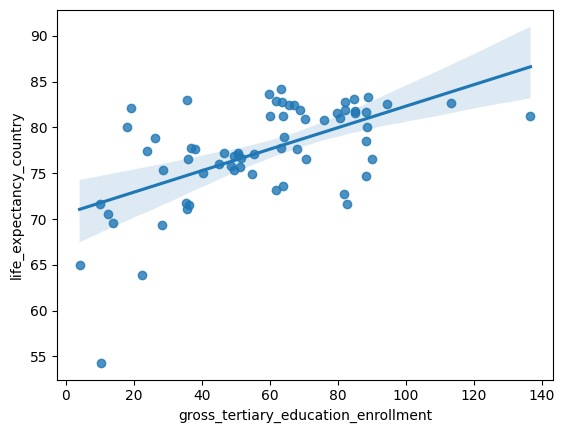

In [ ]:
sns.regplot(data=data_per_country, x='gross_tertiary_education_enrollment', y='life_expectancy_country')

## Correlation matrix

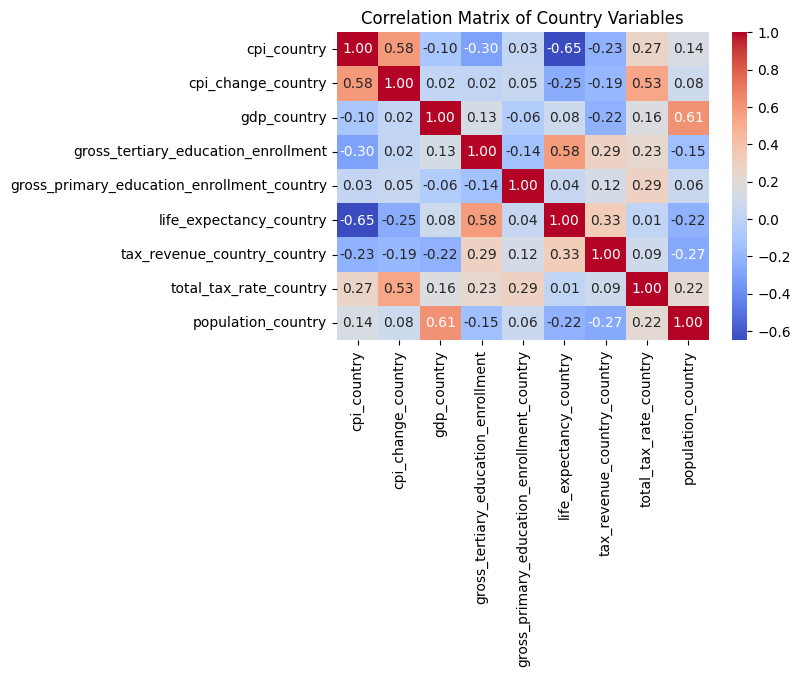

In [ ]:
from IPython.display import display

corr_matrix = data_per_country[numeric_cols[3:12]].corr()
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix of Country Variables")
plt.show()

The correlation matrix of country-level variables reveals several noteworthy relationships. First, GDP shows a strong positive correlation with population, indicating that countries with larger populations tend to have higher total economic output, which aligns with expectations. Additionally, GDP is moderately positively correlated with tertiary education enrollment and life expectancy, suggesting that wealthier countries tend to invest more in higher education and achieve better health outcomes. Interestingly, CPI and CPI change show weak correlations with most economic variables, indicating that inflation levels are largely independent of country size, GDP, or education indicators. Tax-related variables present some expected patterns: total tax rate is moderately positively correlated with tax revenue, reflecting that higher effective taxation generally results in higher government revenue relative to GDP. Overall, the matrix highlights the expected socio-economic links—population and GDP, GDP with human capital and health—while variables like CPI remain mostly uncorrelated with these measures, emphasizing their independent dynamics in the dataset.

## Pairplot

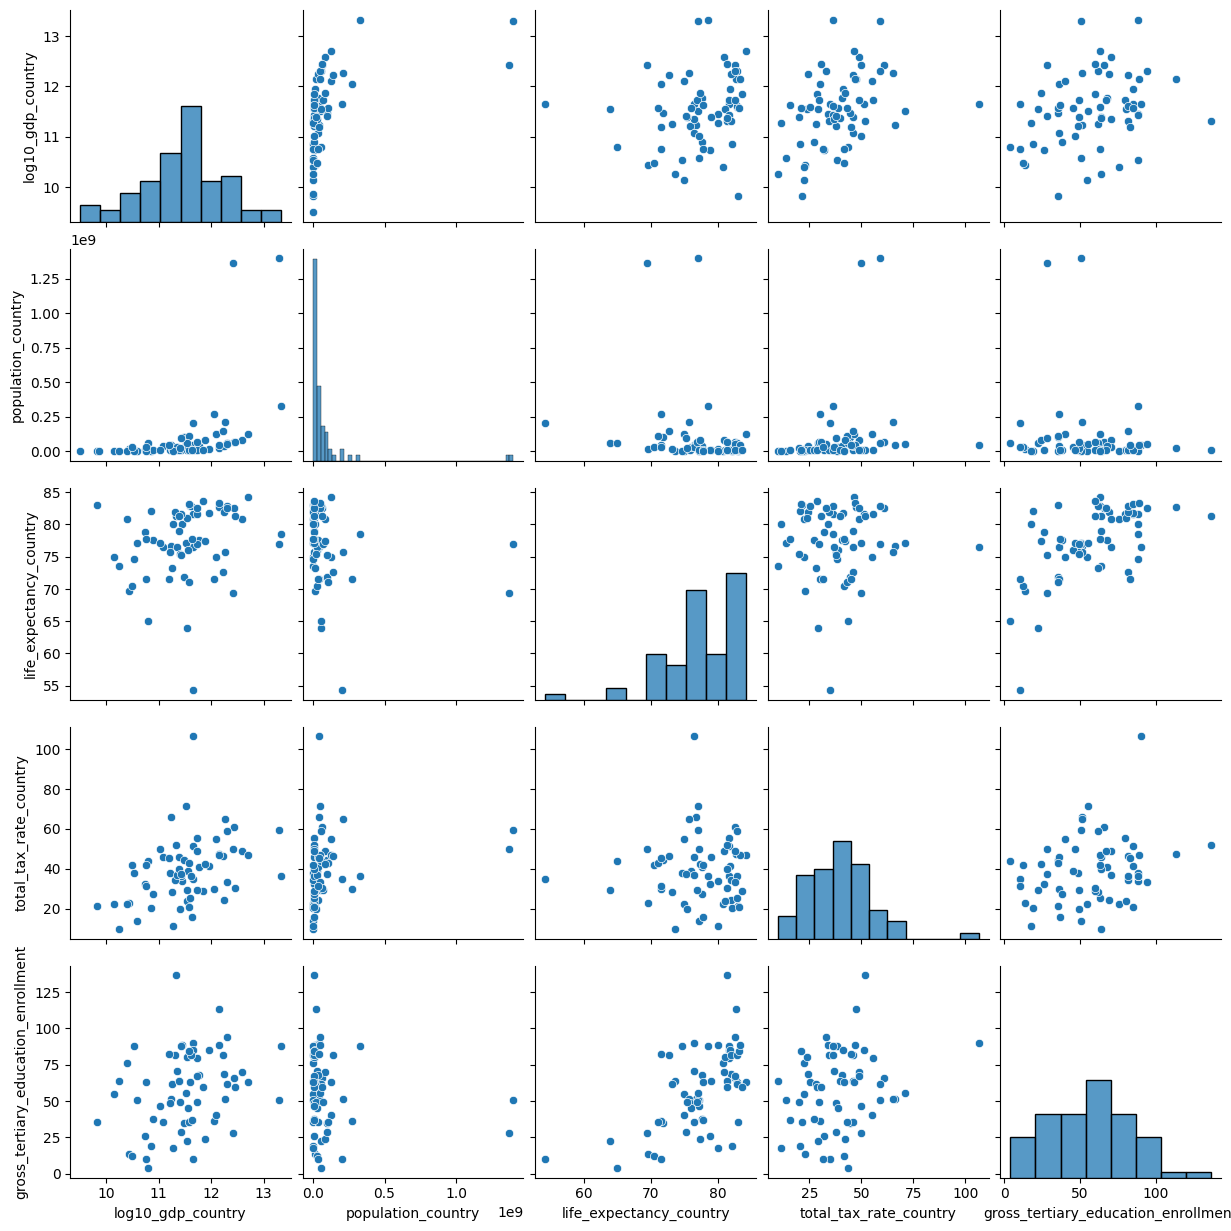

In [ ]:
data_per_country_log = data_per_country.copy()

# Agregar columna con log10 de GDP
data_per_country_log['log10_gdp_country'] = np.log10(data_per_country_log['gdp_country'])

# Lista de variables para graficar, usando log10_gdp_country
vars_to_plot_log = [
    'log10_gdp_country',
    'population_country',
    'life_expectancy_country',
    'total_tax_rate_country',
    'gross_tertiary_education_enrollment'
]

# Crear pairplot
sns.pairplot(data_per_country_log[vars_to_plot_log])

## Billionaries analysis

Now, we will perform an analysis of billionaires by country. We will focus on the **top 10 countries with the highest number of billionaires** and compute several **derived attributes for each country**.

These derived metrics will help us better understand the **structure and composition of wealth** within each national ecosystem.




### Industry Structure

We will analyze the distribution of billionaire wealth across industries by computing the following variables:

- **share_industry_x**:  
  Proportion of billionaires in a given industry relative to the total number of billionaires in that country.  
  \[
  share\_industry_x = \frac{count\_industry_x}{total\_billionaires\_country}
  \]

- **dominant_industry**:  
  The industry with the highest share of billionaires within the country.

- **industry_concentration**:  
  A measure of how concentrated billionaire wealth is across industries.  
  This will be computed using indicators such as the **Herfindahl–Hirschman Index (HHI)** or **entropy**, which help identify whether wealth is diversified across sectors or dominated by a few industries.

In [ ]:
industry_counts = (
    df
    .groupby(['country', 'industries'])
    .size()
    .unstack(fill_value=0)
)


total_billionaires_country = industry_counts.sum(axis=1)

industry_share = industry_counts.div(total_billionaires_country, axis=0)
industry_share.columns = [f"share_{col}" for col in industry_share.columns]

dominant_industry = industry_counts.idxmax(axis=1)
dominant_industry = dominant_industry.rename("dominant_industry")

industry_concentration = (industry_share ** 2).sum(axis=1)
industry_concentration = industry_concentration.rename("industry_concentration")



industry_country_dataset = pd.concat(
    [industry_share, dominant_industry, industry_concentration],
    axis=1
).reset_index()


data_per_country = data_per_country.merge(
    industry_country_dataset,
    on="country",
    how="left"
)


data_per_country.head()

,country,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,...,share_Manufacturing,share_Media & Entertainment,share_Metals & Mining,share_Real Estate,share_Service,share_Sports,share_Technology,share_Telecom,dominant_industry,industry_concentration
0,Algeria,151.36,2.0,1.699882e+11,51.4,109.9,76.7,37.2,66.1,43053054.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,Food & Beverage,1.000000
1,Andorra,NaN,NaN,3.154058e+09,NaN,106.4,NaN,NaN,NaN,77142.0,...,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,Manufacturing,1.000000
2,Argentina,232.75,53.5,4.496634e+11,90.0,109.7,76.5,10.1,106.3,44938712.0,...,0.000000,0.000000,0.000000,0.250000,0.0,0.0,0.250000,0.000000,Diversified,0.250000
3,Armenia,129.18,1.4,1.367280e+10,54.6,92.7,74.9,20.9,22.6,2957731.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,Finance & Investments,1.000000
4,Australia,119.80,1.6,1.392681e+12,113.1,100.3,82.7,23.0,47.4,25766605.0,...,0.093023,0.023256,0.186047,0.186047,0.0,0.0,0.186047,0.023256,Metals & Mining,0.138994


country name Hong Kong


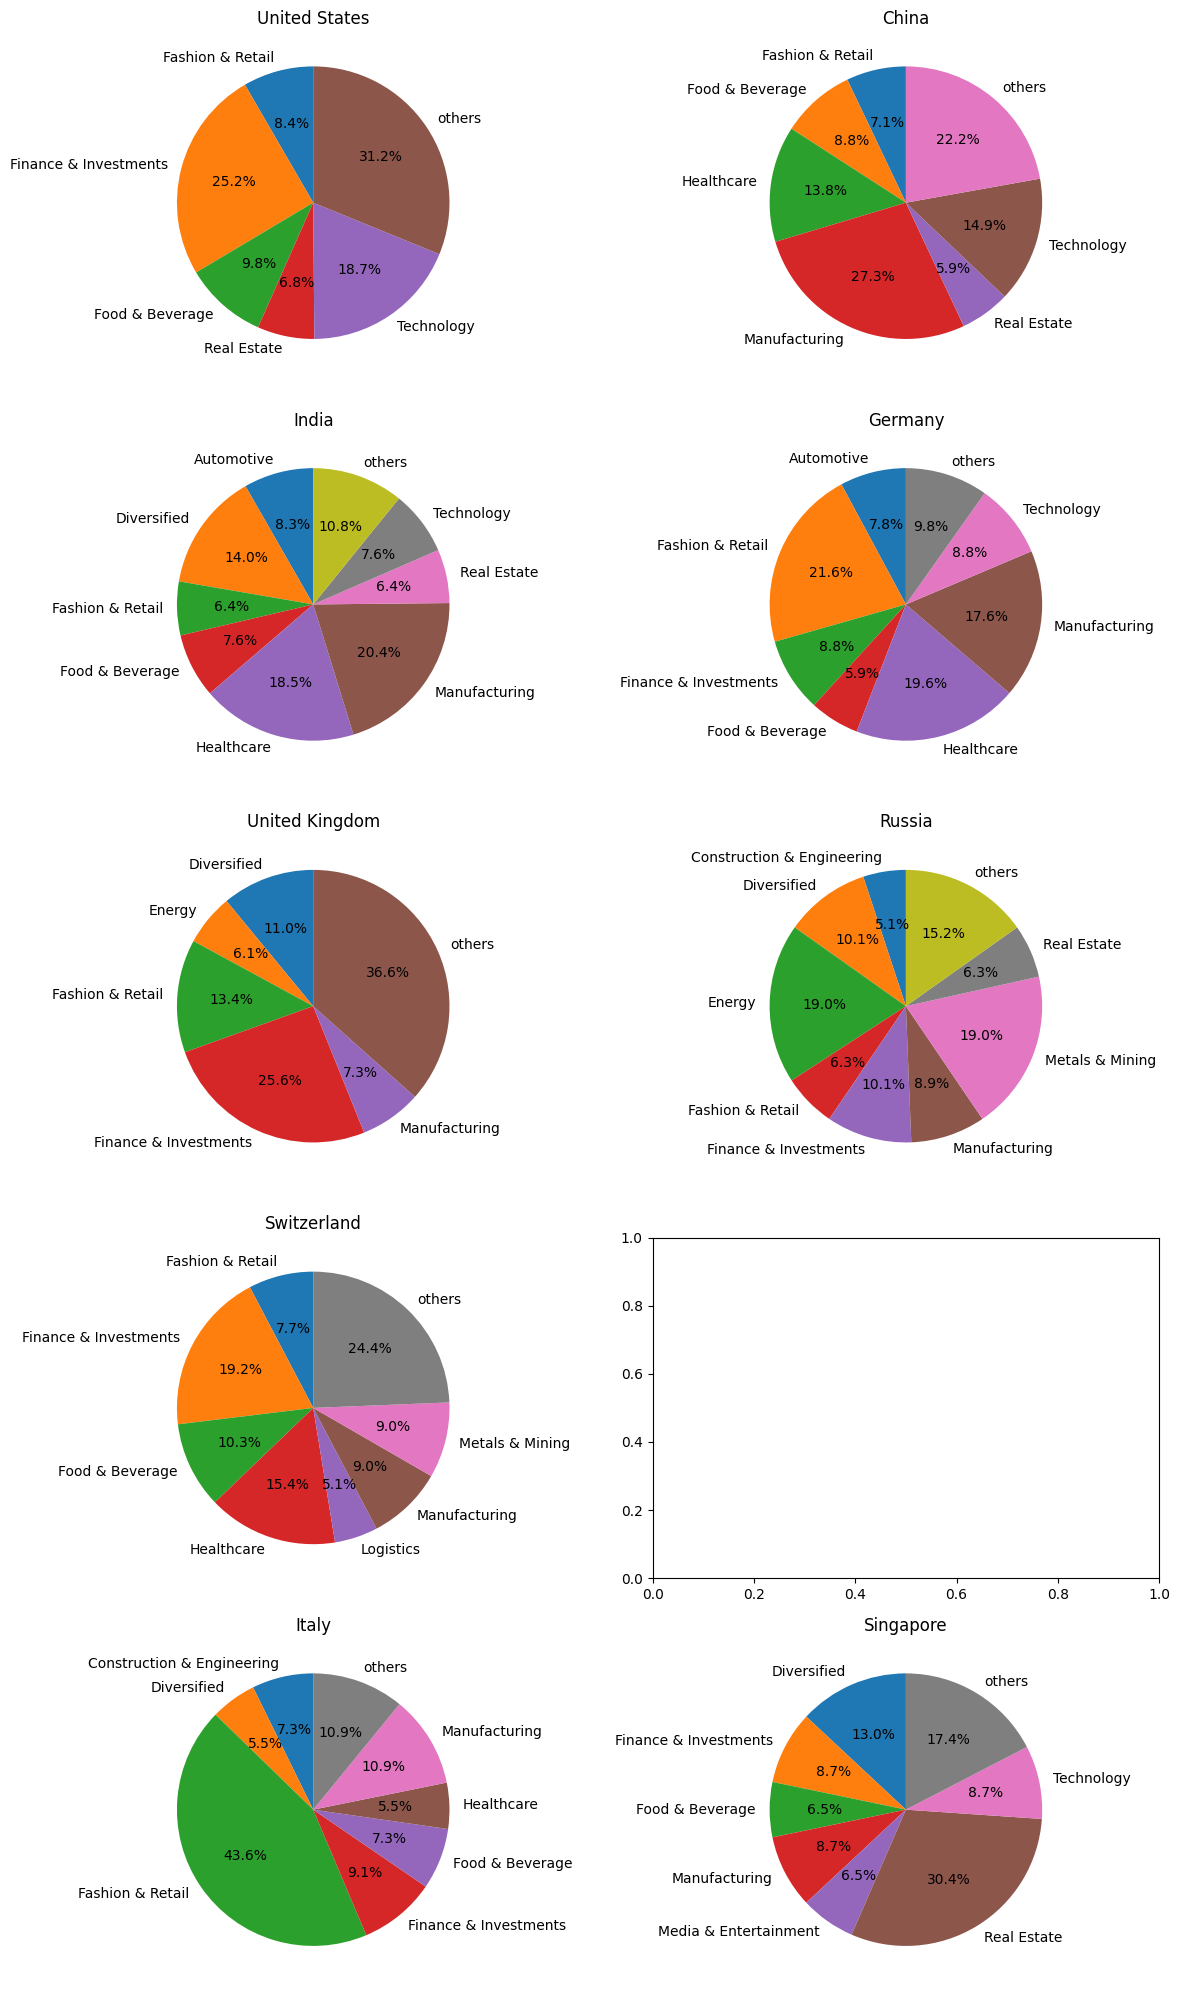

In [ ]:
# top 10 países con más billonarios
top10 = df['country'].value_counts().head(10).index

share_cols = [col for col in data_per_country.columns if col.startswith("share_")]

# crear figura con 2 columnas
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

for i, country_name in enumerate(top10):

    row = data_per_country[data_per_country["country"] == country_name]

    if row.empty:
        print("country name", country_name)
        continue

    shares = row[share_cols].iloc[0]

    # eliminar shares = 0
    shares = shares[shares > 0]

    # separar industrias <5%
    small = shares[shares < 0.05]
    large = shares[shares >= 0.05].copy()

    # agregar Others
    if len(small) > 0:
        large["others"] = small.sum()

    labels = [col.replace("share_", "") for col in large.index]

    axes[i].pie(large, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(country_name)

plt.tight_layout()
plt.show()

### Distribution of Billionaires by Country

This chart shows which countries have the highest concentration of billionaires.

The concentration of billionaires may reflect the size of the economy,
but it can also indicate different wealth accumulation structures.

This information is important for understanding which countries will have sufficient
representation in the ranking analysis.

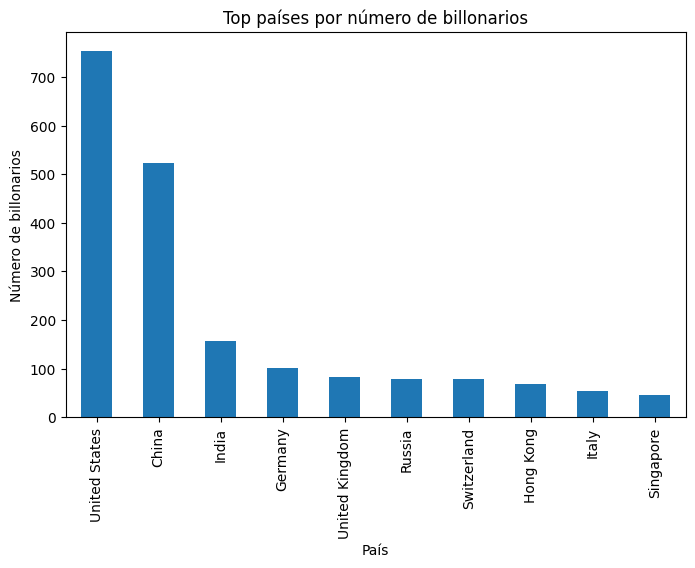

In [ ]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind="bar")

plt.title("Top países por número de billonarios")
plt.xlabel("País")
plt.ylabel("Número de billonarios")

plt.show()

### Proportion of Self-Made Wealth

This chart shows the proportion of self-made billionaires in each country.

A high value suggests an ecosystem based on entrepreneurship and innovation,
while a low value may indicate economies more dependent on inherited wealth.

This variable is key to distinguishing between:
- Innovation Ecosystem
- Rentier Paradise

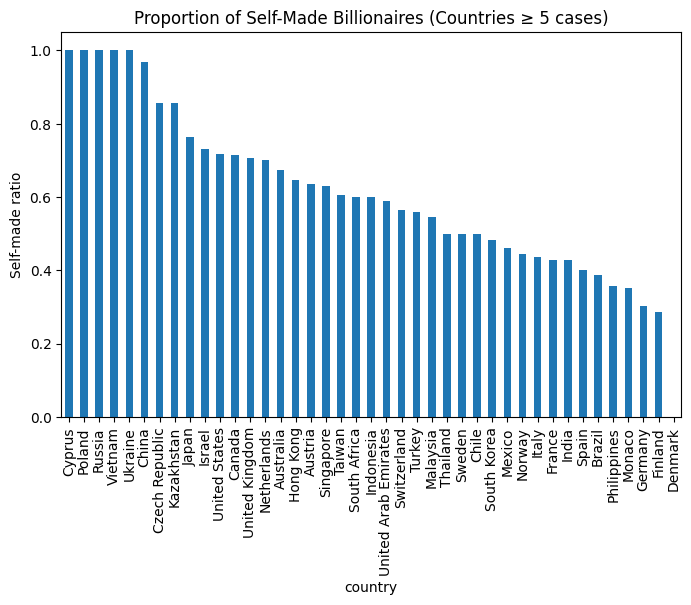

In [ ]:
# Count billionaires per country
country_counts = df["country"].value_counts()

# Keep only countries with >= 5 billionaires
valid_countries = country_counts[country_counts >= 5].index

df_filtered = df[df["country"].isin(valid_countries)]

# Recalculate self-made ratio
selfmade_country = (
    df_filtered
    .groupby("country")["selfMade"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
selfmade_country.plot(kind="bar")

plt.title("Proportion of Self-Made Billionaires (Countries ≥ 5 cases)")
plt.ylabel("Self-made ratio")

plt.show()

### Sectoral Distribution of Wealth

This chart shows the industries with the greatest presence among billionaires.
Sectoral concentration can indicate different types of economies:

- Technology sectors → innovation-based economies
- Extractive sectors → natural resource-based economies
- Financial or real estate sectors → potential rentier structures

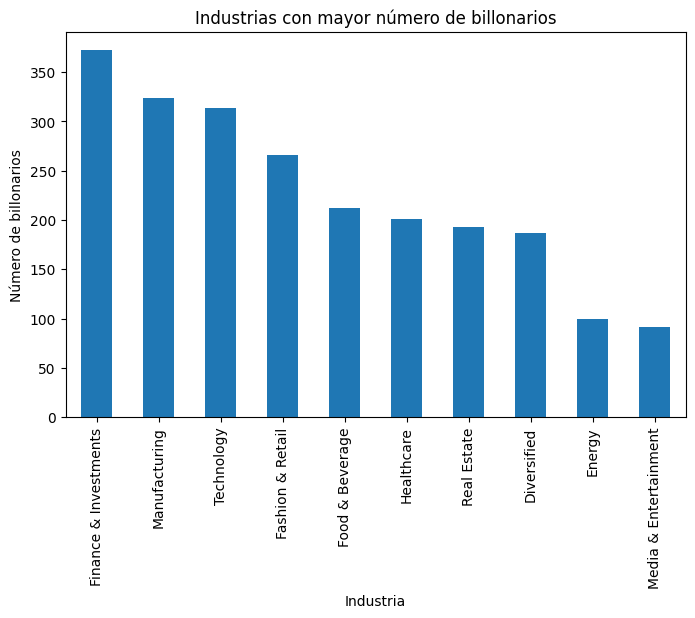

In [ ]:
top_industries = df["industries"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_industries.plot(kind="bar")

plt.title("Industrias con mayor número de billonarios")
plt.xlabel("Industria")
plt.ylabel("Número de billonarios")

plt.show()

### Average Age of Billionaires

The average age of billionaires can serve as a proxy
for the level of generational renewal within the wealth ecosystem.

A lower average age could indicate greater entrepreneurial dynamism,
while a higher average age may reflect more stable or inherited wealth structures.

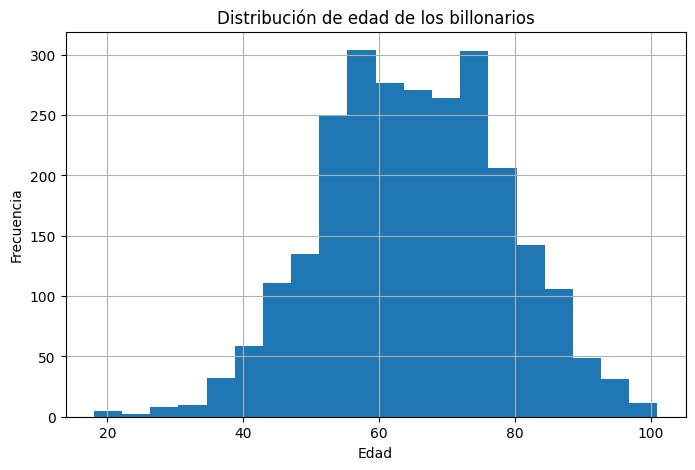

In [ ]:
plt.figure(figsize=(8,5))

df["age"].hist(bins=20)

plt.title("Distribución de edad de los billonarios")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Education and Innovation Ecosystems

The rate of tertiary education can reflect a country's capacity
to generate innovation ecosystems.

Comparing this variable with the proportion of self-made wealth
can help identify knowledge-based economies.

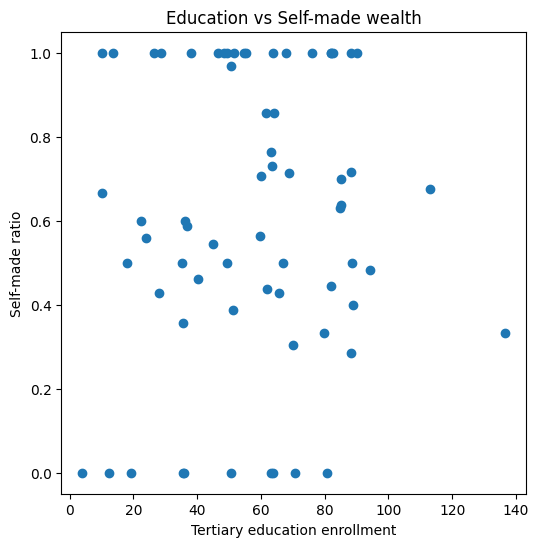

In [ ]:
education_selfmade = df.groupby("country").agg({
    "gross_tertiary_education_enrollment":"mean",
    "selfMade":"mean"
})

plt.figure(figsize=(6,6))

plt.scatter(
    education_selfmade["gross_tertiary_education_enrollment"],
    education_selfmade["selfMade"]
)

plt.xlabel("Tertiary education enrollment")
plt.ylabel("Self-made ratio")

plt.title("Education vs Self-made wealth")

plt.show()

## Conclusions of the Exploratory Analysis

The exploratory analysis reveals several patterns relevant to the classification task.

First, the distribution of billionaires shows a strong concentration in some countries,
suggesting structural differences between economies.

Second, the proportion of self-made wealth varies significantly between countries,
indicating different levels of entrepreneurial dynamism.

Third, the sectoral distribution shows that some countries concentrate their wealth
in technology sectors, while others depend on extractive industries
or financial sectors.

Finally, demographic variables such as average age and structural factors
such as tertiary education can offer additional clues about the type
of economic ecosystem present in each country.

These patterns justify the use of classification techniques to identify
different types of wealth ecosystems at the national level.

# Get dataset from github

In [ ]:
url = "https://raw.githubusercontent.com/mbarrerag/Billionard-dataset/refs/heads/main/Billionaires_dataset.csv"
df = pd.read_csv(url)
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country,associated_companies,number_of_companies
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749,"LVMH (Louis Vuitton, Dior, Givenchy, Tiffany &...",75
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891,"Tesla, SpaceX, X (Twitter), Starlink, The Bori...",7
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891,"Amazon, Blue Origin, The Washington Post, Bezo...",100
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891,"Oracle, Tesla (stake), NetSuite, Sensei Ag, Pa...",5
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891,"Berkshire Hathaway (GEICO, Duracell, Dairy Que...",60


In [ ]:
df.to_csv("dataset_original.csv", index=False)

# Level 1 - Base Data Cleaning

## Remove Irrelevant Columns

### Person Name, First Name and Last Name

As shown in the Analysis of Categorical Values section, the variables personName, firstName, and lastName contain a very high number of unique values, since most observations correspond to different individuals. However, the attribute personName is a composition of firstName and lastName, meaning that these two variables provide redundant information. Therefore, firstName and lastName will be removed from the dataset, keeping personName as the single attribute representing the individual's name.


In [ ]:
total_rows = df.shape[0]

for col in ['personName', 'lastName', 'firstName']:
    num_unique = df[col].nunique()
    percentage = (num_unique / total_rows) * 100
    print(f"Percentage of unique values for {col}: {percentage:.2f}%")

Percentage of unique values for personName: 99.92%
Percentage of unique values for lastName: 65.76%
Percentage of unique values for firstName: 67.05%


We proceed to remove these two columns

In [ ]:
df.drop(columns=['lastName', 'firstName'], inplace=True)

In [ ]:
df.shape

(2640, 35)

### BirthDate, BirthYear, BirthMonth, BirthDay

The variables birthDate, birthYear, birthMonth, and birthDay represent the same information at different levels of granularity. Specifically, birthYear, birthMonth, and birthDay can be directly derived from birthDate, making them redundant attributes. Including multiple representations of the same information does not provide additional knowledge for the data mining process and may introduce unnecessary complexity in the dataset. Therefore, it is preferable to keep a single attribute representing the birth information. In this case, either birthDate can be retained to preserve the complete date information, or birthYear can be kept if the analysis only requires age-related information. Consequently, birthMonth and birthDay will be removed since they do not add additional value beyond what can already be obtained from the other variables.

In [ ]:
df.head()[['birthDate', 'birthYear', 'birthMonth', 'birthDay']]

,birthDate,birthYear,birthMonth,birthDay
0,3/5/1949 0:00,1949.0,3.0,5.0
1,6/28/1971 0:00,1971.0,6.0,28.0
2,1/12/1964 0:00,1964.0,1.0,12.0
3,8/17/1944 0:00,1944.0,8.0,17.0
4,8/30/1930 0:00,1930.0,8.0,30.0


In [ ]:
df.drop(columns=['birthMonth', 'birthDay'], inplace=True)

In [ ]:
df.shape

(2640, 33)

### Ranking

The variable rank is directly determined by finalWorth, since billionaires are ranked according to their net worth. This means that rank does not represent an independent attribute but rather an ordered transformation of finalWorth. Including both variables would introduce redundant information without contributing additional insight to the data mining process. Therefore, finalWorth will be retained as it preserves the original quantitative information about wealth, while rank will be removed from the dataset.

In [ ]:
df.head()[['rank']]
df.sort_values(by='rank')[['rank', 'finalWorth']]

,rank,finalWorth
0,1,211000
1,2,180000
2,3,114000
3,4,107000
4,5,106000
...,...,...
2627,2540,1000
2626,2540,1000
2625,2540,1000
2624,2540,1000


In [ ]:
df.drop(columns=['rank'], inplace=True)

In [ ]:
df.shape

(2640, 32)

### Country and CountryOfCitizenship

The columns country and countryOfCitizenship will be compared to determine whether they represent the same attribute or different concepts. While country typically refers to the country of residence, countryOfCitizenship represents the nationality of the individual. By analyzing these variables, it is possible to identify whether they contain redundant information or if meaningful insights can be obtained from differences between residence and citizenship. This comparison will help decide whether both variables should be retained or if one of them can be removed from the dataset.

In [ ]:
df[['country', 'countryOfCitizenship']]

,country,countryOfCitizenship
0,France,France
1,United States,United States
2,United States,United States
3,United States,United States
4,United States,United States
...,...,...
2635,China,China
2636,United States,United States
2637,China,China
2638,China,China


In [ ]:
mismatched_countries = df[df['country'] != df['countryOfCitizenship']]
display(f"Number of rows where 'country' and 'countryOfCitizenship' differ: {len(mismatched_countries)}")
display(f"Percentage of rows where 'country' and 'countryOfCitizenship' differ: {(len(mismatched_countries) / len(df)) * 100:.2f}%")

# Display the mismatched rows to get a better understanding
display(mismatched_countries[['country', 'countryOfCitizenship']].head())

"Number of rows where 'country' and 'countryOfCitizenship' differ: 316"

"Percentage of rows where 'country' and 'countryOfCitizenship' differ: 11.97%"

,country,countryOfCitizenship
28,Switzerland,Germany
29,Belgium,Italy
37,China,Hong Kong
39,United Kingdom,United States
40,United States,France


We could realize that there are some rows with different values in these attributes, so, we will keep both of them, they might be useful for the Data Mining model.

### Latitude & Longitude Country (164 Nulls / ~6.21% - Column Elimination)

### Elimination of 'latitude_country' and 'longitude_country' Columns

- **Nature of the Columns**: `latitude_country` and `longitude_country` are numeric continuous columns representing the geographic coordinates of the billionaire's country of residence.
- **Null Values**: There were **164** missing values in each column (~6.21%).

### Proposed and Applied Strategy

Following Tan et al. (Section 2.2.1), these columns are eliminated entirely for two reasons:

1. **Redundancy with country**: Geographic coordinates at the country level add no analytical value beyond what `country` already provides. Every billionaire's country is now fully recovered — a country name is more interpretable and useful than a latitude/longitude pair for any downstream analysis.
2. **City is the preferred geographic granularity**: Since `city` has been fully recovered and retained, coordinates at the country level are both redundant and less precise than city-level geography.

### Outcome
Both columns permanently removed from the dataset. **Zero persons removed.**

In [ ]:
print("=== LATITUDE & LONGITUDE - BEFORE ===")
print(f"Null values - latitude_country: {df['latitude_country'].isnull().sum()}")
print(f"Null values - longitude_country: {df['longitude_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

df.drop(columns=['latitude_country', 'longitude_country'], inplace=True)

print("\n=== LATITUDE & LONGITUDE - AFTER ===")
print(f"'latitude_country' exists: {'latitude_country' in df.columns}")
print(f"'longitude_country' exists: {'longitude_country' in df.columns}")
print(f"Dataset shape: {df.shape}")

=== LATITUDE & LONGITUDE - BEFORE ===
Null values - latitude_country: 164
Null values - longitude_country: 164
Dataset shape: (2640, 32)

=== LATITUDE & LONGITUDE - AFTER ===
'latitude_country' exists: False
'longitude_country' exists: False
Dataset shape: (2640, 30)


## Check Duplicates

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   finalWorth                                  2640 non-null   int64  
 1   category                                    2640 non-null   object 
 2   personName                                  2640 non-null   object 
 3   age                                         2575 non-null   float64
 4   country                                     2602 non-null   object 
 5   city                                        2568 non-null   object 
 6   source                                      2640 non-null   object 
 7   industries                                  2640 non-null   object 
 8   countryOfCitizenship                        2640 non-null   object 
 9   organization                                325 non-null    object 
 10  selfMade    

Number of duplicate 'personName' entries: 4
These are the duplicated entries (showing first 5 if any):


,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,organization,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,associated_companies,number_of_companies
1045,2900,Healthcare,Li Li,57.0,China,Changsha,Healthcare,Healthcare,China,NaN,...,2.9,"$19,910,000,000,000",50.6,100.2,77.0,9.4,59.2,1.397715e+09,Healthcare,1
2317,1200,Healthcare,Li Li,59.0,China,Shenzhen,Pharmaceuticals,Healthcare,China,NaN,...,2.9,"$19,910,000,000,000",50.6,100.2,77.0,9.4,59.2,1.397715e+09,Pharmaceuticals,1
785,3700,Manufacturing,Wang Yanqing & family,56.0,China,Wuxi,Electrical equipment,Manufacturing,China,NaN,...,2.9,"$19,910,000,000,000",50.6,100.2,77.0,9.4,59.2,1.397715e+09,Electrical equipment,1
2112,1400,Manufacturing,Wang Yanqing & family,76.0,China,Weihai,Carbon fiber products,Manufacturing,China,NaN,...,2.9,"$19,910,000,000,000",50.6,100.2,77.0,9.4,59.2,1.397715e+09,Carbon fiber products,1


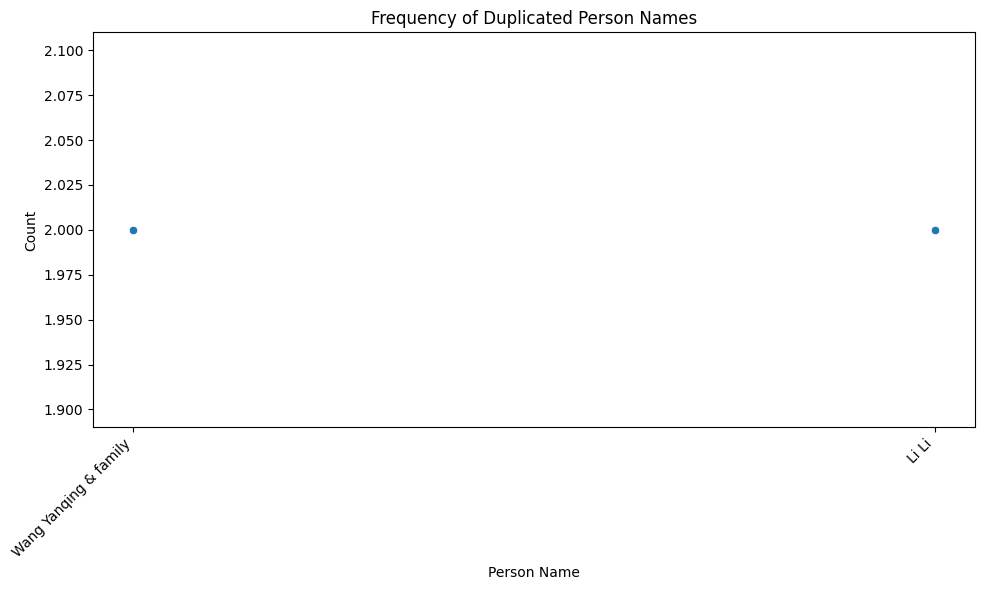

In [ ]:
# Identify duplicate personName entries
duplicates = df[df.duplicated(subset='personName', keep=False)]
print(f"Number of duplicate 'personName' entries: {len(duplicates)}")
print("These are the duplicated entries (showing first 5 if any):")
display(duplicates.sort_values(by='personName').head())

# Visualize the frequency of duplicated personNames
if not duplicates.empty:
    duplicate_counts = duplicates['personName'].value_counts()
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=duplicate_counts.index, y=duplicate_counts.values)
    plt.title('Frequency of Duplicated Person Names')
    plt.xlabel('Person Name')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No duplicated 'personName' entries found to visualize.")

In [ ]:
# Remove duplicate personName entries, keeping the first occurrence
df.drop_duplicates(subset='personName', keep='first', inplace=True)
print(f"DataFrame shape after removing duplicates: {df.shape}")

# Verify that duplicates have been removed
print(f"Number of 'personName' duplicates after removal: {df.duplicated(subset='personName').sum()}")

DataFrame shape after removing duplicates: (2638, 30)
Number of 'personName' duplicates after removal: 0


In [ ]:
df.isnull().sum()

,0
finalWorth,0
category,0
personName,0
age,65
country,38
city,72
source,0
industries,0
countryOfCitizenship,0
organization,2313


## Handling missing values

### Country (38 Nulls / ~1.44% - Hierarchical Recovery)

### Imputation of Missing Values in the 'country' Column

- **Nature of the Column**: `country` is a categorical column representing the country of residence of each billionaire.
- **Null Values**: There were **38** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~1.44%** of the total entries in the dataset.

### Proposed and Applied Strategy

Since our priority is to **preserve every person in the dataset**, row elimination was discarded in favor of a hierarchical estimation approach. Following Tan et al. (Section 2.2.1), missing values should be estimated using the most contextually relevant information already available in the same object.

A four-step hierarchical recovery was applied in order of reliability:

1. **Step 1 — countryOfCitizenship**: The most reliable substitute. If a billionaire has no country of residence recorded, their citizenship country is the strongest available signal — most people live in the country they hold citizenship in.
2. **Step 2 — Inferred from city**: If citizenship is also missing but a city is present, the country is inferred by matching the city against a known city-to-country mapping built from the existing dataset.
3. **Step 3 — Inferred from state/residenceStateRegion**: If a US state or region is present, the country is assigned as `"United States"` since state-level data in this dataset is predominantly American.
4. **Step 4 — Unknown as last resort**: If all three steps fail, the value is filled with `"Unknown"` to preserve the row while honestly flagging the gap.

### Outcome
All 38 missing country values recovered through hierarchical estimation. **Zero persons removed.**

In [ ]:
print("=== COUNTRY - BEFORE ===")
print(f"Null values in 'country': {df['country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

# Show who is missing country BEFORE
missing_country_mask = df['country'].isnull()
print("\n--- Billionaires with missing country (BEFORE) ---")
print(df[missing_country_mask][[
    'personName', 'countryOfCitizenship',
    'city', 'source', 'industries'
]].to_string())

# Step 1: Fill from countryOfCitizenship
df['country'] = df['country'].fillna(df['countryOfCitizenship'])

# Step 2: Build city -> country map from existing non-null data
city_country_map = (
    df[df['country'].notnull() & df['city'].notnull()]
    .groupby('city')['country']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

# Apply city -> country for still missing
def recover_country(row):
    if pd.notnull(row['country']):
        return row['country']

    # Step 2: infer from city
    if pd.notnull(row['city']) and row['city'] in city_country_map:
        return city_country_map[row['city']]

    # Step 3: infer from state or residenceStateRegion
    if pd.notnull(row.get('state')) or pd.notnull(row.get('residenceStateRegion')):
        return 'United States'

    # Step 4: last resort
    return 'Unknown'

df['country'] = df.apply(recover_country, axis=1)

print("\n=== COUNTRY - AFTER ===")
print(f"Null values in 'country': {df['country'].isnull().sum()}")
print(f"Unknown values in 'country': {(df['country'] == 'Unknown').sum()}")
print(f"Dataset shape: {df.shape}")

# Show recovered results
print("\n--- Same billionaires AFTER recovery ---")
print(df.loc[missing_country_mask, [
    'personName', 'country', 'city', 'source', 'industries'
]].to_string())

=== COUNTRY - BEFORE ===
Null values in 'country': 38
Dataset shape: (2638, 30)

--- Billionaires with missing country (BEFORE) ---
                             personName countryOfCitizenship city                    source                  industries
108                       Beate Heister              Germany  NaN              Supermarkets            Fashion & Retail
422                        Sunil Mittal                India  NaN                   Telecom                     Telecom
646                     Ian Livingstone       United Kingdom  NaN               Real estate                 Real Estate
647                 Richard Livingstone       United Kingdom  NaN               Real estate                 Real Estate
904   Karen Virginia Beckmann Legoretta               Mexico  NaN                   Tequila             Food & Beverage
994          Catheline Perier D'Ieteren              Belgium  NaN  Auto parts, distribution                  Automotive
1141                   Timm 

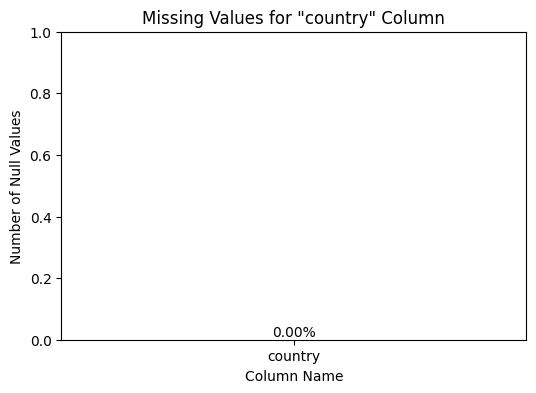

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get null count and percentage for 'country' column
null_count_country = df['country'].isnull().sum()
total_rows = len(df)
percentage_null_country = (null_count_country / total_rows) * 100

# Create a DataFrame for plotting
null_data_country = {
    'Column': ['country'],
    'Null_Count': [null_count_country],
    'Percentage': [percentage_null_country]
}
null_df_country = pd.DataFrame(null_data_country)

plt.figure(figsize=(6, 4))
sns.barplot(x='Column', y='Null_Count', data=null_df_country, hue='Column', legend=False, palette='viridis')

# Add percentage labels on top of the bars
for index, row in null_df_country.iterrows():
    plt.text(index, row['Null_Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.title('Missing Values for "country" Column')
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.ylim(0, max(1, null_df_country['Null_Count'].max() * 1.1)) # Adjust y-axis limit, ensure at least 1 for empty plot
plt.show()

### City (72 Nulls / ~2.73% - Hierarchical Recovery: Mode by Country → Known Billionaire Hub)

### Imputation of Missing Values in the 'city' Column

- **Nature of the Column**: `city` is a categorical column representing the city of residence of each billionaire.
- **Null Values**: There were **72** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~2.73%** of the total entries in the dataset.

### Proposed and Applied Strategy — Hierarchical Recovery

Following Tan et al. (Section 2.2.1), missing values should be estimated using the most contextually relevant information available. Two important considerations shaped this strategy:

- **Null values**: 72 rows had a genuinely missing city value (`NaN`).
- **"Unknown" strings**: Some rows had already been filled with the literal string `"Unknown"` from a previous pipeline step. These are treated identically to null values — they represent missing information and must be recovered the same way.

A three-step hierarchical approach was applied to both null and "Unknown" values:

1. **Step 1 — Mode by Country (Internal)**: For each billionaire with a missing or Unknown city, the most frequently occurring city among other billionaires from the same country is used. This is grounded in Tan et al.'s nearest neighbor estimation logic — billionaires from the same country are the most contextually similar objects available.
2. **Step 2 — Known Billionaire Hub by Country (External)**: If no mode exists for that country in the dataset, a manually researched dictionary of the primary billionaire city per country is used — built from Forbes 2023 data and publicly known wealth concentration data.



In [ ]:
print("=== CITY - BEFORE RECOVERY ===")
print(f"Null values in 'city': {df['city'].isnull().sum()}")
print(f"Unknown strings in 'city': {(df['city'] == 'Unknown').sum()}")

# Show billionaires with missing or Unknown city BEFORE
missing_city_mask = df['city'].isnull() | (df['city'] == 'Unknown')
print("\n--- Billionaires with missing or Unknown city (BEFORE) ---")
print(df[missing_city_mask][['personName', 'country', 'industries', 'finalWorth']].to_string())

# Step 1: Mode by country from existing non-null, non-Unknown data
country_city_mode = (
    df[df['city'].notnull() & (df['city'] != 'Unknown')]
    .groupby('country')['city']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

# Step 2: Manually curated dictionary for known billionaire hubs as a fallback
known_billionaire_city = {
    'United States': 'New York',
    'China': 'Beijing',
    'Germany': 'Munich',
    'India': 'Mumbai',
    'United Kingdom': 'London',
    'France': 'Paris',
    'Russia': 'Moscow',
    'Switzerland': 'Zurich',
    'Italy': 'Milan',
    'Hong Kong': 'Hong Kong',
    'Canada': 'Toronto',
    'Australia': 'Sydney',
    'Japan': 'Tokyo',
    'Singapore': 'Singapore',
    'Sweden': 'Stockholm',
    'Brazil': 'Sao Paulo',
    'Mexico': 'Mexico City',
    'Spain': 'Madrid',
    'South Korea': 'Seoul',
    'Indonesia': 'Jakarta',
    'United Arab Emirates': 'Dubai',
    'Saudi Arabia': 'Riyadh',
    'Netherlands': 'Amsterdam',
    'Taiwan': 'Taipei',
    'Thailand': 'Bangkok',
    'Turkey': 'Istanbul',
    'Israel': 'Tel Aviv',
    'Philippines': 'Manila',
    'Ireland': 'Dublin',
    'Egypt': 'Cairo',
    'Nigeria': 'Lagos',
    'Finland': 'Helsinki',
    'Norway': 'Oslo',
    'Denmark': 'Copenhagen',
    'Austria': 'Vienna',
    'Belgium': 'Brussels',
    'Chile': 'Santiago',
    'Colombia': 'Bogota',
    'Argentina': 'Buenos Aires',
    'South Africa': 'Johannesburg'
}

# Step 2: Recovery function — treats both NaN and "Unknown" as missing
def recover_city(row):
    # Treat both null and "Unknown" string as missing
    if pd.notnull(row['city']) and row['city'] != 'Unknown':
        return row['city']

    country = row['country']

    # Step 1: mode by country from existing data
    if country in country_city_mode:
        return country_city_mode[country]

    # Step 2: known billionaire hub
    if country in known_billionaire_city:
        return known_billionaire_city[country]

    # Step 3: absolute last resort
    return 'Unknown'

# Apply recovery
df['city'] = df.apply(recover_city, axis=1)

print("\n=== CITY - AFTER RECOVERY ===")
print(f"Null values in 'city': {df['city'].isnull().sum()}")
print(f"Unknown strings remaining: {(df['city'] == 'Unknown').sum()}")
print(f"Dataset shape: {df.shape}")

# Show recovered results for the same people
print("\n--- Same billionaires AFTER recovery ---")
print(df.loc[missing_city_mask, [
    'personName', 'country', 'industries', 'finalWorth', 'city'
]].to_string())

=== CITY - BEFORE RECOVERY ===
Null values in 'city': 72
Unknown strings in 'city': 0

--- Billionaires with missing or Unknown city (BEFORE) ---
                                    personName         country                  industries  finalWorth
32                                 Li Ka-shing       Hong Kong                 Diversified       38000
107                 Karl Albrecht Jr. & family         Germany            Fashion & Retail       15800
108                              Beate Heister         Germany            Fashion & Retail       15800
266                              Eric Wittouck          Monaco       Finance & Investments        8000
343          Alejandro Bailleres Gual & family          Mexico                 Diversified        6900
422                               Sunil Mittal           India                     Telecom        6100
425                                 Rene Benko         Austria                 Real Estate        6000
454                        Mar

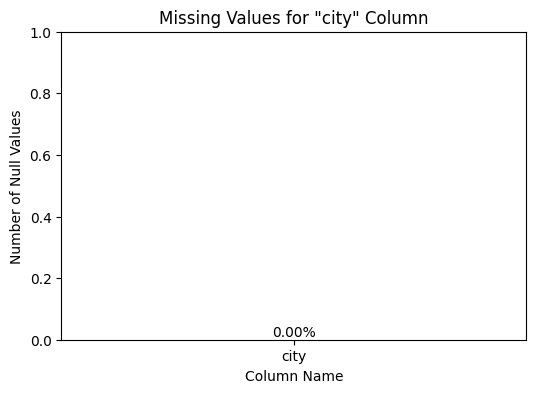

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get null count and percentage for 'city' column
null_count_city = df['city'].isnull().sum()
total_rows = len(df)
percentage_null_city = (null_count_city / total_rows) * 100

# Create a DataFrame for plotting
null_data_city = {
    'Column': ['city'],
    'Null_Count': [null_count_city],
    'Percentage': [percentage_null_city]
}
null_df_city = pd.DataFrame(null_data_city)

plt.figure(figsize=(6, 4))
sns.barplot(x='Column', y='Null_Count', data=null_df_city, hue='Column', legend=False, palette='viridis')

# Add percentage labels on top of the bars
for index, row in null_df_city.iterrows():
    plt.text(index, row['Null_Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.title('Missing Values for "city" Column')
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.ylim(0, max(1, null_df_city['Null_Count'].max() * 1.1)) # Adjust y-axis limit, ensure at least 1 for empty plot
plt.show()

### Age (65 Nulls / ~2.46% - Recalculation from BirthDate and Median Imputation)

### Recalculation and Imputation of Missing Values in the 'age' Column

- **Nature of the Column**: `age` is a numeric continuous column representing the current age of each billionaire.
- **Null Values**: There were **65** initial missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~2.46%** of the total entries in the dataset.

### Proposed and Applied Strategy

The strategy for handling the `age` column was updated to ensure maximum accuracy and completeness:

1.  **Recalculation from `birthDate` and `date`**: Instead of relying solely on the provided `age` column, the age is now explicitly calculated using the `birthDate` and `date` columns (the date the data was collected). This provides a more consistent and verifiable age for each billionaire.

2.  **Median Imputation for Remaining Nulls**: After recalculating, any `age` values that might still be null (e.g., if `birthDate` was also missing or invalid for a record) are filled with the **global median** of the newly calculated `age` values. The median is preferred over the mean because the age distribution, while generally central, can still be influenced by outliers (very young or very old billionaires), and the median provides a more robust measure of the typical age.

3.  **Why global median?**: Given that a small percentage (less than 5%) of values required imputation after recalculation, the global median provides a sufficiently accurate and simple estimate without the need for more complex group-based imputation, which would offer only marginal gains in precision for such a small fraction of data.

### Outcome
All 65 initially missing `age` values, plus any others that might have arisen from recalculation issues, have been successfully imputed. **Zero persons removed**, and no null values remain in the `age` column.

In [ ]:
print("=== AGE - BEFORE (recalculation) ===")
print(f"Null values in 'age': {df['age'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

# Convert birthDate and date columns to datetime objects
df['birthDate'] = pd.to_datetime(df['birthDate'])
df['date'] = pd.to_datetime(df['date'])

# Calculate age from birthDate and the fixed date
# Assuming 'date' column is the reference for when the data was collected (e.g., 2023-04-04)
df['age'] = (df['date'] - df['birthDate']).dt.days / 365.25

# Fill any remaining nulls in the newly calculated 'age' column with its median
age_median_recalculated = df['age'].median()
df['age'].fillna(age_median_recalculated, inplace=True)

print("\n=== AGE - AFTER (recalculation and imputation) ===")
print(f"Null values in 'age': {df['age'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")
print(f"Median value used for remaining nulls: {age_median_recalculated}")

=== AGE - BEFORE (recalculation) ===
Null values in 'age': 65
Dataset shape: (2638, 30)

=== AGE - AFTER (recalculation and imputation) ===
Null values in 'age': 0
Dataset shape: (2638, 30)
Median value used for remaining nulls: 65.7180013689254


/tmp/ipykernel_599/204862767.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median_recalculated, inplace=True)


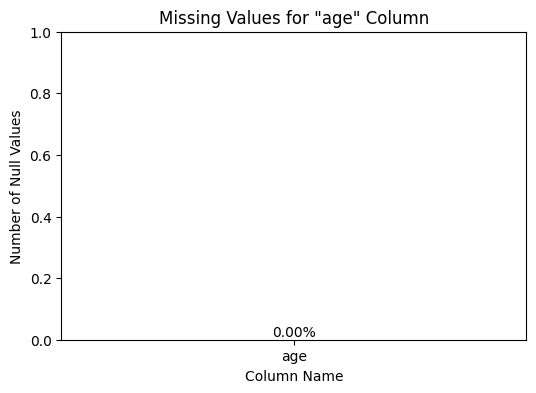

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get null count and percentage for 'age' column
null_count_age = df['age'].isnull().sum()
total_rows = len(df)
percentage_null_age = (null_count_age / total_rows) * 100

# Create a DataFrame for plotting
null_data_age = {
    'Column': ['age'],
    'Null_Count': [null_count_age],
    'Percentage': [percentage_null_age]
}
null_df_age = pd.DataFrame(null_data_age)

plt.figure(figsize=(6, 4))
sns.barplot(x='Column', y='Null_Count', data=null_df_age, hue='Column', legend=False, palette='viridis')

# Add percentage labels on top of the bars
for index, row in null_df_age.iterrows():
    plt.text(index, row['Null_Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.title('Missing Values for "age" Column')
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.ylim(0, max(1, null_df_age['Null_Count'].max() * 1.1)) # Adjust y-axis limit, ensure at least 1 for empty plot
plt.show()

### Organization (2313 Nulls / ~87% - Column Elimination)

### Elimination of the 'organization' Column

- **Nature of the Column**: `organization` is a categorical column representing the organization or company associated with each billionaire.
- **Null Values**: There were **2313** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~87%** of the total entries in the dataset.

### Proposed and Applied Strategy

Following Tan et al. (Section 2.2.1), when a column has an overwhelming proportion of missing values, eliminating the entire column is the appropriate strategy. The book explicitly warns that eliminating attributes should be done with caution — but only when the attribute may be critical to the analysis. At 87% missing, `organization` cannot be considered reliable or representative.

1. **Why eliminate the column entirely?**: With only 13% of values present, any analysis using this column would be based on a heavily biased and unrepresentative subset of billionaires. Keeping it would add noise rather than signal.
2. **No recovery step applicable**: Unlike `country`, there is no related column that could reliably substitute for `organization`.
3. **Outcome**: Column `organization` permanently removed from the dataset. **Zero persons removed.**



In [ ]:
print("=== ORGANIZATION - BEFORE ===")
print(f"Null values in 'organization': {df['organization'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

# Drop organization column entirely
df.drop(columns=['organization'], inplace=True)

print("\n=== ORGANIZATION - AFTER ===")
print(f"'organization' column exists: {'organization' in df.columns}")
print(f"Dataset shape: {df.shape}")

=== ORGANIZATION - BEFORE ===
Null values in 'organization': 2313
Dataset shape: (2638, 30)

=== ORGANIZATION - AFTER ===
'organization' column exists: False
Dataset shape: (2638, 29)


### State (1885 Nulls / ~71% - Column Elimination)

### Elimination of the 'state' Column

- **Nature of the Column**: `state` is a categorical column representing the state of residence of each billionaire.
- **Null Values**: There were **1885** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~71%** of the total entries in the dataset.

### Proposed and Applied Strategy

Columns with a majority of missing values should be eliminated. At 71% missing, `state` fails to represent the dataset in any meaningful way.

Additionally, from an analytical standpoint, **`city` was chosen as the preferred geographic granularity** over `state` for this analysis. City provides more specific location context and is already complete after our previous imputation step. Retaining `state` alongside `city` would introduce redundancy while simultaneously bringing in a column that is 71% empty — a combination that offers no analytical benefit.

1. **Why city over state?**: City is more granular, more complete, and already treated in our pipeline. State adds no additional value given city is present.
2. **Outcome**: Column `state` permanently removed from the dataset. **Zero persons removed.**

In [ ]:
print("=== STATE - BEFORE ===")
print(f"Null values in 'state': {df['state'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

# Drop state column entirely
df.drop(columns=['state'], inplace=True)

print("\n=== STATE - AFTER ===")
print(f"'state' column exists: {'state' in df.columns}")
print(f"Dataset shape: {df.shape}")

=== STATE - BEFORE ===
Null values in 'state': 1885
Dataset shape: (2638, 29)

=== STATE - AFTER ===
'state' column exists: False
Dataset shape: (2638, 28)


### Residence State Region (1891 Nulls / ~71% - Column Elimination)

### Elimination of the 'residenceStateRegion' Column

- **Nature of the Column**: `residenceStateRegion` is a categorical column representing the regional state of residence of each billionaire.
- **Null Values**: There were **1891** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~71%** of the total entries in the dataset.

### Proposed and Applied Strategy

`residenceStateRegion` is eliminated for the same dual reason as `state`:

1. **Missing data**: At 71% missing, the column is analytically unreliable. Following Tan et al., this volume of missing data makes column elimination the only defensible choice.
2. **Redundancy with city**: `residenceStateRegion` is a broader, less precise geographic descriptor than `city`. Since `city` is already retained and complete in our dataset, `residenceStateRegion` provides no additional geographic insight — it is both incomplete and redundant.
3. **Outcome**: Column `residenceStateRegion` permanently removed from the dataset. **Zero persons removed.**

In [ ]:
print("=== RESIDENCESTATEREGION - BEFORE ===")
print(f"Null values in 'residenceStateRegion': {df['residenceStateRegion'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

# Drop residenceStateRegion column entirely
df.drop(columns=['residenceStateRegion'], inplace=True)

print("\n=== RESIDENCESTATEREGION - AFTER ===")
print(f"'residenceStateRegion' column exists: {'residenceStateRegion' in df.columns}")
print(f"Dataset shape: {df.shape}")

=== RESIDENCESTATEREGION - BEFORE ===
Null values in 'residenceStateRegion': 1891
Dataset shape: (2638, 28)

=== RESIDENCESTATEREGION - AFTER ===
'residenceStateRegion' column exists: False
Dataset shape: (2638, 27)


### CPI Country (184 Nulls / ~6.97% - Group Fill by Country)

### Imputation of Missing Values in the 'cpi_country' Column

- **Nature of the Column**: `cpi_country` is a numeric continuous column representing the Consumer Price Index of the billionaire's country of residence — a measure of inflation and cost of living.
- **Null Values**: There were **184** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.97%** of the total entries in the dataset.

### Proposed and Applied Strategy

Following Tan et al. (Section 2.2.1), missing values are estimated using the attribute values of the most similar data points. Since CPI is a **country-level economic indicator** — meaning every billionaire from the same country shares the same CPI value — the most logical and precise estimation is to group by country and fill with the median CPI of other billionaires from that same country. **Zero persons removed.**

In [ ]:
print("=== CPI_COUNTRY - BEFORE ===")
print(f"Null values: {df['cpi_country'].isnull().sum()}")

df['cpi_country'] = df.groupby('country')['cpi_country'].transform(
    lambda x: x.fillna(x.median())
)

# If any country group had all nulls, fill with global median
df['cpi_country'].fillna(df['cpi_country'].median(), inplace=True)

print("=== CPI_COUNTRY - AFTER ===")
print(f"Null values: {df['cpi_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== CPI_COUNTRY - BEFORE ===
Null values: 184
=== CPI_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/596103609.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cpi_country'].fillna(df['cpi_country'].median(), inplace=True)


/tmp/ipykernel_599/3140972827.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Column', y='Null_Count', data=null_df, palette='viridis')


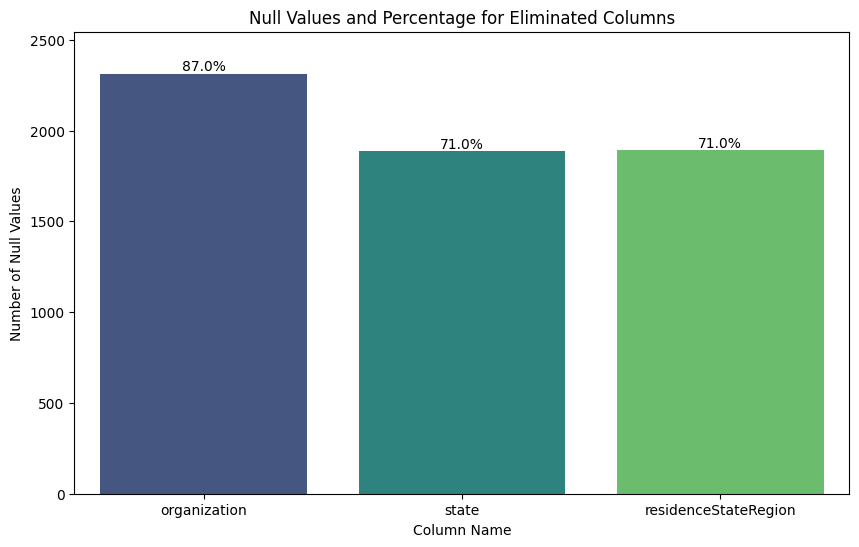

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from the user's prompt about the columns before elimination
null_data = {
    'Column': ['organization', 'state', 'residenceStateRegion'],
    'Null_Count': [2313, 1885, 1891],
    'Percentage': [87.0, 71.0, 71.0] # Assuming total entries as 2640 for percentage calculation for reference
}

null_df = pd.DataFrame(null_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Column', y='Null_Count', data=null_df, palette='viridis')

# Add percentage labels on top of the bars
for index, row in null_df.iterrows():
    plt.text(index, row['Null_Count'], f"{row['Percentage']:.1f}%", color='black', ha="center", va='bottom')

plt.title('Null Values and Percentage for Eliminated Columns')
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.ylim(0, max(null_df['Null_Count']) * 1.1) # Adjust y-axis limit for labels
plt.show()

### CPI Change Country (184 Nulls / ~6.97% - Group Fill by Country)

### Imputation of Missing Values in the 'cpi_change_country' Column

- **Nature of the Column**: `cpi_change_country` is a numeric continuous column representing the percentage change in the Consumer Price Index of the billionaire's country — essentially the rate of inflation change over time.
- **Null Values**: There were **184** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.97%** of the total entries in the dataset.

### Proposed and Applied Strategy

Identical reasoning to `cpi_country` — this is a country-level economic indicator shared by all billionaires from the same country. Group fill by country median is the most contextually accurate estimation available. A global median fallback handles any country group where all values are null. **Zero persons removed.**

In [ ]:
print("=== CPI_CHANGE_COUNTRY - BEFORE ===")
print(f"Null values: {df['cpi_change_country'].isnull().sum()}")

df['cpi_change_country'] = df.groupby('country')['cpi_change_country'].transform(
    lambda x: x.fillna(x.median())
)

df['cpi_change_country'].fillna(df['cpi_change_country'].median(), inplace=True)

print("=== CPI_CHANGE_COUNTRY - AFTER ===")
print(f"Null values: {df['cpi_change_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== CPI_CHANGE_COUNTRY - BEFORE ===
Null values: 184
=== CPI_CHANGE_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/2508238027.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cpi_change_country'].fillna(df['cpi_change_country'].median(), inplace=True)


### GDP Country (164 Nulls / ~6.21% - Group Fill by Country)

### Imputation of Missing Values in the 'gdp_country' Column

- **Nature of the Column**: `gdp_country` is a numeric continuous column representing the Gross Domestic Product of the billionaire's country of residence — a measure of total economic output.
- **Null Values**: There were **164** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.21%** of the total entries in the dataset.

### Proposed and Applied Strategy

GDP is a country-level macroeconomic indicator. All billionaires from the same country share the same GDP value, making group fill by country median the most precise and contextually honest imputation strategy available. A global median fallback is applied for any country where all GDP values are missing. **Zero persons removed.**

In [ ]:
print("=== GDP_COUNTRY - BEFORE ===")
print(f"Null values: {df['gdp_country'].isnull().sum()}")

# Convert 'gdp_country' to numeric, handling non-numeric characters
df['gdp_country'] = df['gdp_country'].astype(str).str.replace('$', '').str.replace(',', '', regex=True).astype(float)

df['gdp_country'] = df.groupby('country')['gdp_country'].transform(
    lambda x: x.fillna(x.median())
)

df['gdp_country'].fillna(df['gdp_country'].median(), inplace=True)

print("=== GDP_COUNTRY - AFTER ===")
print(f"Null values: {df['gdp_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== GDP_COUNTRY - BEFORE ===
Null values: 164
=== GDP_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1026313187.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gdp_country'].fillna(df['gdp_country'].median(), inplace=True)


### Gross Tertiary Education Enrollment (182 Nulls / ~6.89% - Group Fill by Country)

### Imputation of Missing Values in the 'gross_tertiary_education_enrollment' Column

- **Nature of the Column**: `gross_tertiary_education_enrollment` is a numeric continuous column representing the percentage of the eligible population enrolled in tertiary education in the billionaire's country.
- **Null Values**: There were **182** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.89%** of the total entries in the dataset.

### Proposed and Applied Strategy

Tertiary education enrollment is a country-level social indicator. All billionaires from the same country share this value, making group fill by country median the most contextually accurate estimation. A global median fallback handles any remaining nulls. **Zero persons removed.**

In [ ]:
print("=== GROSS_TERTIARY_EDUCATION_ENROLLMENT - BEFORE ===")
print(f"Null values: {df['gross_tertiary_education_enrollment'].isnull().sum()}")

df['gross_tertiary_education_enrollment'] = df.groupby('country')['gross_tertiary_education_enrollment'].transform(
    lambda x: x.fillna(x.median())
)

df['gross_tertiary_education_enrollment'].fillna(df['gross_tertiary_education_enrollment'].median(), inplace=True)

print("=== GROSS_TERTIARY_EDUCATION_ENROLLMENT - AFTER ===")
print(f"Null values: {df['gross_tertiary_education_enrollment'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== GROSS_TERTIARY_EDUCATION_ENROLLMENT - BEFORE ===
Null values: 182
=== GROSS_TERTIARY_EDUCATION_ENROLLMENT - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1397929078.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gross_tertiary_education_enrollment'].fillna(df['gross_tertiary_education_enrollment'].median(), inplace=True)


### Life Expectancy Country (182 Nulls / ~6.89% - Group Fill by Country)

### Imputation of Missing Values in the 'life_expectancy_country' Column

- **Nature of the Column**: `life_expectancy_country` is a numeric continuous column representing the average life expectancy in the billionaire's country of residence.
- **Null Values**: There were **182** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.89%** of the total entries in the dataset.

### Proposed and Applied Strategy

Life expectancy is a country-level health indicator shared by all billionaires from the same country. Group fill by country median is applied, with a global median fallback for any country where all values are null. **Zero persons removed.**

In [ ]:
print("=== LIFE_EXPECTANCY_COUNTRY - BEFORE ===")
print(f"Null values: {df['life_expectancy_country'].isnull().sum()}")

df['life_expectancy_country'] = df.groupby('country')['life_expectancy_country'].transform(
    lambda x: x.fillna(x.median())
)

df['life_expectancy_country'].fillna(df['life_expectancy_country'].median(), inplace=True)

print("=== LIFE_EXPECTANCY_COUNTRY - AFTER ===")
print(f"Null values: {df['life_expectancy_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== LIFE_EXPECTANCY_COUNTRY - BEFORE ===
Null values: 182
=== LIFE_EXPECTANCY_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/631630910.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['life_expectancy_country'].fillna(df['life_expectancy_country'].median(), inplace=True)


### Tax Revenue Country (183 Nulls / ~6.93% - Group Fill by Country)

### Imputation of Missing Values in the 'tax_revenue_country_country' Column

- **Nature of the Column**: `tax_revenue_country_country` is a numeric continuous column representing the tax revenue as a percentage of GDP for the billionaire's country of residence.
- **Null Values**: There were **183** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.93%** of the total entries in the dataset.

### Proposed and Applied Strategy

Tax revenue is a country-level fiscal indicator shared by all billionaires from the same country. Group fill by country median is applied, with a global median fallback for any country where all values are null. **Zero persons removed.**

In [ ]:
print("=== TAX_REVENUE_COUNTRY_COUNTRY - BEFORE ===")
print(f"Null values: {df['tax_revenue_country_country'].isnull().sum()}")

df['tax_revenue_country_country'] = df.groupby('country')['tax_revenue_country_country'].transform(
    lambda x: x.fillna(x.median())
)

df['tax_revenue_country_country'].fillna(df['tax_revenue_country_country'].median(), inplace=True)

print("=== TAX_REVENUE_COUNTRY_COUNTRY - AFTER ===")
print(f"Null values: {df['tax_revenue_country_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== TAX_REVENUE_COUNTRY_COUNTRY - BEFORE ===
Null values: 183
=== TAX_REVENUE_COUNTRY_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1148504498.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tax_revenue_country_country'].fillna(df['tax_revenue_country_country'].median(), inplace=True)


### Total Tax Rate Country (182 Nulls / ~6.89% - Group Fill by Country)

### Imputation of Missing Values in the 'total_tax_rate_country' Column

- **Nature of the Column**: `total_tax_rate_country` is a numeric continuous column representing the total tax rate as a percentage of commercial profits in the billionaire's country of residence.
- **Null Values**: There were **182** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.89%** of the total entries in the dataset.

### Proposed and Applied Strategy

Total tax rate is a country-level fiscal indicator shared by all billionaires from the same country. Group fill by country median is applied, with a global median fallback for any country where all values are null. **Zero persons removed.**

In [ ]:
print("=== TOTAL_TAX_RATE_COUNTRY - BEFORE ===")
print(f"Null values: {df['total_tax_rate_country'].isnull().sum()}")

df['total_tax_rate_country'] = df.groupby('country')['total_tax_rate_country'].transform(
    lambda x: x.fillna(x.median())
)

df['total_tax_rate_country'].fillna(df['total_tax_rate_country'].median(), inplace=True)

print("=== TOTAL_TAX_RATE_COUNTRY - AFTER ===")
print(f"Null values: {df['total_tax_rate_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== TOTAL_TAX_RATE_COUNTRY - BEFORE ===
Null values: 182
=== TOTAL_TAX_RATE_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1475979854.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_tax_rate_country'].fillna(df['total_tax_rate_country'].median(), inplace=True)


### Population Country (164 Nulls / ~6.21% - Group Fill by Country)

### Imputation of Missing Values in the 'population_country' Column

- **Nature of the Column**: `population_country` is a numeric continuous column representing the total population of the billionaire's country of residence.
- **Null Values**: There were **164** missing values in this column.
- **Percentage of Missing Values**: These missing values constituted **~6.21%** of the total entries in the dataset.

### Proposed and Applied Strategy

Population is a country-level demographic indicator shared by all billionaires from the same country. Group fill by country median is applied, with a global median fallback for any country where all values are null. **Zero persons removed.**

In [ ]:
print("=== POPULATION_COUNTRY - BEFORE ===")
print(f"Null values: {df['population_country'].isnull().sum()}")

df['population_country'] = df.groupby('country')['population_country'].transform(
    lambda x: x.fillna(x.median())
)

df['population_country'].fillna(df['population_country'].median(), inplace=True)

print("=== POPULATION_COUNTRY - AFTER ===")
print(f"Null values: {df['population_country'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

=== POPULATION_COUNTRY - BEFORE ===
Null values: 164
=== POPULATION_COUNTRY - AFTER ===
Null values: 0
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1487445390.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['population_country'].fillna(df['population_country'].median(), inplace=True)


### Gross Primary Education Enrollment (181 Nulls / ~6.86% - Group Fill by Country)

### Re-imputation of Missing Values in the 'gross_primary_education_enrollment_country' Column

- **Nature of the Column**: `gross_primary_education_enrollment_country` is a numeric continuous column representing the percentage of the eligible population enrolled in primary education in the billionaire's country.
- **Null Values**: **181 values remain missing** after the previous group fill attempt.
- **Percentage of Missing Values**: These missing values constituted **~6.86%** of the total entries in the dataset.

### Why Did the Previous Step Fail?
The previous group fill by country left 181 nulls because some country groups had **all values missing** for this column — meaning there was no within-group median to compute. The global median fallback was not applied correctly in that step.

### Applied Fix
The group fill by country is re-applied, followed by an explicit global median fallback to catch any country group where all values were null. **Zero persons removed.**

In [ ]:
print("=== GROSS_PRIMARY_EDUCATION_ENROLLMENT_COUNTRY - BEFORE ===")
print(f"Null values: {df['gross_primary_education_enrollment_country'].isnull().sum()}")

# Re-apply group fill by country
df['gross_primary_education_enrollment_country'] = df.groupby('country')['gross_primary_education_enrollment_country'].transform(
    lambda x: x.fillna(x.median())
)

# Explicit global median fallback
global_median = df['gross_primary_education_enrollment_country'].median()
df['gross_primary_education_enrollment_country'].fillna(global_median, inplace=True)

print("=== GROSS_PRIMARY_EDUCATION_ENROLLMENT_COUNTRY - AFTER ===")
print(f"Null values: {df['gross_primary_education_enrollment_country'].isnull().sum()}")
print(f"Global median used as fallback: {global_median}")
print(f"Dataset shape: {df.shape}")

=== GROSS_PRIMARY_EDUCATION_ENROLLMENT_COUNTRY - BEFORE ===
Null values: 181
=== GROSS_PRIMARY_EDUCATION_ENROLLMENT_COUNTRY - AFTER ===
Null values: 0
Global median used as fallback: 101.8
Dataset shape: (2638, 27)


/tmp/ipykernel_599/1317520961.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gross_primary_education_enrollment_country'].fillna(global_median, inplace=True)


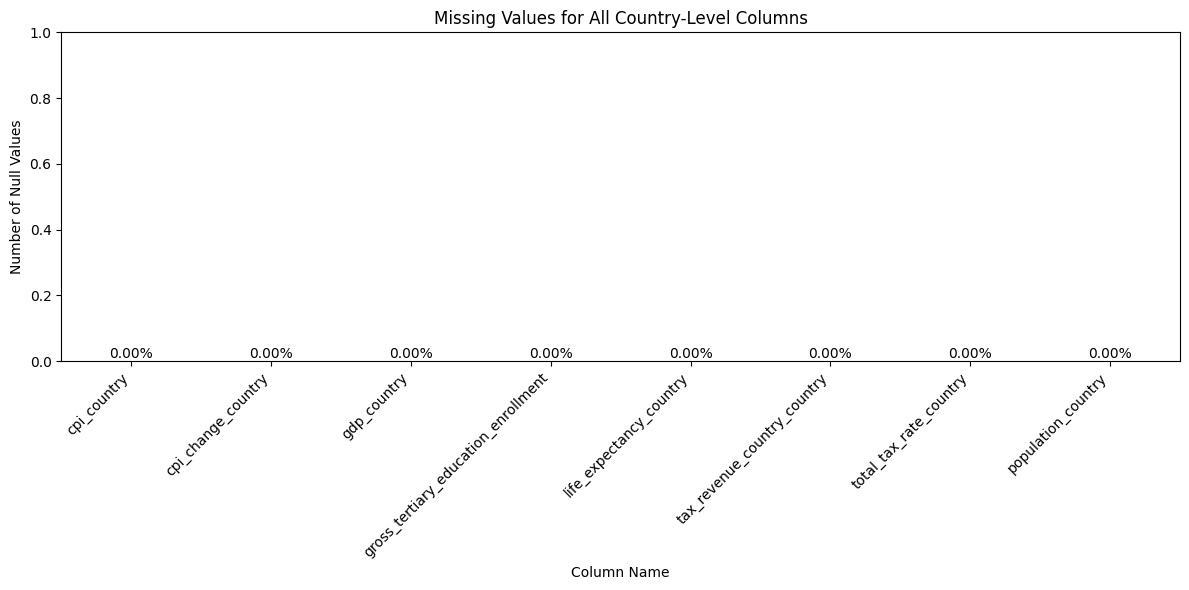

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

columns_to_check = [
    'cpi_country',
    'cpi_change_country',
    'gdp_country',
    'gross_tertiary_education_enrollment',
    'life_expectancy_country',
    'tax_revenue_country_country',
    'total_tax_rate_country',
    'population_country'
]

total_rows = len(df)

all_null_data = []
for col_name in columns_to_check:
    null_count = df[col_name].isnull().sum()
    percentage_null = (null_count / total_rows) * 100
    all_null_data.append({
        'Column': col_name,
        'Null_Count': null_count,
        'Percentage': percentage_null
    })

null_df_all = pd.DataFrame(all_null_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Column', y='Null_Count', data=null_df_all, hue='Column', legend=False, palette='viridis')

# Add percentage labels on top of the bars
for index, row in null_df_all.iterrows():
    plt.text(index, row['Null_Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.title('Missing Values for All Country-Level Columns')
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(1, null_df_all['Null_Count'].max() * 1.1)) # Adjust y-axis limit, ensure at least 1 for empty plot
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
finalWorth,0
category,0
personName,0
age,0
country,0
city,0
source,0
industries,0
countryOfCitizenship,0
selfMade,0


## Standardization of Industries and Sources

In order to facilitate the analysis and reduce the complexity of categorical variables, the attributes industries and source will be grouped into broader categories. These variables contain a large number of specific or highly detailed values, which can make pattern discovery more difficult during the data mining process. By aggregating similar values into higher-level categories—such as Technology, Energy, Finance, Real Estate, Manufacturing, Retail, and Mining—it is possible to simplify the dataset, improve interpretability, and enable the identification of more general patterns across industries and sources of wealth. The following code blocks implement the transformation required to perform this categorization.

### Industries

industries
Finance & Investments         372
Manufacturing                 323
Technology                    314
Fashion & Retail              266
Food & Beverage               212
Healthcare                    200
Real Estate                   193
Diversified                   187
Energy                        100
Media & Entertainment          91
Metals & Mining                74
Automotive                     73
Service                        53
Construction & Engineering     45
Logistics                      40
Sports                         39
Telecom                        31
Gambling & Casinos             25
Name: count, dtype: int64


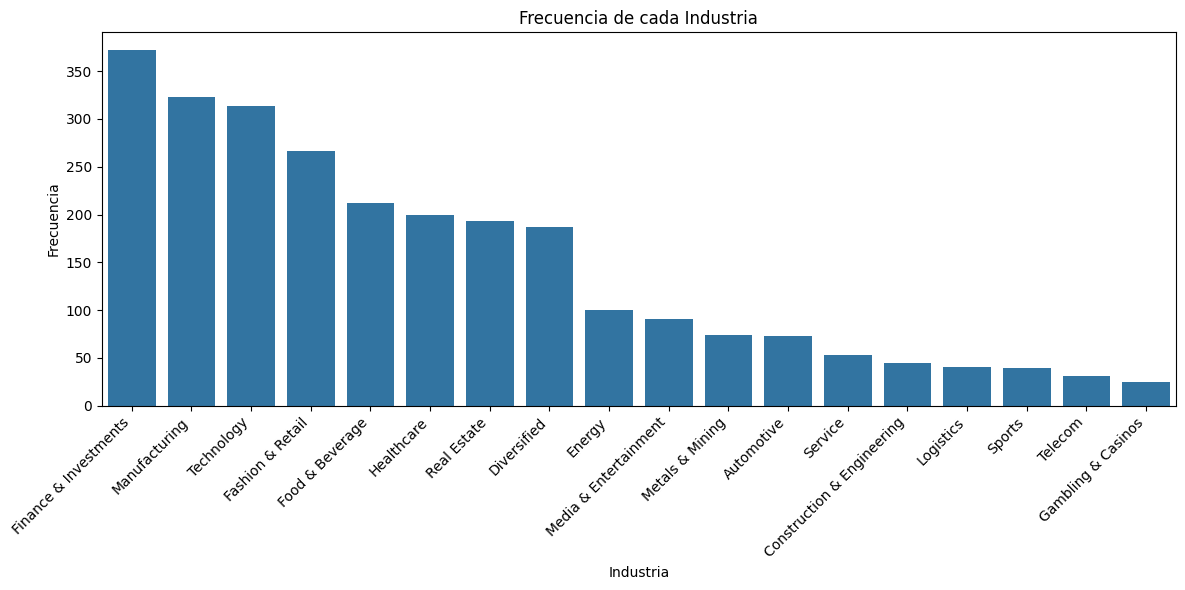

In [ ]:
industry_frequency = df['industries'].value_counts()
print(industry_frequency)

plt.figure(figsize=(12, 6))
sns.barplot(x=industry_frequency.index, y=industry_frequency.values)
plt.title('Frecuencia de cada Industria')
plt.xlabel('Industria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The original 18 categories have been consolidated into the following **9 broader macro-sectors**. This structure improves interpretability, reduces granularity, and aligns with common economic and investment classification frameworks (similar to GICS/MSCI style).

| Macro-Sector                          | Included Original Categories                                                                 | Rationale / Typical Use Case |
|---------------------------------------|----------------------------------------------------------------------------------------------|------------------------------|
| Technology & Telecommunications       | Technology, Telecom                                                                          | High-growth sectors focused on innovation, software, hardware, networks, and digital services |
| Financials & Investments              | Finance & Investments                                                                        | Banking, hedge funds, private equity, venture capital, asset management, insurance, and related financial activities |
| Consumer Discretionary                | Fashion & Retail, Automotive, Sports, Gambling & Casinos                                     | Non-essential consumer spending: luxury goods, fashion, vehicles, entertainment, gaming, and leisure activities |
| Consumer Staples                      | Food & Beverage                                                                              | Essential everyday consumption: food production, beverages, agribusiness, and related staples |
| Healthcare                            | Healthcare                                                                                   | Pharmaceuticals, biotechnology, medical devices, hospitals, and healthcare services |
| Real Estate & Construction            | Real Estate, Construction & Engineering                                                      | Property development, commercial/residential real estate, infrastructure projects, and engineering services |
| Industrials & Manufacturing           | Manufacturing, Service, Metals & Mining, Automotive (industrial aspects)                     | Heavy industry, production processes, metals extraction/processing, machinery, and industrial services |
| Energy & Natural Resources            | Energy                                                                                       | Oil & gas, renewable energy, utilities, petrochemicals, and energy infrastructure |
| Media, Entertainment & Leisure        | Media & Entertainment, Gambling & Casinos (entertainment part), Sports (media/leisure aspects) | Content creation, broadcasting, streaming, gaming, casinos, sports entertainment, and leisure industries |

In [ ]:
industry_macro_mapping = {
    'Technology': 'Technology & Telecommunications',
    'Telecom': 'Technology & Telecommunications',
    'Finance & Investments': 'Financials & Investments',
    'Fashion & Retail': 'Consumer Discretionary',
    'Automotive': 'Consumer Discretionary',
    'Sports': 'Consumer Discretionary',
    'Gambling & Casinos': 'Consumer Discretionary',
    'Food & Beverage': 'Consumer Staples',
    'Healthcare': 'Healthcare',
    'Real Estate': 'Real Estate & Construction',
    'Construction & Engineering': 'Real Estate & Construction',
    'Manufacturing': 'Industrials & Manufacturing',
    'Service': 'Industrials & Manufacturing',
    'Metals & Mining': 'Industrials & Manufacturing',
    'Energy': 'Energy & Natural Resources',
    'Media & Entertainment': 'Media, Entertainment & Leisure',
    'Diversified': 'Other'
}

# Apply the mapping to the 'industries' column
df['industries'] = df['industries'].map(industry_macro_mapping)


Frequency of each Industry Macro-Sector:
industries
Industrials & Manufacturing        450
Consumer Discretionary             403
Financials & Investments           372
Technology & Telecommunications    345
Real Estate & Construction         238
Consumer Staples                   212
Healthcare                         200
Other                              187
Energy & Natural Resources         100
Media, Entertainment & Leisure      91
Name: count, dtype: int64


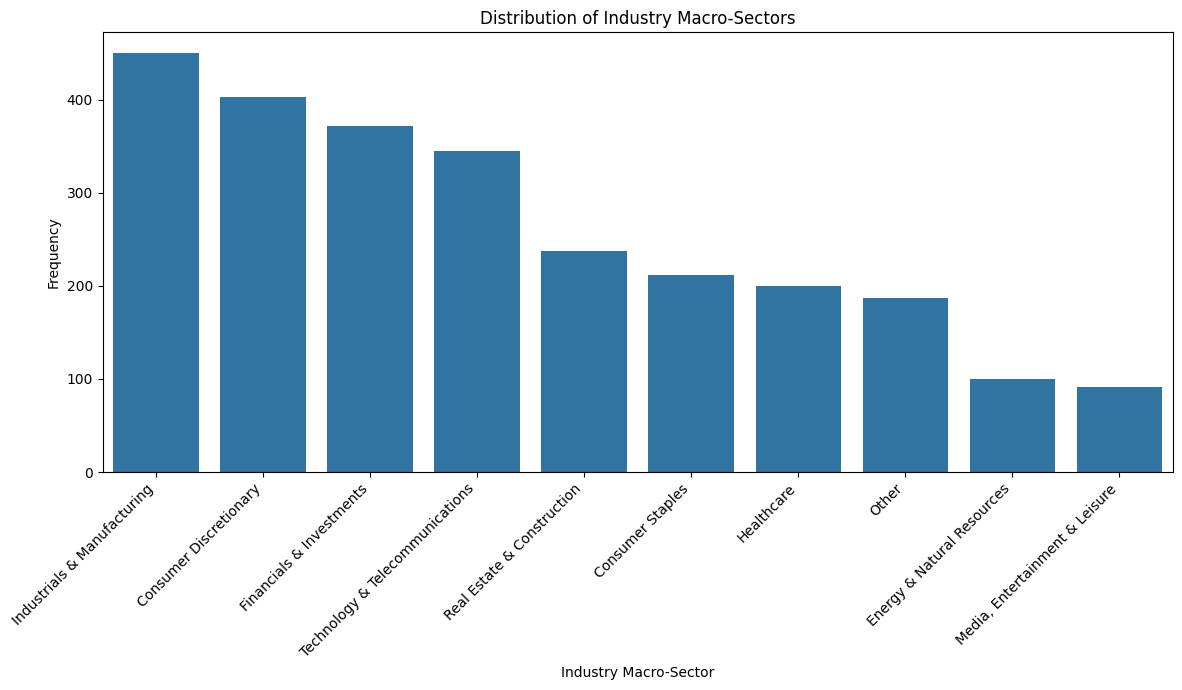

In [ ]:
# Display the frequency of the new macro-sectors
industry_macro_frequency = df['industries'].value_counts()
print("Frequency of each Industry Macro-Sector:")
print(industry_macro_frequency)

# Create a bar plot for the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=industry_macro_frequency.index, y=industry_macro_frequency.values)
plt.title('Distribution of Industry Macro-Sectors')
plt.xlabel('Industry Macro-Sector')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df[:20][['personName', 'industries']]

,personName,industries
0,Bernard Arnault & family,Consumer Discretionary
1,Elon Musk,Consumer Discretionary
2,Jeff Bezos,Technology & Telecommunications
3,Larry Ellison,Technology & Telecommunications
4,Warren Buffett,Financials & Investments
5,Bill Gates,Technology & Telecommunications
6,Michael Bloomberg,"Media, Entertainment & Leisure"
7,Carlos Slim Helu & family,Technology & Telecommunications
8,Mukesh Ambani,Other
9,Steve Ballmer,Technology & Telecommunications


### Sources

source
Real estate                     151
Investments                      92
Diversified                      91
Pharmaceuticals                  84
Software                         63
                               ... 
Bio-Pharma                        1
Industrial lasers                 1
Office real estate                1
Financial services, property      1
Electrical appliances             1
Name: count, Length: 905, dtype: int64
Number of Different Sources: 905


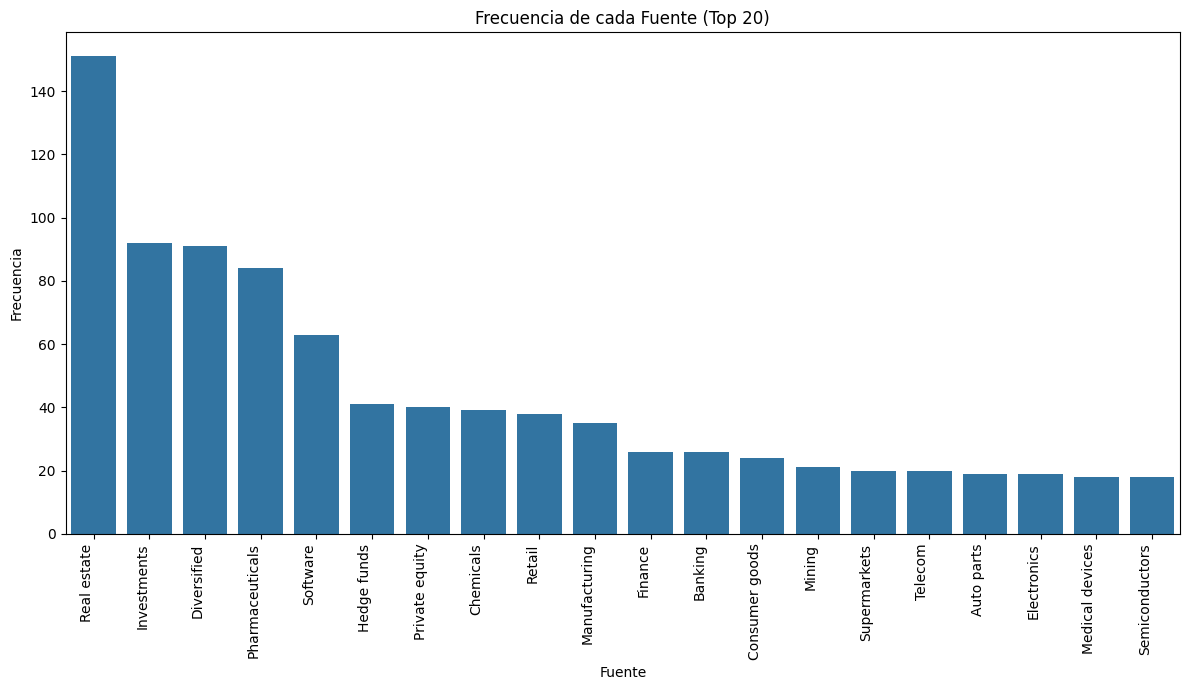

In [ ]:
source_frequency = df['source'].value_counts()
print(source_frequency)

print(f'Number of Different Sources: {len(source_frequency)}')
plt.figure(figsize=(12, 7))
sns.barplot(x=source_frequency.head(20).index, y=source_frequency.head(20).values)
plt.title('Frecuencia de cada Fuente (Top 20)')
plt.xlabel('Fuente')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# unique_sources = df['source'].unique()
# unique_sources_df = pd.DataFrame(unique_sources, columns=['source'])
# unique_sources_df.to_csv('unique_sources.csv', index=False)
# print("\nLista de macro-sectores guardada en 'unique_sources.csv'")

Due to the high cardinality of the original `source` variable, **all** unique entries have been grouped into the following broader macro-sectors.

| Macro-category                | Sources |
|-------------------------------|---------|
| Technology                    | Software, Business software, Software services, Fintech, Cloud computing, Cybersecurity, Data analytics, Facebook, Google, Microsoft, Samsung, Amazon, TikTok, Snapchat, Spotify, WhatsApp, Instagram, Twitter, LinkedIn, Pinterest, Zoom Video Communications, Oracle, Intel, Dell Technologies, SAP, Roku, Netflix, Apple, EBay, PayPal, Ecommerce, Online retail, Internet search, Social media, Technology, IT provider, Information technology, Computer hardware, Data centers, Internet media, Internet, Online services, Online entertainment, Web hosting, Mapping software, Healthcare software, E-commerce software, Payment software, Payments software, Messaging software, Security software, Payments, banking, Software firm, Copy machines, software, Computer networking, Ecommerce, Online payments, Online recruitment, Blockchain, technology, Blockchain technology, Internet and software, Search engine, Online dating, Cloud storage service, Video streaming app, Messaging app, Email marketing, Stock photos, Data management, IT consulting, IT consulting, outsourcing, Computer services, real estate, Hardware, Hardware stores, Virtual reality, 3D printing, Online universities, Education technology, Online apparel retail, Computer games, Videogames, gaming, Online games, Video games, Online gaming, Pachinko machines, Gambling software, AOL, Flipkart, Uber, WeWork, Yahoo, Netscape, investments, Twitter, Square, Groupon, investments, Facebook, investments, Netscape, investments, Tesla, SpaceX, Bloomberg LP, Dell Technologies, Oracle, Intel, SAP, Roku, Netflix, Apple, Disney, Google, Samsung, LinkedIn, Pinterest, Snapchat, Spotify, WhatsApp, Instagram, Twitter, Zoom Video Communications, Facebook, TikTok, Amazon, EBay, PayPal, Alibaba (implied in e-commerce patterns), cybersecurity, data analytics, wireless networking, sensors, smartphone components, smartphone screens, touch screens, sensor systems, sensor technology, microchip testing, semiconductor devices, semiconductor materials, lithium-ion battery cap, battery separators, battery components, solar wafers and modules, solar panel materials, photovoltaic equipment, solar inverters, power supply equipment, power strips, power strip, heating and cooling equipment, heating, cooling equipment, kitchen appliances, cooking appliances, home appliances, vacuums, coffee makers, hair dryers, mattresses, carpet, flooring, tiles, glass, plastics, textiles, polyester, apparel, textiles, apparel, readymade garments, textiles, paper, paper manufacturing, pulp and paper, paper & related products, timberland, lumber mills, lumber, furniture retailing, furniture retail, home furnishings, appliances, electrical appliances, consumer electronics, lighting, LED lighting, gym equipment, fitness equipment, toys, lego, plush toys, train cars, automotive brakes, brakes, investments, tires, diversified, tyre manufacturing machinery, tire, motorcycles, two wheelers, two-wheelers, electric scooters, electric bikes, scooters, tractors, construction equipment, construction vehicles, mining, machinery, oilfield equipment |
| Finance and Investments       | Investments, Hedge funds, Private equity, Venture capital, Finance, Banking, Financial services, Insurance, Asset management, Money management, Mutual funds, Investment banking, Cryptocurrency, Hedge fund, Franklin Templeton, Fidelity, Bloomberg LP, Quicken Loans, TD Ameritrade, Discount brokerage, Stock brokerage, Investing, Finance and investments, Finance services, Leveraged buyouts, Tech investments, Biotech investing, Biotech and investments, Finance, asset management, Banking, investments, Banking, credit cards, Trading, investments, Insurance, investments, Real estate, private equity, Investments, real estate, Oil, investments, Energy, investments, Software, investments, Retail, investments, Construction, investments, Fashion retail, investments, Banking, minerals, Oil, banking, telecom, Banking, tobacco, Consumer products, banking, Banking, insurance, Banking, shipping, Banking, real estate, Banking, oil, Banking, development, Finance, real estate, Finance, telecommunications, Finance, development, Financial technology, Financial information, Financial services, property, Commodities, investments, Telecom, investments, Investments, energy, Investments, art, Investments, energy drinks, Energy drinks,investments, Berkshire Hathaway, Quicken Loans, TD Ameritrade, Fidelity, Franklin Templeton, Discount brokerage, Stock brokerage, Investment banking, Venture capital, Private equity, Hedge funds, Cryptocurrency exchange, Mutual funds, Leveraged buyouts, Tech investments, Biotech investing, Executive search, investments, Groupon, investments, Facebook, investments, Netscape, investments, Twitter, Square, Banking, credit cards, Electronic trading, Stock exchange, Mortgage lender, Payroll services, Payroll processing, Payroll software, Accounting services, Payment processing, Mobile payments, Online payments, Payments, banking |
| Real Estate and Construction  | Real estate, Construction, Building materials, Hotels, Hotels, investments, Real estate, investments, Construction, investments, Retail, real estate, Shopping centers, Shopping malls, Homebuilding, Real estate development, Real estate management, Office real estate, Airports, real estate, Real estate, hotels, Real estate, airport, Real estate, construction, Construction, real estate, Real estate, media, Real estate, retail, Real estate, manufacturing, Real estate, electronics, Real estate, gambling, Real estate finance, Real estate services, Homebuilder, Real estate, diversified, Real Estate, Real estate, grains, Plush toys, real estate, Real estate, shipping, Real estate, media, Real estate, coal, Real estate, oil, Casinos, real estate, Casinos, hotels, Casinos, property, energy, Real estate, private equity, Fertilizer, real estate, Palm oil, property, Palm oil, shipping, property, Hotels, diversified, Hotels, energy, Hotels, motels, Casinos/hotels, Alcohol, real estate, Oil, real estate, Oil, coal, real estate, Precious metals, real estate, Energy, real estate, Utilities, real estate, Airports, real estate, Logistics, real estate, Transport, engineering, real estate, Construction, pipes, banking, Construction equipment, media, Construction, mining machinery, Construction Vehicles, Construction, pipes, chemicals, Construction, mining, Building, development, Engineering, construction, Home sales, Home improvement stores, Self storage, Storage facilities, Toll roads, Infrastructure, Infrastructure, commodities, Homebuilding, insurance, Homebuilding, NFL team, Real estate, airport, Real estate, hotels, Real estate, construction, Real estate, diversified, Real estate finance, Real estate services, Real estate development, Homebuilder, Office real estate, Airports, real estate, Logistics, real estate |
| Manufacturing and Industrial  | Manufacturing, Machinery, Auto parts, Electronics, Electrical equipment, Steel, Chemicals, Petrochemicals, Cement, Industrial equipment, Machine tools, Elevators, escalators, Tires, Automotive, Appliances, Furniture, Packaging, Paints, Adhesives, Cleaning products, Flavorings, Household chemicals, Specialty chemicals, Chemical products, Refinery, chemicals, Chemicals, spandex, Chemicals, logistics, Chemicals, investments, Textiles, petrochemicals, Textile, chemicals, Gas, chemicals, Energy, chemicals, Construction materials, Pipe Manufacturing, Plastic pipes, Steel pipes, Steel tubes, Stainless steel products, Powdered metal, Metal processing, Metalworking tools, Metals processing, Industrial machinery, Precision machinery, Hydraulic machinery, Hydraulic pumps, Air compressors, Pneumatic equipments, Valves, Valve manufacturing, Fasteners, Scaffolding, cement mixers, Power tools, Hand tools, Measuring instruments, Testing equipment, Industrial lasers, Industrial explosives, Electrodes, Quartz products, Pearlescent pigments, Silicon, Optical components, Acoustic components, Fiber optic cables, Cables & wires, Wire & cables, paints, Printed circuit boards, Electronic components, Electronics components, Smartphone screens, Touch screens, Sensor systems, Sensors, Sensor technology, Microchip testing, Semiconductor devices, Semiconductor materials, Lithium-ion battery cap, Battery separators, Battery components, Solar wafers and modules, Solar panel materials, Photovoltaic equipment, Solar inverters, Power supply equipment, Power strips, Power strip, Heating and cooling equipment, Heating, cooling equipment, Kitchen appliances, Cooking appliances, Home appliances, Vacuums, Coffee makers, Hair dryers, Mattresses, Carpet, Flooring, Tiles, Glass, Plastics, Textiles, Polyester, Apparel, Textiles, apparel, Readymade garments, Textiles, paper, Paper manufacturing, Pulp and paper, Paper & related products, Timberland, lumber mills, Lumber, Furniture retailing, Furniture retail, Home furnishings, Appliances, Electrical appliances, Consumer electronics, Lighting, LED lighting, Gym equipment, Fitness equipment, Toys, Lego, Plush toys, Train cars, Automotive brakes, Brakes, investments, Tires, diversified, Tyre manufacturing machinery, Tire, Motorcycles, Two wheelers, Two-wheelers, Electric scooters, Electric bikes, scooters, Tractors, Construction equipment, Construction Vehicles, Mining, machinery, Oilfield equipment, Fasteners, Carbon fiber products, Industrial machinery, Petro Firbe, Petro Fibre, Machine tools, Elevators, escalators |
| Energy and Utilities          | Oil & gas, Oil, Natural gas, Pipelines, Coal, Renewable energy, Solar panels, Energy, Petrochemicals, Liquefied natural gas, Oil refining, Utilities, Power equipment, Electric power, Oil refinery, Oil trading, Getty Oil, Oil and gas, Oil, gas, Oil, semiconductor, Oil, mining, Oil, banking, Oil, coal, real estate, Oilfield equipment, Solar, Solar energy, Solar equipment, Solar systems, Photovoltaics, Solar energy equipment, Solar panel components, Natural gas distribution, Gas stations, Gas stations, retail, Energy services, Energy drink, Energy drinks, Red Bull, Sports drink, Energy, sports, Energy, banking, construction, Energy, chemicals, Energy, sports, entertainment, Power, Utilities, diversified, Aluminum, utilities, Liquefied natural gas, Electric power, Oil refinery, Getty Oil, Space, energy |
| Mining and Materials          | Mining, Steel, Coal, Metals, Aluminum, Lithium, Commodities, Iron ore mining, Nickel, Cobalt, Gold, Minerals processing, Non-ferrous metals, Metals and mining, Metals, mining, Metals, coal, Gold, coal mining, Palm oil, nickel mining, Mining, commodities, Mining, copper products, Mining, steel, Mining, metals, machinery, Mining, banking, Mining, banking, hotels, Coal mines, Coal, investments, Fertilizers, coal, Diamonds, Titanium, Lithium, Lithium batteries, Lithium battery, Aluminum products, Aluminium, Aluminum, diversified, Steel production, Steel, diversified, Steel, autoparts, Steel, coal, Steel, transport, Steel, mining, Coking, Forestry, mining |
| Healthcare and Pharmaceuticals| Pharmaceuticals, Biotech, Medical devices, Healthcare, Hospitals, Medical equipment, Medical technology, Biopharmaceuticals, Vaccines, Generic drugs, Biotechnology, Medical diagnostics, Clinical diagnostics, Pharmaceutical, Phamaceuticals, Biomedical products, Medical products, Medical services, Medical packaging, Medical cosmetics, Medical diagnostic equipment, Dental implants, Dental materials, Dental products, Hearing aids, Prosthetics, Optometry, Contact Lens, Eyeglases, Eyeglasses, Health care, Healthcare services, Healthcare IT, Health IT, Health products, Nutrition, wellness products, Nutritional supplements, Infant formula, Vitamins, Herbal products, Biochemicals, Biotech, vaccines, Biotech, investments, Clinical trials, Laboratory services, Drug distribution, Pharmacy, Pharmacies, Drugstores, Johnson & Johnson, sports, Genentech, Apple, Property, healthcare, Bio-Pharma, Medical patents, Medical diagnostics, Sports data (health-related), Animal health, investments |
| Retail and Consumer Goods     | Retail, Supermarkets, Consumer goods, Fashion retail, Luxury goods, Cosmetics, Apparel, E-commerce, Shoes, Eyeglasses, Furniture, IKEA, Home Depot, Walmart, Zara, H&M, LVMH, Estée Lauder, L'Oréal, Chanel, Hermes, Spanx, Urban Outfitters, Department stores, Convenience stores, Grocery stores, Grocery delivery service, Drugstores, Pharmacies, Liquor stores, supermarkets, Aldi, Trader Joe's, Best Buy, Mobile phone retailer, Sporting goods retail, Dick's Sporting Goods, Sports retailing, Fitness clothing, Sneakers, sportswear, Sports shoes, Under Armour, New Balance, Reebok, Lululemon, Columbia Sportswear, Nike, Personal care goods, Beauty products, Skincare, Hair care products, Hair products, Shapewear, cosmetics, reality TV, cosmetics, Consumer products, Consumer, Consumer electronics, Home furnishings, Mattresses, Carpets, Flooring, Sunglasses, Jewelry, Jewellery, Diamond jewelry, Fine jewelry, Toys, Lego, Plush toys, Pet food, Candy, pet food, Candy, Snacks, Snack bars, Chewing gum, Greek yogurt, Frozen foods, Household chemicals, Cleaning products, Hygiene products, Pest control, Stationery, Gap, Sears, Price comparison website, Used cars, Fast fashion, Fashion retailer, Online apparel retail, Retail stores, Retail, wholesale, Retailing, Convinience stores, Walmart, logistics (retail aspect) |
| Food and Agriculture          | Agribusiness, Food, Beverages, Beer, Coffee, Dairy, Meat processing, Poultry processing, Agriculture, Food processing, Restaurants, Fast food, Candy, Snacks, Campbell Soup, Coca-Cola bottler, Coca Cola Israel, Red Bull, Heineken, Nutella, chocolates, Subway, In-N-Out Burger, Little Caesars Pizza, Starbucks, Waffle House, Chick-fil-A, Bakery chain, Bakeries, Food distribution, Food delivery, Food service, Food services, Food & beverage retailing, Soft drinks, fast food, Alcoholic beverages, Liquor, Spirits, Vodka, Tequila, Beer distribution, Brewery, Wine, Energy drinks, Sports drink, Hot sauce, Salsa, Flavorings, Soy sauce, Edible oil, Palm oil, Sugar, ethanol, Cement, sugar, Feed, Seed production, Poultry, Poultry genetics, Poultry breeding, Pig breeding, Fish farming, Fisheries, Beef processing, Beef packing, Chicken processing, Meat processing, Cheese, Dairy, Dairy & consumer products, Slim-Fast, Nutritional supplements, Cargill, Agriculture, land, Dole, real estate (agri aspect), Retail, agribusiness, Food, retail, Food, beverages, Snacks, beverages |
| Media and Entertainment       | Media, Online games, Video games, Casinos, Publishing, Cable television, Netflix, Spotify, Gaming, Entertainment, TV network, Movies, Sports teams, TV shows, TV broadcasting, TV programs, Movies, television, Movies, digital effects, Movies, record labels, Movies, investments, Video streaming, Live entertainment, Cirque du Soleil, Amusement parks, Marvel comics, Star Wars, Record label, Music, Music, cosmetics, Music, chemicals, Magazines, media, Newspapers, TV network, Satellite TV, DirecTV, Comcast, Online media, Internet media, Digital advertising, Advertising, Billboards, Los Angeles Angels, Ticketing service, Online gambling, Gambling, Gambling products, Casinos, mixed martial arts, Casinos, banking, Online entertainment, TV, movie production, Reality TV, Houston Rockets, entertainment, Charlotte Hornets, endorsements, Dallas Cowboys, San Francisco 49ers, Washington Commanders, New Orleans Saints, Philadelphia Eagles, Indianapolis Colts, Las Vegas Raiders, Tennessee Titans, Golden State Warriors, Sports teams, Sports, Sports team, Formula One, Nascar, racing, Entertainment, Margaritaville, Star Wars, Dolby Laboratories, Publishing, Advertising |
| Transportation and Logistics  | Shipping, Logistics, Airlines, Package delivery, Transportation, Ports, Trucking, FedEx, U-Haul, EasyJet, Car rentals, Cruises, Carnival Cruises, Aircraft leasing, Airline, Low-cost airlines, Budget airline, Airlines, Airports, Airport management, Airport, Toll roads, Transport, logistics, Express delivery, Book distribution, transportation, Shipping, airlines, Shipping, seafood, Real estate, shipping, Walmart, logistics, Logistics, real estate, Logistics, baseball, Car rentals, Aviation, Trucking, FedEx, U-Haul, EasyJet, Airlines, Airports, investments (transport aspect), Transport, engineering, real estate, Transport, logistics, Express delivery |

In [ ]:
macro_categories_mapping = {
    "Technology": [
        "software", "business software", "fintech", "cloud computing", "cybersecurity", "data analytics",
        "facebook", "google", "microsoft", "samsung", "amazon", "tiktok", "snapchat", "spotify", "whatsapp",
        "instagram", "twitter", "linkedin", "pinterest", "zoom video communications", "oracle", "intel",
        "dell technologies", "sap", "roku", "netflix", "apple", "ebay", "paypal", "ecommerce",
        "online retail", "internet search", "social media", "technology", "it provider", "information technology",
        "computer hardware", "data centers", "internet media", "internet", "online services", "online entertainment",
        "web hosting", "mapping software", "healthcare software", "e-commerce software", "payment software",
        "payments software", "messaging software", "security software", "software firm",
        "copy machines", "computer networking", "online payments", "online recruitment", "blockchain",
        "blockchain technology", "internet and software", "search engine", "online dating", "cloud storage service",
        "video streaming app", "messaging app", "email marketing", "stock photos", "data management",
        "it consulting", "it consulting, outsourcing", "computer services", "hardware", "hardware stores",
        "virtual reality", "3d printing", "online universities", "education technology", "online apparel retail",
        "computer games", "videogames", "gaming", "online games", "video games", "online gaming",
        "pachinko machines", "gambling software", "tech", "walmart", "alibaba", "uber", "wework", "yahoo", "netscape",
        "square", "groupon", "bloomberg lp", "tesla", "spacex", "disney", "sensors", "smartphone components",
        "smartphone screens", "touch screens", "sensor systems", "sensor technology", "microchip testing",
        "semiconductor devices", "semiconductor materials", "lithium-ion battery cap", "battery separators",
        "battery components", "solar wafers and modules", "solar panel materials", "photovoltaic equipment",
        "solar inverters", "power supply equipment", "power strips", "power strip", "heating and cooling equipment",
        "heating, cooling equipment", "kitchen appliances", "cooking appliances", "home appliances", "vacuums",
        "coffee makers", "hair dryers", "mattresses", "carpet", "flooring", "tiles", "glass", "plastics", "textiles",
        "polyester", "apparel", "readymade garments", "paper manufacturing", "pulp and paper", "paper & related products",
        "timberland", "lumber mills", "lumber", "furniture retailing", "furniture retail", "home furnishings",
        "electrical appliances", "consumer electronics", "lighting", "led lighting", "gym equipment", "fitness equipment",
        "toys", "lego", "plush toys", "train cars", "automotive brakes", "brakes", "tires", "diversified",
        "tyre manufacturing machinery", "tire", "motorcycles", "two wheelers", "electric scooters", "electric bikes",
        "scooters", "tractors", "construction equipment", "construction vehicles", "mining, machinery", "oilfield equipment",
        "aol", "flipkart" # Added from the Technology list
    ],
    "Finance and Investments": [
        "investments", "hedge funds", "private equity", "venture capital", "finance", "banking",
        "financial services", "insurance", "asset management", "money management", "mutual funds",
        "investment banking", "cryptocurrency", "hedge fund", "franklin templeton", "fidelity",
        "bloomberg lp", "quicken loans", "td ameritrade", "discount brokerage", "stock brokerage",
        "investing", "finance and investments", "finance services", "leveraged buyouts", "tech investments",
        "biotech investing", "biotech and investments", "finance, asset management", "banking, investments",
        "banking, credit cards", "trading, investments", "insurance, investments", "real estate, private equity",
        "oil, investments", "energy, investments", "software, investments", "retail, investments",
        "construction, investments", "fashion retail, investments", "banking, minerals", "oil, banking, telecom",
        "banking, tobacco", "consumer products, banking", "banking, insurance", "banking, shipping",
        "banking, real estate", "banking, oil", "banking, development", "finance, real estate",
        "finance, telecommunications", "finance, development", "financial technology", "financial information",
        "financial services, property", "commodities, investments", "telecom, investments", "investments, energy",
        "investments, art", "investments, energy drinks", "energy drinks,investments", "berkshire hathaway",
        "executive search", "groupon, investments", "facebook, investments", "netscape, investments",
        "twitter, square", "electronic trading", "stock exchange", "mortgage lender", "payroll services",
        "payroll processing", "payroll software", "accounting services", "payment processing",
        "mobile payments", "online payments", "payments, banking", "capital", "markets", "funds" # More general terms
    ],
    "Real Estate and Construction": [
        "real estate", "construction", "building materials", "hotels", "hotels, investments",
        "real estate, investments", "construction, investments", "retail, real estate", "shopping centers",
        "shopping malls", "homebuilding", "real estate development", "real estate management",
        "office real estate", "airports, real estate", "real estate, hotels", "real estate, airport",
        "real estate, construction", "construction, real estate", "real estate, media", "real estate, retail",
        "real estate, manufacturing", "real estate, electronics", "real estate, gambling", "real estate finance",
        "real estate services", "homebuilder", "real estate, diversified", "real estate, grains",
        "plush toys, real estate", "real estate, shipping", "real estate, coal", "real estate, oil",
        "casinos, real estate", "casinos, hotels", "casinos, property, energy", "real estate, private equity",
        "fertilizer, real estate", "palm oil, property", "palm oil, shipping, property", "hotels, diversified",
        "hotels, energy", "hotels, motels", "casinos/hotels", "alcohol, real estate", "oil, real estate",
        "oil, coal, real estate", "precious metals, real estate", "energy, real estate", "utilities, real estate",
        "logistics, real estate", "transport, engineering, real estate", "construction, pipes, banking",
        "construction equipment, media", "construction, mining machinery", "construction vehicles",
        "construction, pipes, chemicals", "construction, mining", "building, development",
        "engineering, construction", "home sales", "home improvement stores", "self storage", "storage facilities",
        "toll roads", "infrastructure", "infrastructure, commodities", "property", "nfl team" # Added from description
    ],
    "Manufacturing and Industrial": [
        "manufacturing", "machinery", "auto parts", "electronics", "electrical equipment", "steel",
        "chemicals", "petrochemicals", "cement", "industrial equipment", "machine tools", "elevators",
        "escalators", "tires", "automotive", "appliances", "furniture", "packaging", "paints",
        "adhesives", "cleaning products", "flavorings", "household chemicals", "specialty chemicals",
        "chemical products", "refinery, chemicals", "chemicals, spandex", "chemicals, logistics",
        "chemicals, investments", "textiles, petrochemicals", "textile, chemicals", "gas, chemicals",
        "energy, chemicals", "construction materials", "pipe manufacturing", "plastic pipes", "steel pipes",
        "steel tubes", "stainless steel products", "powdered metal", "metal processing", "metalworking tools",
        "industrial machinery", "precision machinery", "hydraulic machinery", "hydraulic pumps", "air compressors",
        "pneumatic equipments", "valves", "valve manufacturing", "fasteners", "scaffolding, cement mixers",
        "power tools", "hand tools", "measuring instruments", "testing equipment", "industrial lasers",
        "industrial explosives", "electrodes", "quartz products", "pearlescent pigments", "silicon",
        "optical components", "acoustic components", "fiber optic cables", "cables & wires", "wire & cables",
        "printed circuit boards", "electronic components", "electronics components", "smartphone screens",
        "touch screens", "sensor systems", "sensors", "sensor technology", "microchip testing",
        "semiconductor devices", "semiconductor materials", "lithium-ion battery cap", "battery separators",
        "battery components", "solar wafers and modules", "solar panel materials", "photovoltaic equipment",
        "solar inverters", "power supply equipment", "power strips", "heating and cooling equipment",
        "heating, cooling equipment", "kitchen appliances", "cooking appliances", "home appliances", "vacuums",
        "coffee makers", "hair dryers", "mattresses", "carpet", "flooring", "tiles", "glass", "plastics",
        "polyester", "apparel", "readymade garments", "paper manufacturing", "pulp and paper", "paper & related products",
        "timberland", "lumber mills", "lumber", "furniture retailing", "furniture retail", "home furnishings",
        "electrical appliances", "consumer electronics", "lighting", "led lighting", "gym equipment",
        "fitness equipment", "toys", "lego", "plush toys", "train cars", "automotive brakes",
        "tyre manufacturing machinery", "motorcycles", "two wheelers", "electric scooters", "electric bikes",
        "scooters", "tractors", "construction equipment", "construction vehicles", "mining, machinery",
        "oilfield equipment", "carbon fiber products", "petro firbe", "petro fibre", "machine tools"
    ],
    "Energy and Utilities": [
        "oil & gas", "oil", "natural gas", "pipelines", "coal", "renewable energy", "solar panels",
        "energy", "petrochemicals", "liquefied natural gas", "oil refining", "utilities",
        "power equipment", "electric power", "oil refinery", "oil trading", "oil and gas", "oil, gas",
        "oil, semiconductor", "oil, mining", "oil, banking", "oil, coal, real estate", "oilfield equipment",
        "solar", "solar energy", "solar equipment", "solar systems", "photovoltaics",
        "solar energy equipment", "solar panel components", "natural gas distribution", "gas stations",
        "gas stations, retail", "energy services", "energy drink", "energy drinks", "sports drink",
        "energy, sports", "energy, banking, construction", "energy, chemicals", "energy, sports, entertainment",
        "power, utilities, diversified", "aluminum, utilities", "space, energy", "getty oil", "red bull"
    ],
    "Mining and Materials": [
        "mining", "steel", "coal", "metals", "aluminum", "lithium", "commodities",
        "iron ore mining", "nickel", "cobalt", "gold", "minerals processing", "non-ferrous metals",
        "metals and mining", "metals, mining", "metals, coal", "gold, coal mining",
        "palm oil, nickel mining", "mining, commodities", "mining, copper products", "mining, steel",
        "mining, metals, machinery", "mining, banking", "mining, banking, hotels", "coal mines",
        "coal, investments", "fertilizers, coal", "diamonds", "titanium", "lithium batteries",
        "lithium battery", "aluminum products", "aluminium", "aluminum, diversified", "steel production",
        "steel, diversified", "steel, autoparts", "steel, coal", "steel, transport", "steel, mining", "coking",
        "forestry, mining"
    ],
    "Healthcare and Pharmaceuticals": [
        "pharmaceuticals", "biotech", "medical devices", "healthcare", "hospitals", "medical equipment",
        "medical technology", "biopharmaceuticals", "vaccines", "generic drugs", "biotechnology",
        "medical diagnostics", "clinical diagnostics", "pharmaceutical", "phamaceuticals",
        "biomedical products", "medical products", "medical services", "medical packaging",
        "medical cosmetics", "medical diagnostic equipment", "dental implants", "dental materials",
        "dental products", "hearing aids", "prosthetics", "optometry", "contact lens", "eyeglases",
        "eyeglasses", "health care", "healthcare services", "healthcare it", "health it",
        "health products", "nutrition", "wellness products", "nutritional supplements", "infant formula",
        "vitamins", "herbal products", "biochemicals", "biotech, vaccines", "biotech, investments",
        "clinical trials", "laboratory services", "drug distribution", "pharmacy", "pharmacies",
        "drugstores", "johnson & johnson", "genentech", "apple", "property, healthcare", "bio-pharma",
        "medical patents", "medical diagnostics", "animal health"
    ],
    "Retail and Consumer Goods": [
        "retail", "supermarkets", "consumer goods", "fashion retail", "luxury goods", "cosmetics",
        "apparel", "e-commerce", "shoes", "eyeglasses", "furniture", "home depot", "zara", "h&m",
        "lvmh", "estée lauder", "l'oréal", "chanel", "hermes", "spanx", "urban outfitters",
        "department stores", "convenience stores", "grocery stores", "grocery delivery service",
        "drugstores", "pharmacies", "liquor stores", "aldi", "trader joe's", "best buy",
        "mobile phone retailer", "sporting goods retail", "dick's sporting goods", "sports retailing",
        "fitness clothing", "sneakers", "sportswear", "sports shoes", "under armour", "new balance",
        "reebok", "lululemon", "columbia sportswear", "nike", "personal care goods", "beauty products",
        "skincare", "hair care products", "hair products", "shapewear", "cosmetics, reality tv",
        "cosmetics, consumer products", "consumer, consumer electronics", "home furnishings", "mattresses",
        "carpets", "flooring", "sunglasses", "jewelry", "jewellery", "diamond jewelry", "fine jewelry",
        "toys", "lego", "plush toys", "pet food", "candy", "pet food", "candy, snacks", "snack bars",
        "chewing gum", "greek yogurt", "frozen foods", "household chemicals", "cleaning products",
        "hygiene products", "pest control", "stationery", "gap", "sears", "price comparison website",
        "used cars", "fast fashion", "fashion retailer", "online apparel retail", "retail stores",
        "retail, wholesale", "retailing", "convinience stores", "walmart, logistics (retail aspect)"
    ],
    "Food and Agriculture": [
        "agribusiness", "food", "beverages", "beer", "coffee", "dairy", "meat processing",
        "poultry processing", "agriculture", "food processing", "restaurants", "fast food", "candy",
        "snacks", "campbell soup", "coca-cola bottler", "coca cola israel", "red bull", "heineken", "nutella",
        "chocolates", "subway", "in-n-out burger", "little caesars pizza", "starbucks", "waffle house",
        "chick-fil-a", "bakery chain", "bakeries", "food distribution", "food delivery", "food service",
        "food services", "food & beverage retailing", "soft drinks", "fast food", "alcoholic beverages",
        "liquor", "spirits", "vodka", "tequila", "beer distribution", "brewery", "wine",
        "energy drinks", "sports drink", "hot sauce", "salsa", "flavorings", "soy sauce", "edible oil",
        "palm oil", "sugar", "ethanol", "cement, sugar", "feed", "seed production", "poultry",
        "poultry genetics", "poultry breeding", "pig breeding", "fish farming", "fisheries",
        "beef processing", "beef packing", "chicken processing", "meat processing", "cheese", "dairy",
        "dairy & consumer products", "slim-fast", "nutritional supplements", "cargill", "dole"
    ],
    "Media and Entertainment": [
        "media", "online games", "video games", "casinos", "publishing", "cable television",
        "netflix", "spotify", "gaming", "entertainment", "tv network", "movies", "sports teams",
        "tv shows", "tv broadcasting", "tv programs", "movies, television", "movies, digital effects",
        "movies, record labels", "movies, investments", "video streaming", "live entertainment",
        "cirque du soleil", "amusement parks", "marvel comics", "star wars", "record label",
        "music", "music, cosmetics", "music, chemicals", "magazines, media", "newspapers",
        "tv network", "satellite tv", "directv", "comcast", "online media", "internet media",
        "digital advertising", "advertising", "billboards", "los angeles angels", "ticketing service",
        "online gambling", "gambling", "gambling products", "casinos, mixed martial arts",
        "casinos, banking", "online entertainment", "tv, movie production", "reality tv",
        "houston rockets", "charlotte hornets", "dallas cowboys", "san francisco 49ers",
        "washington commanders", "new orleans saints", "philadelphia eagles", "indianapolis colts",
        "las vegas raiders", "tennessee titans", "golden state warriors", "sports team", "formula one",
        "nascar", "racing", "margartaville", "dolby laboratories"
    ],
    "Transportation and Logistics": [
        "shipping", "logistics", "airlines", "package delivery", "transportation", "ports",
        "trucking", "fedex", "u-haul", "easyjet", "car rentals", "cruises", "carnival cruises",
        "aircraft leasing", "airline", "low-cost airlines", "budget airline", "airports",
        "airport management", "airport", "toll roads", "transport, logistics",
        "express delivery", "book distribution", "shipping, airlines",
        "shipping, seafood", "real estate, shipping", "walmart, logistics", "logistics, real estate",
        "logistics, baseball", "automobiles", "cars", "aviation"
    ]
}

def clean_and_flatten_keywords(keyword_list):
    flat_keywords = []
    for item in keyword_list:
        parts = [p.strip().lower() for p in item.split(',')]
        flat_keywords.extend(parts)
    return list(set(flat_keywords))

cleaned_macro_categories_mapping = {
    key: clean_and_flatten_keywords(value) for key, value in macro_categories_mapping.items()
}

def map_source_to_macro_sector_new(source):
    source_lower = str(source).lower()

    # Iterate through categories in a specific order (priority)
    # Place more specific or common categories higher if overlaps exist.

    # Technology (often has company names)
    for keyword in cleaned_macro_categories_mapping["Technology"]:
        if keyword in source_lower:
            return "Technology"

    # Finance and Investments (often very broad 'investments')
    for keyword in cleaned_macro_categories_mapping["Finance and Investments"]:
        if keyword in source_lower:
            return "Finance and Investments"

    # Retail and Consumer Goods (has many common brand names/products)
    for keyword in cleaned_macro_categories_mapping["Retail and Consumer Goods"]:
        if keyword in source_lower:
            return "Retail and Consumer Goods"

    # Manufacturing and Industrial
    for keyword in cleaned_macro_categories_mapping["Manufacturing and Industrial"]:
        if keyword in source_lower:
            return "Manufacturing and Industrial"

    # Real Estate and Construction
    for keyword in cleaned_macro_categories_mapping["Real Estate and Construction"]:
        if keyword in source_lower:
            return "Real Estate and Construction"

    # Energy and Utilities
    for keyword in cleaned_macro_categories_mapping["Energy and Utilities"]:
        if keyword in source_lower:
            return "Energy and Utilities"

    # Mining and Materials
    for keyword in cleaned_macro_categories_mapping["Mining and Materials"]:
        if keyword in source_lower:
            return "Mining and Materials"

    # Healthcare and Pharmaceuticals
    for keyword in cleaned_macro_categories_mapping["Healthcare and Pharmaceuticals"]:
        if keyword in source_lower:
            return "Healthcare and Pharmaceuticals"

    # Food and Agriculture
    for keyword in cleaned_macro_categories_mapping["Food and Agriculture"]:
        if keyword in source_lower:
            return "Food and Agriculture"

    # Media and Entertainment
    for keyword in cleaned_macro_categories_mapping["Media and Entertainment"]:
        if keyword in source_lower:
            return "Media and Entertainment"

    # Transportation and Logistics
    for keyword in cleaned_macro_categories_mapping["Transportation and Logistics"]:
        if keyword in source_lower:
            return "Transportation and Logistics"

    return "Other"

df['source'] = df['source'].apply(map_source_to_macro_sector_new)

print(df['source'].head())

0    Retail and Consumer Goods
1                   Technology
2                   Technology
3                   Technology
4      Finance and Investments
Name: source, dtype: object


Let's see the frequency distribution of our Standardization

source
Finance and Investments           890
Technology                        585
Manufacturing and Industrial      258
Healthcare and Pharmaceuticals    184
Retail and Consumer Goods         180
Food and Agriculture              153
Other                             121
Real Estate and Construction       98
Energy and Utilities               66
Media and Entertainment            45
Transportation and Logistics       41
Mining and Materials               17
Name: count, dtype: int64


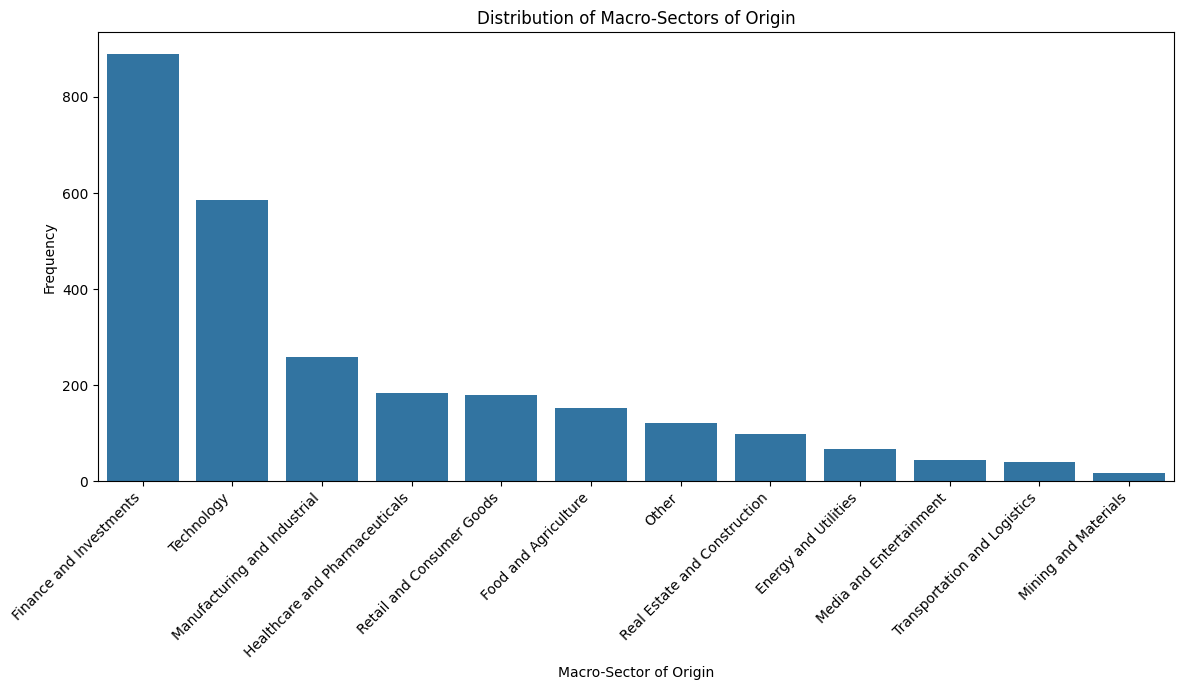

In [ ]:
source_macro_frequency = df['source'].value_counts()
print(source_macro_frequency)

plt.figure(figsize=(12, 7))
sns.barplot(x=source_macro_frequency.index, y=source_macro_frequency.values)
plt.title('Distribution of Macro-Sectors of Origin')
plt.xlabel('Macro-Sector of Origin')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df[:20][['personName', 'source', 'industries']]

,personName,source,industries
0,Bernard Arnault & family,Retail and Consumer Goods,Consumer Discretionary
1,Elon Musk,Technology,Consumer Discretionary
2,Jeff Bezos,Technology,Technology & Telecommunications
3,Larry Ellison,Technology,Technology & Telecommunications
4,Warren Buffett,Finance and Investments,Financials & Investments
5,Bill Gates,Technology,Technology & Telecommunications
6,Michael Bloomberg,Technology,"Media, Entertainment & Leisure"
7,Carlos Slim Helu & family,Finance and Investments,Technology & Telecommunications
8,Mukesh Ambani,Technology,Other
9,Steve Ballmer,Technology,Technology & Telecommunications


## Add Number of Companies of each Millonaire

To enrich the billionaires dataset, a Python script was developed to estimate the number of companies associated with each person (numberOfCompanies) using the attribute personName. Since the original dataset does not include information about the companies related to each billionaire, the script retrieves external information from Wikidata, an open knowledge base that stores structured data about people and organizations.

The script reads the list of names from a CSV file and, for each person, performs a search through the Wikidata API to identify the corresponding entity in the database. Once the correct entity is found, the script retrieves its structured information and analyzes specific properties that represent relationships between a person and organizations, such as being a founder, CEO, chairperson, manager, or employee. Each organization identified through these relationships is treated as a company associated with that person.

To ensure reliable results, the code also performs basic preprocessing of names (for example, removing suffixes like “& family”), handles potential connection errors, and introduces delays between requests to avoid overloading the external API. The companies found for each person are stored without duplicates and counted to produce an estimated number of companies.

Finally, the computed values are added as a new column (numberOfCompanies) to the dataset and exported to a new CSV file. This process produces an enriched dataset that can be used in subsequent stages of data analysis or data mining.

It is also worth mentioning that the code includes comments throughout the script in order to make the implementation easier to understand and to facilitate future modifications or extensions.

### Wiki API Code to get the number of Companies for each Millonaire

**Warning: Run the following commented code only if you dont have person_companies.csv dataset**

In [ ]:
# df_people = pd.read_csv("person_names.csv")

# # Headers required for Wikidata to accept the requests
# HEADERS = {
#     'User-Agent': 'DataMiningProject/1.0 (Educational Purpose)',
#     'Accept': 'application/json'
# }

# def clean_name(name):
#     """Cleans the name by removing ' & family' and other suffixes"""
#     name = name.replace(" & family", "")
#     name = name.strip()
#     return name

# def get_company_count(name, max_retries=3):
#     """Gets the number of companies associated with a person from Wikidata"""

#     # Clean the name
#     clean = clean_name(name)

#     for attempt in range(max_retries):
#         try:
#             # Step 1: Search for the person's entity
#             search_url = "https://www.wikidata.org/w/api.php"
#             search_params = {
#                 "action": "wbsearchentities",
#                 "search": clean,
#                 "language": "en",
#                 "format": "json",
#                 "type": "item",
#                 "limit": 1
#             }

#             search_response = requests.get(
#                 search_url,
#                 params=search_params,
#                 headers=HEADERS,
#                 timeout=30
#             )
#             search_response.raise_for_status()
#             search_data = search_response.json()

#             if not search_data.get("search"):
#                 print(f"  ⚠️ No entity found for: {clean}")
#                 return 0

#             entity_id = search_data["search"][0]["id"]
#             label = search_data['search'][0].get('label', '')
#             print(f"  ✓ Found: {entity_id} - {label}")

#             # Step 2: Retrieve the entity data
#             entity_url = f"https://www.wikidata.org/wiki/Special:EntityData/{entity_id}.json"
#             entity_response = requests.get(
#                 entity_url,
#                 headers=HEADERS,
#                 timeout=30
#             )
#             entity_response.raise_for_status()
#             entity_data = entity_response.json()

#             claims = entity_data["entities"][entity_id].get("claims", {})

#             # Wikidata properties related to companies
#             company_properties = {
#                 "P112": "founder of",           # founder of
#                 "P169": "chief executive officer", # CEO of
#                 "P488": "chairperson",          # chairperson
#                 "P1037": "director/manager",    # director/manager
#                 "P108": "employer"              # employer
#             }

#             companies = set()

#             # Collect all companies/organizations
#             for prop_id, prop_name in company_properties.items():
#                 if prop_id in claims:
#                     for claim in claims[prop_id]:
#                         try:
#                             # Get the company ID
#                             company_id = claim["mainsnak"]["datavalue"]["value"]["id"]
#                             companies.add(company_id)
#                         except (KeyError, TypeError):
#                             continue

#             count = len(companies)
#             print(f"  → Companies found: {count}")
#             return count

#         except requests.exceptions.Timeout:
#             if attempt < max_retries - 1:
#                 print(f"  ⏱ Timeout, retrying ({attempt + 1}/{max_retries})...")
#                 time.sleep(2)
#                 continue
#             else:
#                 print(f"  ✗ Timeout after {max_retries} attempts")
#                 return 0

#         except requests.exceptions.RequestException as e:
#             if attempt < max_retries - 1:
#                 print(f"  ⚠️ Error: {str(e)[:50]}, retrying...")
#                 time.sleep(2)
#                 continue
#             else:
#                 print(f"  ✗ Connection error: {str(e)[:100]}")
#                 return 0

#         except Exception as e:
#             print(f"  ✗ Error: {str(e)[:100]}")
#             return 0

#     return 0

In [ ]:
# df_people = pd.read_csv("person_names.csv")

# # Required headers so Wikidata accepts the requests
# HEADERS = {
#     "User-Agent": "DataMiningProject/1.0 (Educational Purpose)",
#     "Accept": "application/json"
# }

# def clean_name(name):
#     """Cleans the name by removing ' & family' and other suffixes"""
#     name = name.replace(" & family", "")
#     name = name.strip()
#     return name


# def get_company_count(name, max_retries=3):
#     """Gets the number of companies associated with a person from Wikidata"""

#     # Clean the name
#     clean = clean_name(name)

#     for attempt in range(max_retries):
#         try:
#             # Step 1: Search for the person's entity
#             search_url = "https://www.wikidata.org/w/api.php"
#             search_params = {
#                 "action": "wbsearchentities",
#                 "search": clean,
#                 "language": "en",
#                 "format": "json",
#                 "type": "item",
#                 "limit": 1
#             }

#             search_response = requests.get(
#                 search_url,
#                 params=search_params,
#                 headers=HEADERS,
#                 timeout=30
#             )
#             search_response.raise_for_status()
#             search_data = search_response.json()

#             if not search_data.get("search"):
#                 print(f"  ⚠️ No entity found for: {clean}")
#                 return 0

#             entity_id = search_data["search"][0]["id"]
#             label = search_data["search"][0].get("label", "")
#             print(f"  ✓ Found: {entity_id} - {label}")

#             # Step 2: Get entity data
#             entity_url = f"https://www.wikidata.org/wiki/Special:EntityData/{entity_id}.json"
#             entity_response = requests.get(
#                 entity_url,
#                 headers=HEADERS,
#                 timeout=30
#             )
#             entity_response.raise_for_status()
#             entity_data = entity_response.json()

#             claims = entity_data["entities"][entity_id].get("claims", {})

#             # Wikidata properties related to companies
#             company_properties = {
#                 "P112": "founder of",
#                 "P169": "chief executive officer",
#                 "P488": "chairperson",
#                 "P1037": "director/manager",
#                 "P108": "employer",
#                 "P1830": "owner of"
#             }

#             companies = set()

#             # Collect all companies/organizations
#             for prop_id, prop_name in company_properties.items():
#                 if prop_id in claims:
#                     for claim in claims[prop_id]:
#                         try:
#                             # Get the company ID
#                             company_id = claim["mainsnak"]["datavalue"]["value"]["id"]
#                             companies.add(company_id)
#                         except (KeyError, TypeError):
#                             continue

#             count = len(companies)
#             print(f"  → Companies found: {count}")
#             return count

#         except requests.exceptions.Timeout:
#             if attempt < max_retries - 1:
#                 print(f"  ⏱ Timeout, retrying ({attempt + 1}/{max_retries})...")
#                 time.sleep(2)
#                 continue
#             else:
#                 print(f"  ✗ Timeout after {max_retries} attempts")
#                 return 0

#         except requests.exceptions.RequestException as e:
#             if attempt < max_retries - 1:
#                 print(f"  ⚠️ Error: {str(e)[:50]}, retrying...")
#                 time.sleep(2)
#                 continue
#             else:
#                 print(f"  ✗ Connection error: {str(e)[:100]}")
#                 return 0

#         except Exception as e:
#             print(f"  ✗ Error: {str(e)[:100]}")
#             return 0

#     return 0


# # First verify connection
# print("Checking connection to Wikidata...")
# try:
#     test_response = requests.get(
#         "https://www.wikidata.org/w/api.php?action=wbsearchentities&search=test&language=en&format=json",
#         headers=HEADERS,
#         timeout=15
#     )

#     if test_response.status_code == 200:
#         print("✓ Successful connection\n")
#     else:
#         print(f"⚠️ Response code: {test_response.status_code}\n")

# except Exception as e:
#     print(f"✗ Connection error: {e}")
#     print("Check your internet connection or proxy\n")


# # Process each name
# results = []

# print("Searching companies for each person...\n")

# for idx, name in enumerate(df_people["personName"], 1):
#     print(f"{idx}. {name}")

#     count = get_company_count(name)
#     results.append(count)

#     # Pause to avoid overloading the API
#     time.sleep(1.5)
#     print()


# # Save results
# df_people["number_of_companies"] = results

# df_people[["personName", "number_of_companies"]].to_csv(
#     "person_companies.csv",
#     index=False
# )

# print("✓ Results saved in 'person_companies.csv'")
# print("\nSummary:")
# print(df_people[["personName", "number_of_companies"]])

### Number of Companies Frequency Distribution

count    2638.000000
mean        1.709629
std         3.219182
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       100.000000
Name: number_of_companies, dtype: float64


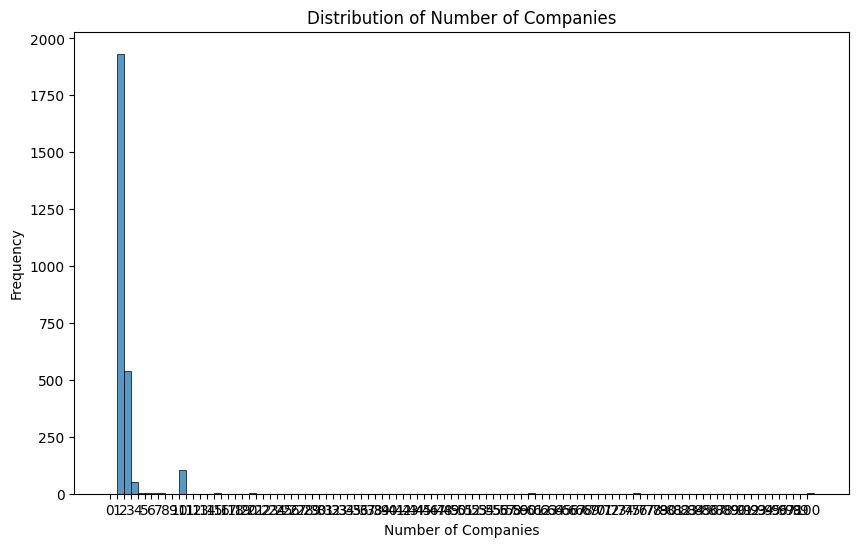

In [ ]:
print(df['number_of_companies'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['number_of_companies'], bins=range(int(df['number_of_companies'].max()) + 2), kde=False)
plt.title('Distribution of Number of Companies')
plt.xlabel('Number of Companies')
plt.ylabel('Frequency')
plt.xticks(range(int(df['number_of_companies'].max()) + 1))
plt.show()


In [ ]:
Companies_frequency = df['number_of_companies'].value_counts()
print(Companies_frequency)

number_of_companies
1      1933
2       538
10      105
3        53
75        1
60        1
5         1
100       1
7         1
15        1
6         1
20        1
4         1
Name: count, dtype: int64


In [ ]:
df.to_csv("dataset_cleaned.csv", index=False)

#Level 2 — Aggregation by Country

In this section, we transform the dataset from the individual level (billionaires) to the country level.

The goal is to construct variables that describe the economic structure of each country based on its billionaires.

We will calculate three types of characteristics:

Sectoral Structure

Wealth Structure

Demographic Structure

These variables will be used later to analyze economic patterns across countries.

## Wealth Structure

For each country, we calculate:

total_billionaires → total number of billionaires

selfmade_ratio → percentage of self-made billionaires

inherited_ratio → percentage of inherited wealth

This helps us understand whether wealth comes primarily from innovation and entrepreneurship or from inheritance.

In [ ]:
# Wealth structure per country

wealth_structure = df.groupby("country").agg(

    total_billionaires=("personName", "count"),

    selfmade_ratio=("selfMade", "mean")

).reset_index()

# inherited wealth ratio
wealth_structure["inherited_ratio"] = 1 - wealth_structure["selfmade_ratio"]

wealth_structure.head()

,country,total_billionaires,selfmade_ratio,inherited_ratio
0,Algeria,1,1.000000,0.000000
1,Andorra,1,0.000000,1.000000
2,Argentina,4,1.000000,0.000000
3,Armenia,1,1.000000,0.000000
4,Australia,43,0.674419,0.325581


## Demographic Structure

We analyzed the demographic structure of billionaires in each country.

We calculated:

avg_age → average age

std_age → standard deviation of age

young_ratio → proportion of billionaires under 50 years old

A higher percentage of young billionaires may indicate greater economic dynamism and generational renewal.

In [ ]:
# Demographic structure per country

demographic_structure = df.groupby("country").agg(

    avg_age=("age", "mean"),

    std_age=("age", "std"),

    young_ratio=("age", lambda x: (x < 50).mean())

).reset_index()

demographic_structure.head()

,country,avg_age,std_age,young_ratio
0,Algeria,79.255305,NaN,0.000000
1,Andorra,79.947981,NaN,0.000000
2,Argentina,80.051677,11.263251,0.000000
3,Armenia,54.858316,NaN,0.000000
4,Australia,67.759133,15.120918,0.162791


## Sectoral Structure

We analyze the distribution of billionaires by industry and country.

This allows us to identify which economic sectors generate the most wealth in each country.

In [ ]:
# Count billionaires per country and industry

industry_counts = pd.crosstab(
    df["country"],
    df["industries"]
)

industry_counts.head()

industries,Consumer Discretionary,Consumer Staples,Energy & Natural Resources,Financials & Investments,Healthcare,Industrials & Manufacturing,"Media, Entertainment & Leisure",Other,Real Estate & Construction,Technology & Telecommunications
country,,,,,,,,,,
Algeria,0,1,0,0,0,0,0,0,0,0
Andorra,0,0,0,0,0,1,0,0,0,0
Argentina,0,0,1,0,0,0,0,1,1,1
Armenia,0,0,0,1,0,0,0,0,0,0
Australia,6,2,1,2,0,12,1,1,8,9


## Dominant Industry

We identify the industry with the most billionaires in each country.

This helps us understand the dominant economic sector.

In [ ]:
# Dominant industry per country

dominant_industry = industry_counts.idxmax(axis=1)

dominant_industry = dominant_industry.reset_index()

dominant_industry.columns = ["country", "dominant_industry"]

dominant_industry.head()

,country,dominant_industry
0,Algeria,Consumer Staples
1,Andorra,Industrials & Manufacturing
2,Argentina,Energy & Natural Resources
3,Armenia,Financials & Investments
4,Australia,Industrials & Manufacturing


## Sectoral Concentration (HHI)

To measure economic concentration, we use the Herfindahl-Hirschman Index (HHI).

Formula:

HHI = sum of (share²)

Interpretation:

High HHI → economy concentrated in a few sectors

Low HHI → more diversified economy

In [ ]:
# Industry share per country

industry_share = industry_counts.div(
    industry_counts.sum(axis=1),
    axis=0
)

# Compute HHI
industry_hhi = (industry_share ** 2).sum(axis=1)

industry_hhi = industry_hhi.reset_index()

industry_hhi.columns = ["country", "industry_concentration"]

industry_hhi.head()

,country,industry_concentration
0,Algeria,1.000000
1,Andorra,1.000000
2,Argentina,0.250000
3,Armenia,1.000000
4,Australia,0.190476


In [ ]:
# Merge wealth and demographic structure

country_features = wealth_structure.merge(
    demographic_structure,
    on="country"
)

# Merge industry concentration

country_features = country_features.merge(
    industry_hhi,
    on="country"
)

# Merge dominant industry

country_features = country_features.merge(
    dominant_industry,
    on="country"
)

country_features.head()

,country,total_billionaires,selfmade_ratio,inherited_ratio,avg_age,std_age,young_ratio,industry_concentration,dominant_industry
0,Algeria,1,1.000000,0.000000,79.255305,NaN,0.000000,1.000000,Consumer Staples
1,Andorra,1,0.000000,1.000000,79.947981,NaN,0.000000,1.000000,Industrials & Manufacturing
2,Argentina,4,1.000000,0.000000,80.051677,11.263251,0.000000,0.250000,Energy & Natural Resources
3,Armenia,1,1.000000,0.000000,54.858316,NaN,0.000000,1.000000,Financials & Investments
4,Australia,43,0.674419,0.325581,67.759133,15.120918,0.162791,0.190476,Industrials & Manufacturing


## Final Country-Level Dataset

The final dataset contains variables that describe:

wealth structure

demographic structure

sectoral structure

This dataset will be used later for exploratory analysis and country clustering.

In [ ]:
country_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 79 non-null     object 
 1   total_billionaires      79 non-null     int64  
 2   selfmade_ratio          79 non-null     float64
 3   inherited_ratio         79 non-null     float64
 4   avg_age                 79 non-null     float64
 5   std_age                 58 non-null     float64
 6   young_ratio             79 non-null     float64
 7   industry_concentration  79 non-null     float64
 8   dominant_industry       79 non-null     object 
dtypes: float64(6), int64(1), object(2)
memory usage: 5.7+ KB


# Level 3 - Specific Preparation Of The Dataset By Specific Task

## Level 3.1 - Dataset Preparation for Association Task

### Discretization of Variables

First, the continuous variables in the dataset are identified to evaluate which of them may benefit from discretization. This step allows the transformation of numerical attributes into categorical intervals, which can simplify the analysis and improve the interpretability of the patterns discovered during the data mining process.

In [ ]:
df_association = df.copy()
df_association.head()

,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,selfMade,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,associated_companies,number_of_companies
0,211000,Fashion & Retail,Bernard Arnault & family,74.080767,France,Paris,Retail and Consumer Goods,Consumer Discretionary,France,False,...,1.1,2.715518e+12,65.6,102.5,82.5,24.2,60.7,67059887.0,"LVMH (Louis Vuitton, Dior, Givenchy, Tiffany &...",75
1,180000,Automotive,Elon Musk,51.767283,United States,Austin,Technology,Consumer Discretionary,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Tesla, SpaceX, X (Twitter), Starlink, The Bori...",7
2,114000,Technology,Jeff Bezos,59.225188,United States,Medina,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Amazon, Blue Origin, The Washington Post, Bezo...",100
3,107000,Technology,Larry Ellison,78.628337,United States,Lanai,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Oracle, Tesla (stake), NetSuite, Sensei Ag, Pa...",5
4,106000,Finance & Investments,Warren Buffett,92.594114,United States,Omaha,Finance and Investments,Financials & Investments,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Berkshire Hathaway (GEICO, Duracell, Dairy Que...",60


In [ ]:
df_association.columns

Index(['finalWorth', 'category', 'personName', 'age', 'country', 'city',
       'source', 'industries', 'countryOfCitizenship', 'selfMade', 'status',
       'gender', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'associated_companies', 'number_of_companies'],
      dtype='object')

In [ ]:
continuous_cols = df_association.select_dtypes(include=['float64']).columns
print(df_association[continuous_cols].describe().transpose())

                                             count          mean  \
age                                         2638.0  6.564753e+01   
birthYear                                   2562.0  1.957185e+03   
cpi_country                                 2638.0  1.270911e+02   
cpi_change_country                          2638.0  4.252729e+00   
gdp_country                                 2638.0  1.187398e+13   
gross_tertiary_education_enrollment         2638.0  6.714818e+01   
gross_primary_education_enrollment_country  2638.0  1.028147e+02   
life_expectancy_country                     2638.0  7.815834e+01   
tax_revenue_country_country                 2638.0  1.241368e+01   
total_tax_rate_country                      2638.0  4.384856e+01   
population_country                          2638.0  4.963488e+08   

                                                     std           min  \
age                                         1.308000e+01  1.891034e+01   
birthYear                          

#### Age

The variable age represents the age of each individual and is originally stored as a continuous numerical attribute. In order to use this variable in the association rule mining process, it is necessary to transform it into categorical intervals. Discretizing age allows individuals to be grouped into meaningful age ranges, which simplifies the analysis and facilitates the identification of patterns related to age groups. This transformation also improves the interpretability of the association rules generated during the data mining process.

In [ ]:
bins = [0, 50, 65, 80, float('inf')]
labels = ['Young', 'Middle-aged', 'Senior', 'Very Senior']

df_association['age_group'] = pd.cut(
    df_association['age'],
    bins=bins,
    labels=labels,
    right=True # This means that a value of 50 falls into 'Young', 65 into 'Middle-aged', etc.
)

print("Age variable discretized successfully. Displaying the first few rows with the new 'age_group' column:")
print(df_association[['age', 'age_group']].head())
df_association.drop(columns=['age'], inplace=True)

Age variable discretized successfully. Displaying the first few rows with the new 'age_group' column:
         age    age_group
0  74.080767       Senior
1  51.767283  Middle-aged
2  59.225188  Middle-aged
3  78.628337       Senior
4  92.594114  Very Senior


**Discretization Method for the *age* Variable**

The **age** variable was discretized using a **domain-based discretization approach**, where the continuous values are grouped into semantically meaningful age ranges. This method was selected because age naturally lends itself to interpretation through life-stage categories, which makes the resulting intervals easier to understand and analyze.

Unlike purely statistical methods such as equal-width or equal-frequency binning, domain-based discretization produces categories that are more intuitive and interpretable. This is particularly important in association rule mining, where the discovered patterns must be easily understandable. By grouping individuals into meaningful age ranges, the generated rules can reveal relationships between age groups and other attributes in the dataset, such as industry, wealth source, or self-made status.

Additionally, using semantically meaningful intervals helps avoid the creation of arbitrary ranges that may not reflect real-world differences between individuals. As a result, this approach improves both the interpretability and the practical usefulness of the patterns discovered during the data mining process.

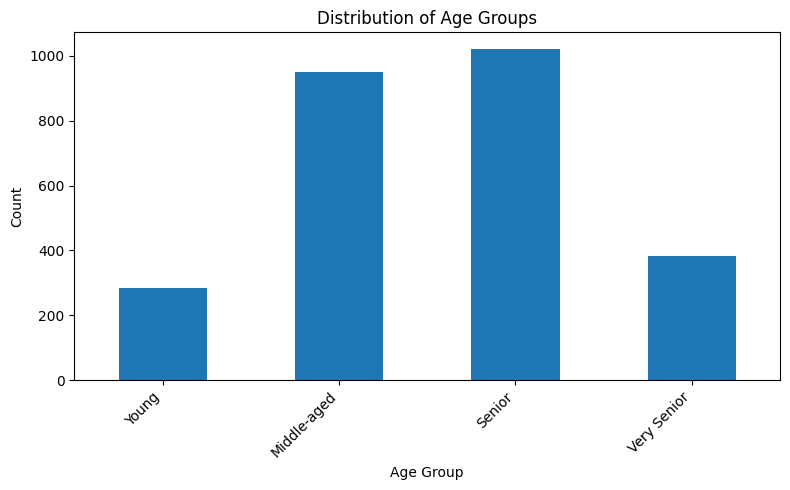

In [ ]:
plt.figure(figsize=(8, 5))
df_association['age_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### GDP_Country

The **gdp_country** variable represents the Gross Domestic Product of the country associated with each billionaire and provides important information about the economic context in which individuals accumulate wealth. Since GDP values vary significantly between countries and span several orders of magnitude, keeping this attribute as a continuous variable may make it difficult to identify meaningful patterns in association rule mining.

To address this issue, the variable was discretized using **quantile discretization (quartiles)**. This method divides the data into intervals that contain approximately the same number of observations. As a result, each category represents a balanced portion of the dataset, which helps prevent situations where some intervals contain very few instances while others contain the majority of the data.

Using quantile-based bins also allows the model to capture relationships between **different levels of national economic development** and other attributes in the dataset, such as industries, wealth sources, or self-made status. The resulting categories — **Low GDP, Medium GDP, High GDP, and Very High GDP** — provide an interpretable representation of the economic environment while maintaining balanced data distribution across groups. This improves the effectiveness of association rule mining by increasing the likelihood of discovering meaningful and statistically significant patterns.

In [ ]:
bins_gdp = df_association['gdp_country'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
labels_gdp = ['Low GDP', 'Medium GDP', 'High GDP', 'Very High GDP']

# Determine the actual number of bins qcut will create
_, actual_bin_edges = pd.qcut(df_association['gdp_country'], q=4, duplicates='drop', retbins=True)
num_actual_bins = len(actual_bin_edges) - 1

# Adjust labels to match the actual number of bins
adjusted_labels_gdp = labels_gdp[:num_actual_bins]

if num_actual_bins < len(labels_gdp):
    print(f"Warning: `pd.qcut` with `q=4` and `duplicates='drop'` produced only {num_actual_bins} bins for 'gdp_country' due to non-unique quantiles (e.g., 75th percentile and max GDP are identical).")
    print(f"Adjusting labels from {labels_gdp} to {adjusted_labels_gdp} to avoid ValueError.")

df_association['gdp_group'] = pd.qcut(
    df_association['gdp_country'],
    q=4,
    labels=adjusted_labels_gdp,
    duplicates='drop' # Handle cases where quantiles might not be unique
)

print("GDP_country variable discretized successfully. Displaying the first few rows with the new 'gdp_group' column:")
print(df_association[['gdp_country', 'gdp_group']].head())
df_association.drop(columns=['gdp_country'], inplace=True)

Adjusting labels from ['Low GDP', 'Medium GDP', 'High GDP', 'Very High GDP'] to ['Low GDP', 'Medium GDP', 'High GDP'] to avoid ValueError.
GDP_country variable discretized successfully. Displaying the first few rows with the new 'gdp_group' column:
    gdp_country   gdp_group
0  2.715518e+12  Medium GDP
1  2.142770e+13    High GDP
2  2.142770e+13    High GDP
3  2.142770e+13    High GDP
4  2.142770e+13    High GDP


The **gdp_country** variable was discretized using **quantile-based discretization (quartiles)** implemented through `pd.qcut`. This approach divides the continuous GDP values into groups containing approximately the same number of observations. The resulting categories — **Low GDP**, **Medium GDP**, **High GDP**, and **Very High GDP** — represent different levels of economic development among the countries associated with the individuals in the dataset.

This method was selected because GDP values are typically **highly skewed and vary greatly across countries**. Using equal-width intervals could produce bins with very uneven distributions, where most observations fall into a small number of ranges while others contain very few data points. Quantile discretization mitigates this issue by ensuring a **balanced distribution of observations across categories**, which improves the quality and reliability of patterns discovered during association rule mining.

The implementation also includes the parameter `duplicates='drop'` to handle situations where some quantile boundaries are identical due to repeated values in the dataset. In such cases, `pd.qcut` may generate fewer bins than initially requested. To avoid inconsistencies or errors, the number of labels is dynamically adjusted to match the actual number of bins created. This ensures that the discretization process remains robust while preserving the interpretability of the resulting GDP categories.

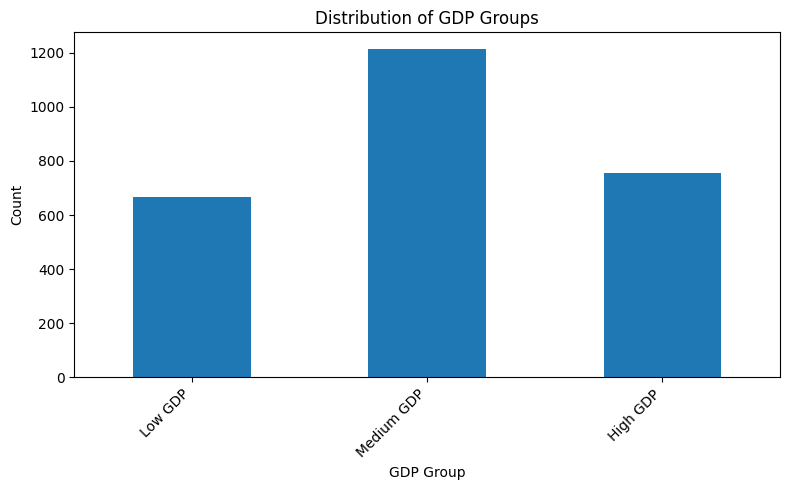

In [ ]:
plt.figure(figsize=(8, 5))
df_association['gdp_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of GDP Groups')
plt.xlabel('GDP Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Life_Expectancy_Country

The **life_expectancy_country** variable represents the average life expectancy of the population in the country associated with each billionaire. This variable reflects important aspects of a country's **social development, healthcare quality, and overall living conditions**, which may influence the economic and institutional environment where wealth is generated.

Since **association rule mining algorithms require categorical variables**, this continuous attribute must be discretized in order to be included in the analysis. By transforming life expectancy into categorical ranges, it becomes possible to identify patterns that relate different levels of national well-being with other attributes in the dataset, such as industries, sources of wealth, or whether the wealth is self-made.

Discretizing this variable also improves interpretability. Instead of analyzing small numerical differences in life expectancy values, the data can be grouped into broader categories representing **different levels of societal development** (for example, lower, medium, and higher life expectancy). This allows the resulting association rules to be easier to interpret and more meaningful in the context of socioeconomic analysis.

Furthermore, categorizing life expectancy helps reduce the effect of minor numerical variations between countries, allowing the model to focus on **structural differences between groups of countries** rather than isolated values. As a result, discretization facilitates the discovery of clearer and more generalizable patterns in the data mining process.

In [ ]:
bins_le = [0, 75, 78, 81, float('inf')]
labels_le = ['Low', 'Medium', 'High', 'Very High']

df_association['life_expectancy_group'] = pd.cut(
    df_association['life_expectancy_country'],
    bins=bins_le,
    labels=labels_le,
    right=True # This means that a value of 75 falls into 'Low', 78 into 'Medium', etc.
)

print("Life_expectancy_country variable discretized successfully. Displaying the first few rows with the new 'life_expectancy_group' column:")
print(df_association[['life_expectancy_country', 'life_expectancy_group']].head())
df_association.drop(columns=['life_expectancy_country'], inplace=True)

Life_expectancy_country variable discretized successfully. Displaying the first few rows with the new 'life_expectancy_group' column:
   life_expectancy_country life_expectancy_group
0                     82.5             Very High
1                     78.5                  High
2                     78.5                  High
3                     78.5                  High
4                     78.5                  High


For this variable, **equal-width binning** (or alternatively quartile-based discretization) was selected. This method divides the range of life expectancy values into intervals that represent meaningful differences in national development and living conditions. Because the range of life expectancy values in the dataset is relatively narrow compared to other economic indicators, equal-width bins can produce clear and interpretable categories.

The resulting intervals — **Low (<75)**, **Medium (75–78)**, **High (78–81)**, and **Very High (>81)** — represent different levels of population health and social development across countries. These categories allow the model to identify potential relationships between the **quality of life in a country** and other attributes in the dataset, such as the industries of billionaires, their sources of wealth, or whether their wealth is self-made.

By transforming the continuous values into interpretable categories, this discretization approach improves the clarity of the patterns discovered during the data mining process and facilitates the interpretation of the resulting association rules.

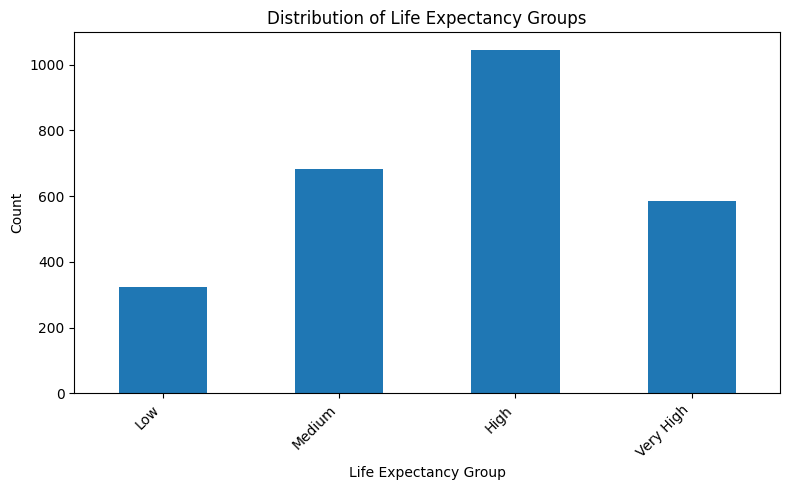

In [ ]:
plt.figure(figsize=(8, 5))
df_association['life_expectancy_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Life Expectancy Groups')
plt.xlabel('Life Expectancy Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Gross_Tertiary_Education_Enrollment

The **gross\_tertiary\_education\_enrollment** variable represents the percentage of the population enrolled in tertiary education within a country. This indicator reflects the **level of access to higher education and the development of human capital**, which are important factors influencing innovation, entrepreneurship, and economic productivity.

Since association rule mining algorithms require **categorical variables**, this continuous attribute must be discretized before it can be used in the analysis. Converting the numerical enrollment rates into categorical ranges allows the model to identify patterns that relate different levels of educational development with other attributes in the dataset, such as industries, sources of wealth, or the prevalence of self-made billionaires.

Discretizing this variable also improves interpretability by grouping countries into broader categories representing **different levels of higher education access** (for example, low, medium, high, or very high enrollment). Instead of focusing on small numerical differences between percentages, the analysis can focus on structural differences between countries with varying levels of tertiary education participation.

As a result, discretization facilitates the discovery of clearer and more meaningful patterns in the data mining process while maintaining a more interpretable representation of the educational environment associated with each observation.

In [ ]:
labels_gtee = ['Low education enrollment', 'Medium', 'High', 'Very high']

# Using q=4 for quartiles (equal-frequency)
# duplicates='drop' is used to handle cases where quantile boundaries might not be unique
_, actual_bin_edges_gtee = pd.qcut(df_association['gross_tertiary_education_enrollment'], q=4, duplicates='drop', retbins=True)
num_actual_bins_gtee = len(actual_bin_edges_gtee) - 1

adjusted_labels_gtee = labels_gtee[:num_actual_bins_gtee]

if num_actual_bins_gtee < len(labels_gtee):
    print(f"Warning: `pd.qcut` for 'gross_tertiary_education_enrollment' produced only {num_actual_bins_gtee} bins. Adjusting labels.")

df_association['tertiary_education_group'] = pd.qcut(
    df_association['gross_tertiary_education_enrollment'],
    q=4,
    labels=adjusted_labels_gtee,
    duplicates='drop'
)

print("Gross_tertiary_education_enrollment variable discretized successfully. Displaying the first few rows with the new 'tertiary_education_group' column:")
print(df_association[['gross_tertiary_education_enrollment', 'tertiary_education_group']].head())
df_association.drop(columns=['gross_tertiary_education_enrollment'], inplace=True)

Gross_tertiary_education_enrollment variable discretized successfully. Displaying the first few rows with the new 'tertiary_education_group' column:
   gross_tertiary_education_enrollment tertiary_education_group
0                                 65.6                   Medium
1                                 88.2                     High
2                                 88.2                     High
3                                 88.2                     High
4                                 88.2                     High


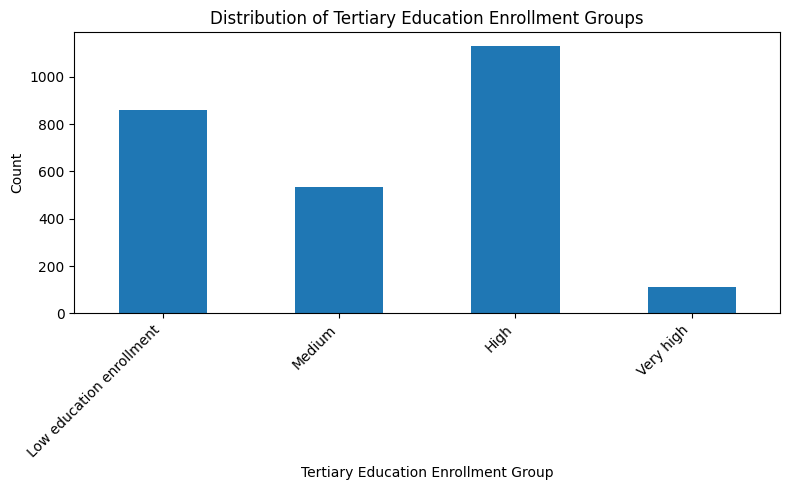

In [ ]:
plt.figure(figsize=(8, 5))
df_association['tertiary_education_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Tertiary Education Enrollment Groups')
plt.xlabel('Tertiary Education Enrollment Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Population_Country

The **population_country** variable represents the total population of the country associated with each observation. This variable can provide relevant contextual information, since the size of a country's population may influence the **distribution of economic opportunities, market size, and the concentration of wealth**.

However, population values vary drastically between countries and typically follow a **highly skewed distribution**, where a small number of countries have extremely large populations while many others have relatively small populations. Because of this skewness, directly applying discretization methods on the raw values could produce unbalanced intervals.

To address this issue, a **logarithmic transformation** is first applied to reduce the skewness of the distribution. After this transformation, **quantile-based discretization** is used to divide the data into groups containing approximately the same number of observations. This approach ensures that the categories are balanced and that the resulting groups are more suitable for association rule mining.

The resulting categories are:

| Population Range | Category |
|---|---|
| Lowest quantile | Small population |
| Second quantile | Medium population |
| Third quantile | Large population |
| Highest quantile | Very large population |

Using **four groups** provides a good balance between **granularity and interpretability**. With fewer groups, important differences between countries could be lost, while too many groups would fragment the data and reduce the support of potential association rules. Dividing the population into four categories allows the model to capture meaningful differences in country size while maintaining sufficiently large groups for reliable pattern discovery.

In [ ]:
# Apply logarithmic transformation
df_association['log_population_country'] = np.log10(df_association['population_country'])

labels_pop = ['Small population', 'Medium population', 'Large population', 'Very large population']

# Discretize using quantile bins on the log-transformed data
df_association['population_group'] = pd.qcut(
    df_association['log_population_country'],
    q=4,
    labels=labels_pop,
    duplicates='drop'
)

print("Population_country variable discretized successfully. Displaying the first few rows with the new 'population_group' column:")
print(df_association[['population_country', 'log_population_country', 'population_group']].head())
df_association.drop(columns=['log_population_country', 'population_country'], inplace=True)

Population_country variable discretized successfully. Displaying the first few rows with the new 'population_group' column:
   population_country  log_population_country   population_group
0          67059887.0                7.826463   Small population
1         328239523.0                8.516191  Medium population
2         328239523.0                8.516191  Medium population
3         328239523.0                8.516191  Medium population
4         328239523.0                8.516191  Medium population


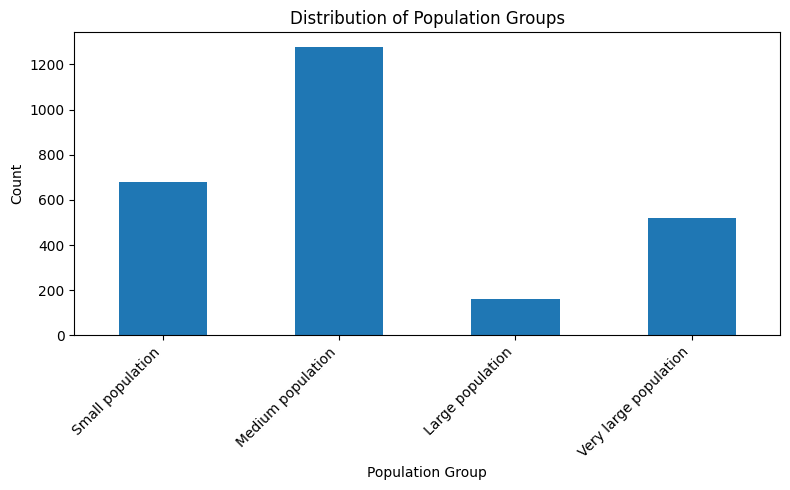

In [ ]:
plt.figure(figsize=(8, 5))
df_association['population_group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Population Groups')
plt.xlabel('Population Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Binarization of Variables**

In [ ]:
df_association.columns

Index(['finalWorth', 'category', 'personName', 'country', 'city', 'source',
       'industries', 'countryOfCitizenship', 'selfMade', 'status', 'gender',
       'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'age_group', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group',
       'population_group'],
      dtype='object')

In the context of association rule mining, it is necessary to transform the dataset into a format that can be effectively processed by the selected algorithms. Most association rule mining techniques, such as Apriori, operate on **transactional data**, where each observation is represented as a set of binary attributes indicating the presence or absence of specific items. For this reason, a binarization step is required as part of the data preprocessing phase.

Binarization consists of converting categorical and discretized variables into a set of binary features, where each possible category becomes an independent attribute. This transformation allows the model to treat each attribute-value pair as an item, facilitating the identification of frequent patterns and relationships within the data. Furthermore, this representation improves the interpretability of the results, as the generated rules clearly express associations between specific conditions.

The following section describes the variables selected for binarization and the approach used to transform them into a suitable format for association rule mining.

**Variables Suitable for Binarization**

The following variables are good candidates for binarization, as they are **categorical or discretized** and can naturally be represented as binary features:

- **category**
- **country**
- **city**
- **source**
- **industries**
- **countryOfCitizenship**
- **status**
- **gender**
- **title**
- **associated_companies** (if treated as categorical or multi-label)
- **age_group**
- **gdp_group**
- **life_expectancy_group**
- **tertiary_education_group**
- **population_group**

---

**Variables Not Suitable for Binarization**

The following variables should not be binarized:

- **personName** → Identifier (high cardinality, no analytical value)
- **birthDate** → Temporal/continuous information
- **date** → Contextual timestamp, not useful for association rules
- **birthYear** → Redundant with age/grouped age
- **finalWorth** → Continuous (should be discretized first if used)
- **cpi_country**, **cpi_change_country** → Continuous and low interpretability
- **gross_primary_education_enrollment_country** → Low variability
- **tax_revenue_country_country** → Potential redundancy
- **number_of_companies** → Continuous (should be discretized first if needed)

In [ ]:
def one_hot_encode_column(df, column_name):
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' isn't present in the dataframe")
        return df

    one_hot_encoded = pd.get_dummies(df[column_name], prefix=column_name)
    df_encoded = pd.concat([df.drop(columns=[column_name]), one_hot_encoded], axis=1)
    return df_encoded

In [ ]:
def ordinal_encode_column(df, column_name, categories):
    if column_name not in df.columns:
        print(f"Error: La columna '{column_name}' no se encuentra en el DataFrame.")
        return df

    df[column_name] = pd.Categorical(df[column_name], categories=categories, ordered=True)
    df[column_name] = df[column_name].cat.codes

    return df

#### Category

In [ ]:
print(df_association['category'].nunique())

18


18 Categories for 2640 rows is a good signal of this category can be binarized succesfully and will be useful for the data mining process.

In [ ]:
print(df_association['category'].unique())

['Fashion & Retail' 'Automotive' 'Technology' 'Finance & Investments'
 'Telecom' 'Diversified' 'Food & Beverage' 'Media & Entertainment'
 'Logistics' 'Gambling & Casinos' 'Manufacturing' 'Real Estate'
 'Metals & Mining' 'Energy' 'Healthcare' 'Sports'
 'Construction & Engineering' 'Service']


In [ ]:
df_association = one_hot_encode_column(df_association, 'category')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'source', 'industries',
       'countryOfCitizenship', 'selfMade', 'status', 'gender', 'birthDate',
       'title', 'date', 'birthYear', 'cpi_country', 'cpi_change_country',
       'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'age_group', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group', 'population_group',
       'category_Automotive', 'category_Construction & Engineering',
       'category_Diversified', 'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Techno

#### Country

In [ ]:
print(df_association['country'].nunique())

79


In [ ]:
print(df_association['country'].unique())

['France' 'United States' 'Mexico' 'India' 'Spain' 'China' 'Canada'
 'Germany' 'Switzerland' 'Belgium' 'Hong Kong' 'Austria' 'Japan'
 'United Kingdom' 'Australia' 'Indonesia' 'United Arab Emirates' 'Russia'
 'Chile' 'Monaco' 'Czech Republic' 'Sweden' 'Thailand' 'Uzbekistan'
 'Singapore' 'Nigeria' 'Israel' 'Italy' 'South Africa' 'Brazil' 'Malaysia'
 'South Korea' 'New Zealand' 'Philippines' 'Taiwan' 'Norway' 'Egypt'
 'Denmark' 'Eswatini (Swaziland)' 'Colombia' 'Netherlands' 'Poland'
 'Bahamas' 'Ukraine' 'Cayman Islands' 'Greece' 'Turkey' 'Argentina'
 'Georgia' 'Portugal' 'Kazakhstan' 'Algeria' 'Vietnam' 'Latvia' 'Finland'
 'Bermuda' 'Luxembourg' 'British Virgin Islands' 'Cambodia' 'Lebanon'
 'Oman' 'Ireland' 'Cyprus' 'Guernsey' 'Liechtenstein'
 'Turks and Caicos Islands' 'Romania' 'Qatar' 'Uruguay' 'Nepal' 'Slovakia'
 'Morocco' 'Hungary' 'Tanzania' 'Bahrain' 'Peru' 'Andorra' 'Armenia'
 'Panama']


he **country** variable contains a relatively high number of unique categories (more than 70 different values), which indicates a **high cardinality** attribute. While country information is potentially meaningful, directly binarizing this variable using one-hot encoding would generate a large number of binary features, many of which would correspond to countries with very few observations.

This situation can negatively impact the association rule mining process. Specifically, categories with low frequency will produce items with **very low support**, making it unlikely for them to appear in frequent itemsets or meaningful rules. Additionally, a large number of sparse binary columns increases the dimensionality of the dataset, which can reduce the efficiency of algorithms such as Apriori and lead to less interpretable results.

Therefore, directly binarizing the **country** variable is not recommended. Instead, it is more appropriate to **group countries into broader categories**, such as regions (e.g., Europe, Asia, Americas) or economic levels (e.g., developed vs. developing countries). This approach reduces cardinality, increases the support of each category, and improves the ability of the model to discover meaningful and generalizable patterns.

In conclusion, while the **country** variable contains valuable contextual information, it should not be binarized in its original form. A prior aggregation step is necessary to make it suitable for association rule mining.

#### City

In [ ]:
print(df_association['city'].nunique())

742


The **city** variable contains a very high number of unique values (742), which makes it a **high-cardinality attribute**. This means that most cities appear only a few times in the dataset, and in many cases, they may even be unique to a single observation.

Binarizing this variable would result in a large number of binary features, most of which would have **extremely low support**. In the context of association rule mining, this is problematic because items with very low frequency are unlikely to be included in frequent itemsets, and therefore will not contribute to meaningful rule generation. Additionally, this would significantly increase the dimensionality of the dataset, leading to a sparse representation that negatively affects both computational efficiency and interpretability.

Furthermore, city-level information is often **too specific** to reveal generalizable patterns. While it may be useful for descriptive analysis, it does not typically provide strong insights when searching for broader relationships between variables such as industry, wealth source, or socioeconomic context.

For these reasons, the **city** variable is not a suitable candidate for binarization.

#### Source

In [ ]:
print(df_association['source'].nunique())

12


In [ ]:
print(df_association['source'].unique())

['Retail and Consumer Goods' 'Technology' 'Finance and Investments'
 'Healthcare and Pharmaceuticals' 'Other' 'Real Estate and Construction'
 'Food and Agriculture' 'Energy and Utilities'
 'Manufacturing and Industrial' 'Mining and Materials'
 'Transportation and Logistics' 'Media and Entertainment']


The **source** variable contains a limited and well-defined set of categories (12 values), each representing a broad and meaningful classification of the origin of wealth. This indicates that the variable has **low cardinality**, which is desirable for binarization in the context of association rule mining.

Additionally, the categories are already **standardized and aggregated into high-level sectors**, which reduces sparsity and ensures that each category is likely to have a sufficient number of observations. This increases the probability that the resulting binary features will meet the minimum support thresholds required to generate meaningful association rules.

Furthermore, each category represents a **semantically distinct and interpretable concept**, allowing the resulting binary attributes to clearly express the presence or absence of a specific source of wealth. This enhances both the interpretability and usefulness of the patterns discovered during the data mining process.

Therefore, the **source** variable is well-suited for binarization, as it satisfies the key criteria of low cardinality, sufficient support, and high semantic relevance.

In [ ]:
df_association = one_hot_encode_column(df_association, 'source')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'industries',
       'countryOfCitizenship', 'selfMade', 'status', 'gender', 'birthDate',
       'title', 'date', 'birthYear', 'cpi_country', 'cpi_change_country',
       'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'age_group', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group', 'population_group',
       'category_Automotive', 'category_Construction & Engineering',
       'category_Diversified', 'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'ca

#### CountryOfCitizenship

In [ ]:
print(df_association['countryOfCitizenship'].nunique())

77


In [ ]:
print(df_association['countryOfCitizenship'].unique())

['France' 'United States' 'Mexico' 'India' 'Spain' 'China' 'Canada'
 'Germany' 'Italy' 'Hong Kong' 'Austria' 'Japan' 'Switzerland' 'Australia'
 'Indonesia' 'Russia' 'Chile' 'United Kingdom' 'Israel' 'Brazil'
 'Czech Republic' 'Singapore' 'Sweden' 'Thailand' 'Netherlands' 'Nigeria'
 'Cyprus' 'Malaysia' 'United Arab Emirates' 'South Africa' 'New Zealand'
 'Philippines' 'Monaco' 'Belgium' 'South Korea' 'Taiwan' 'Norway' 'Egypt'
 'Denmark' 'Ireland' 'Eswatini (Swaziland)' 'Colombia' 'Poland' 'Ukraine'
 'Greece' 'Turkey' 'Argentina' 'Georgia' 'Portugal' 'Kazakhstan' 'Algeria'
 'Venezuela' 'Vietnam' 'Finland' 'Belize' 'Lebanon' 'Oman' 'Iceland'
 'Guernsey' 'Liechtenstein' 'Bulgaria' 'Romania' 'Zimbabwe' 'Qatar'
 'Nepal' 'Slovakia' 'Morocco' 'Hungary' 'Tanzania' 'Peru' 'Barbados'
 'Macau' 'Estonia' 'St. Kitts and Nevis' 'Armenia' 'Bangladesh' 'Panama']


The **countryOfCitizenship** variable contains a large number of distinct categories (more than 70 values), which indicates a **high-cardinality attribute**. In the context of association rule mining, each category would be transformed into an individual item, significantly increasing the number of possible itemsets.

This high number of categories leads to a **sparse representation**, where many of the resulting binary features correspond to values that appear only a few times in the dataset. As a consequence, these items would have very low support and would rarely participate in frequent itemsets, limiting their contribution to the discovery of meaningful association rules. Additionally, the increase in dimensionality negatively impacts the efficiency of the mining process, as the number of candidate itemsets grows exponentially.

Furthermore, the granularity of this variable is very specific, representing individual countries rather than broader groupings. While it contains relevant contextual information, its detailed nature reduces its effectiveness for identifying generalizable patterns across the dataset.

Therefore, although the variable is categorical, its high cardinality and resulting sparsity make it **unsuitable for direct binarization** in the association rule mining process.

#### Industries

In [ ]:
print(df_association['industries'].nunique())

10


In [ ]:
print(df_association['industries'].unique())

['Consumer Discretionary' 'Technology & Telecommunications'
 'Financials & Investments' 'Media, Entertainment & Leisure' 'Other'
 'Consumer Staples' nan 'Industrials & Manufacturing'
 'Real Estate & Construction' 'Energy & Natural Resources' 'Healthcare']


The **industries** variable contains a small and well-defined set of categories (approximately 10–11 values, including a missing value), which indicates **low cardinality**. This characteristic makes it suitable for binarization, as the number of resulting binary features will remain manageable and will not introduce excessive sparsity into the dataset.

In addition, the categories represent **broad industry sectors**, which ensures that each value is likely to appear in a sufficient number of observations. This increases the likelihood that the corresponding binary attributes will meet the minimum support thresholds required in association rule mining, allowing them to participate in meaningful and frequent itemsets.

The variable also has strong **semantic relevance**, as it directly describes the sector in which each individual operates. This makes it highly valuable for identifying patterns related to the origin of wealth, since different industries may be associated with different characteristics such as self-made status, economic context, or demographic factors.

Therefore, due to its low cardinality, sufficient support across categories, and clear interpretability, the **industries** variable is well-suited for binarization.

In [ ]:
df_association = one_hot_encode_column(df_association, 'industries')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'countryOfCitizenship',
       'selfMade', 'status', 'gender', 'birthDate', 'title', 'date',
       'birthYear', 'cpi_country', 'cpi_change_country',
       'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'age_group', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group', 'population_group',
       'category_Automotive', 'category_Construction & Engineering',
       'category_Diversified', 'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'category_Telecom

#### Status

In [ ]:
print(df_association['status'].nunique())

6


In [ ]:
print(df_association['status'].unique())

['U' 'D' 'N' 'Split Family Fortune' 'E' 'R']


The **status** variable contains a small number of distinct categories (6 values), which indicates **low cardinality**. This makes it suitable for binarization, as the transformation will result in a limited number of binary features without introducing significant sparsity into the dataset.

Additionally, the categories represent **meaningful distinctions in the origin or nature of wealth**, such as self-made, inherited, or other classifications. These differences are semantically relevant for the analysis, as they can help identify patterns related to how wealth is acquired and how it relates to other variables in the dataset.

Since each category is expected to appear with sufficient frequency, the resulting binary attributes will have adequate support to be considered in the generation of association rules. Furthermore, the limited number of categories ensures that the dimensionality of the dataset remains manageable after binarization.

Therefore, due to its low cardinality, sufficient support, and clear semantic meaning, the **status** variable is appropriate for binarization in the context of association rule mining.

In [ ]:
df_association = one_hot_encode_column(df_association, 'status')

#### Gender

In [ ]:
print(df_association['gender'].nunique())

2


In [ ]:
print(df_association['gender'].unique())

['M' 'F']


The **gender** variable contains only two distinct categories (*M* and *F*), which indicates **very low cardinality**. This makes it an ideal candidate for binarization, as it will result in a minimal number of binary features without increasing the dimensionality of the dataset.

Additionally, both categories are expected to have sufficient representation in the dataset, ensuring that the resulting binary attributes will have adequate support for association rule mining. This allows the variable to effectively participate in the generation of frequent itemsets and meaningful rules.

From a semantic perspective, the **gender** variable represents a clear and interpretable characteristic of individuals, which can be useful for identifying patterns when combined with other attributes such as industry, source of wealth, or self-made status.

Therefore, due to its very low cardinality, balanced representation, and interpretability, the **gender** variable is highly suitable for binarization.

In [ ]:
df_association = one_hot_encode_column(df_association, 'gender')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'countryOfCitizenship',
       'selfMade', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'age_group', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group', 'population_group',
       'category_Automotive', 'category_Construction & Engineering',
       'category_Diversified', 'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'category_Telecom',
       'source_Energy an

#### Title

In [ ]:
print(df_association['title'].nunique())

210


In [ ]:
print(df_association['title'].unique())

['Chairman & CEO' 'CEO, Founder & Engineer' 'Executive Chair & Founder'
 'Chairman, CTO & Cofounder' 'Cofounder & Co-chair' 'Founder & Owner'
 'Honorary Chairman & Founder' 'Chairman & Managing Director' 'Owner'
 'Vice Chair & President' 'Cofounder & Board Member'
 'Founder & Former Chairman' 'Founder & Chairman'
 'Founder, Chairman & CEO' 'Chairman & Co-CEO' 'Board Member & Owner'
 'Former Chairman' 'Chairman' 'Chairman & Founder'
 'Cofounder & Chairman Emeritus' 'Founder' 'Founder & Entrepreneur'
 'Principal Shareholder & Investor' 'Executive Chairman'
 'Senior Advisor & Former Chairman' 'Chairman and CEO' 'Founder & CEO'
 'Founder & Entrepreneur & Music' 'Founder & Entrepreneur & Trading'
 'CEO & Internet' 'Founder & Entrepreneur & Steel' 'CEO' 'CEO & President'
 'Chairman Emeritus' 'Founder & Entrepreneur & Oil'
 'Founder & Co-Chief Investment Officer' 'Founder & Entrepreneur & Mining'
 'Founder & Entrepreneur & Pig' 'Founder & Entrepreneur & Batteries'
 'President and Founder' 'Fo


The **title** variable initially appears to have a very high number of unique values, which suggests high cardinality. However, this is misleading, as each value is not a single category but rather a **combination of multiple roles or titles** associated with an individual (e.g., *Founder & CEO*, *Chairman & Owner*, etc.).

This means that the apparent variability in the variable is caused by the different **combinations of recurring keywords**, rather than truly distinct categories. In practice, many of these values share common components such as *Founder*, *CEO*, *Chairman*, or *Investor*, which are repeated across multiple entries but combined in different ways.

Therefore, the variable does not represent a large number of fundamentally different categories, but rather a **compositional structure** built from a smaller set of core titles. To properly analyze this variable, it is necessary to decompose each entry into its individual components, allowing the identification of the actual number of unique titles and their frequency within the dataset.

In [ ]:
# Convertir a minúsculas y manejar nulos
titles = df_association['title'].dropna().str.lower()

# Reemplazar separadores por uno común
titles_clean = titles.str.replace(r'&|,| and ', '|', regex=True)

# Separar en listas
titles_split = titles_clean.str.split('|')

# Aplanar lista
all_titles = [t.strip() for sublist in titles_split for t in sublist if t.strip() != '']

# Palabras que no aportan significado
stopwords = ['and', '', 'of', 'the']

all_titles = [t for t in all_titles if t not in stopwords]

unique_titles = set(all_titles)

print("Número de títulos únicos reales:", len(unique_titles))
print(unique_titles)

title_counts = Counter(all_titles)

# Top 20 títulos más comunes
print(title_counts.most_common(20))

Número de títulos únicos reales: 149
{'snacks', 'infrastructure', 'steel', 'car', 'sap', 'insurance', 'gas', 'homebuilding', 'chief executive officer', 'banking', 'building', 'cto', 'hotels', 'aluminum', 'executive vice president', 'pet', 'principal shareholder', 'movies', 'casinos', 'it consulting', 'ceo', 'scaffolding', 'search', 'entertainment', 'textile', 'space', 'tourism', 'batteries', 'toys', 'media', 'founder chairman', 'mining', 'cosmetics', 'co-executive chairman', 'senior advisor', 'banks', 'chief technology officer', '3d', 'sports', 'equipment', 'honorary chairman', 'board member', 'metals', 'engineering', 'airports', 'automobiles', 'engineer', 'gym', 'oil', 'former chairman', 'facebook', 'investor', 'groupon', 'genentech', 'logistics', 'alcohol', 'blockchain', 'staffing', 'nfl', 'new', 'chemicals', 'chief product officer', 'shapewear', 'pig', 'manufacturing', 'los', 'copper', 'tires', 'dole', 'cap', 'director', 'shipping', 'refinery', 'pipes', 'tv network', 'lp', 'commodit

After decomposing the **title** variable into its individual components, a total of **149 unique titles** were identified. This confirms that the variable is not inherently composed of entirely unique categories, but rather a combination of recurring terms that appear across different observations.

However, despite this decomposition, the number of unique titles remains relatively high. Additionally, the extracted values include a mixture of **relevant roles** (e.g., *CEO*, *Founder*, *Chairman*) and **context-specific or noisy terms** (e.g., company names, industries, or incomplete tokens such as *facebook*, *oil*, *pipes*, *los*, *inc.*). This indicates that the variable contains not only professional roles but also additional contextual information embedded within the same field.

As a result, even after normalization and decomposition, the variable still presents **high cardinality and semantic inconsistency**, which can negatively affect the association rule mining process. Many of these titles are expected to have low frequency, leading to sparse binary representations and low-support items that are unlikely to contribute to meaningful patterns.

Therefore, while the decomposition process reveals the internal structure of the variable, the **title** attribute in its current form remains complex and heterogeneous, requiring further filtering or abstraction before it can be effectively used in the analysis.

#### Associated_Companies

In [ ]:
print(df_association['associated_companies'].nunique())

1099


The **associated_companies** variable contains a very high number of unique values (1099), which indicates **extremely high cardinality**. This suggests that most observations are linked to distinct or rarely repeated company names.

In the context of association rule mining, binarizing this variable would generate a very large number of binary features, most of which would have **very low support**. As a result, these features would rarely appear in frequent itemsets and would contribute minimally to the discovery of meaningful patterns. Additionally, the resulting dataset would become highly sparse, increasing computational complexity and reducing the efficiency of the mining process.

Furthermore, company names tend to function as **identifiers rather than generalizable attributes**, meaning they do not easily contribute to discovering broader relationships across the dataset.

Therefore, due to its extremely high cardinality, sparsity, and limited generalization capability, the **associated_companies** variable is not suitable for binarization.

#### Age_group

In [ ]:
print(df_association['age_group'].nunique())

4


In [ ]:
print(df_association['age_group'].unique())

['Senior', 'Middle-aged', 'Very Senior', 'Young']
Categories (4, object): ['Young' < 'Middle-aged' < 'Senior' < 'Very Senior']


The **age_group** variable is composed of four categories (*Young*, *Middle-aged*, *Senior*, and *Very Senior*), which reflects a **compact and well-structured categorical attribute**. Its limited number of values makes it suitable for transformation without introducing unnecessary complexity into the dataset.

Each category represents a clearly defined segment, allowing the data to be interpreted in terms of meaningful age ranges rather than raw numerical values. This type of representation is particularly useful in pattern discovery, as it enables the identification of relationships between different life stages and other attributes in the dataset.

Moreover, the reduced number of categories ensures that each group maintains a sufficient number of observations, avoiding sparsity issues and supporting the generation of consistent patterns during the mining process.

For these reasons, the **age_group** variable can be effectively represented in a binary format while preserving both its interpretability and analytical value.

In [ ]:
df_association = one_hot_encode_column(df_association, 'age_group')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'countryOfCitizenship',
       'selfMade', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'gdp_group',
       'life_expectancy_group', 'tertiary_education_group', 'population_group',
       'category_Automotive', 'category_Construction & Engineering',
       'category_Diversified', 'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'category_Telecom',
       'source_Energy and Utilities',

#### GDP_group

In [ ]:
print(df_association['gdp_group'].nunique())

3


In [ ]:
print(df_association['gdp_group'].unique())

['Medium GDP', 'High GDP', 'Low GDP']
Categories (3, object): ['Low GDP' < 'Medium GDP' < 'High GDP']


The **gdp_group** variable contains three categories (*Low GDP*, *Medium GDP*, and *High GDP*), which indicates a **low-cardinality attribute**. This limited number of values makes it suitable for transformation without significantly increasing the dimensionality of the dataset.

Each category represents a distinct level of economic context, allowing the data to capture differences in the economic environment associated with each observation. These groupings simplify the original continuous variable while preserving its most relevant information, making it easier to identify patterns related to wealth distribution and country characteristics.

Additionally, having only three categories ensures that each group is likely to contain a sufficient number of observations, reducing the risk of sparsity and supporting the generation of consistent patterns during the mining process.

Given these characteristics, the **gdp_group** variable can be effectively represented in binary form, maintaining both interpretability and usefulness within the association rule mining framework.

In [ ]:
df_association = one_hot_encode_column(df_association, 'gdp_group')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'countryOfCitizenship',
       'selfMade', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies', 'life_expectancy_group',
       'tertiary_education_group', 'population_group', 'category_Automotive',
       'category_Construction & Engineering', 'category_Diversified',
       'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'category_Telecom',
       'source_Energy and Utilities', 'source_Fina

#### Life_expectancy_group

In [ ]:
print(df_association['life_expectancy_group'].nunique())

4


In [ ]:
print(df_association['life_expectancy_group'].unique())

['Very High', 'High', 'Low', 'Medium']
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']


The **life_expectancy_group** variable is composed of four ordered categories (*Low*, *Medium*, *High*, and *Very High*), representing different levels of life expectancy across countries. This structure reflects a **clear and compact categorization** of the original continuous variable.

Although the categories follow a natural order, each group represents a **distinct and interpretable level of socioeconomic conditions**, making the variable suitable for pattern discovery. The limited number of categories ensures that the data remains well-distributed across groups, reducing sparsity and allowing each category to contribute meaningfully to the analysis.

By representing these categories in binary form, each level of life expectancy can be treated as an independent attribute. This facilitates the identification of relationships between different country conditions and other variables in the dataset, such as wealth origin, industry, or demographic characteristics.

Given its structured categorization, sufficient support across groups, and clear interpretability, the **life_expectancy_group** variable is appropriate for binarization within the association rule mining process.

In [ ]:
df_association = one_hot_encode_column(df_association, 'life_expectancy_group')

In [ ]:
df_association.columns

Index(['finalWorth', 'personName', 'country', 'city', 'countryOfCitizenship',
       'selfMade', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gross_primary_education_enrollment_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'associated_companies', 'number_of_companies',
       'tertiary_education_group', 'population_group', 'category_Automotive',
       'category_Construction & Engineering', 'category_Diversified',
       'category_Energy', 'category_Fashion & Retail',
       'category_Finance & Investments', 'category_Food & Beverage',
       'category_Gambling & Casinos', 'category_Healthcare',
       'category_Logistics', 'category_Manufacturing',
       'category_Media & Entertainment', 'category_Metals & Mining',
       'category_Real Estate', 'category_Service', 'category_Sports',
       'category_Technology', 'category_Telecom',
       'source_Energy and Utilities', 'source_Finance and Investments',
   

#### Tertiary_Education_Group

In [ ]:
print(df_association['tertiary_education_group'].nunique())

4


In [ ]:
print(df_association['tertiary_education_group'].unique())

['Medium', 'High', 'Low education enrollment', 'Very high']
Categories (4, object): ['Low education enrollment' < 'Medium' < 'High' < 'Very high']


The **tertiary_education_group** variable consists of four categories (*Low education enrollment*, *Medium*, *High*, and *Very high*), which represent different levels of access to higher education across countries. This indicates a **low-cardinality and well-structured categorical variable**.

Each category captures a meaningful level of educational development, allowing the dataset to reflect differences in human capital and socioeconomic conditions. These distinctions are relevant for the analysis, as they may be associated with patterns related to wealth creation, industry distribution, or self-made status.

The relatively small number of categories ensures that each group contains a sufficient number of observations, avoiding sparsity issues and enabling consistent participation in frequent itemsets. Furthermore, the categories are easy to interpret, which enhances the clarity of any patterns discovered during the mining process.

Given these characteristics, the **tertiary_education_group** variable can be effectively transformed into a binary representation, preserving its interpretability and making it suitable for association rule mining.

In [ ]:
df_association = one_hot_encode_column(df_association, 'tertiary_education_group')

#### Population_Group

In [ ]:
print(df_association['population_group'].nunique())

4


In [ ]:
print(df_association['population_group'].unique())

['Small population', 'Medium population', 'Large population', 'Very large population']
Categories (4, object): ['Small population' < 'Medium population' < 'Large population' <
                         'Very large population']



The **population_group** variable divides countries into four levels based on their population size (*Small*, *Medium*, *Large*, and *Very large population*). This transformation condenses a highly skewed continuous variable into a **manageable number of representative categories**.

These groups capture meaningful differences in the scale of countries, which can influence economic dynamics and the distribution of wealth. By working with grouped values instead of raw population figures, the analysis focuses on **relative differences between countries** rather than absolute magnitudes.

The presence of only four categories keeps the variable simple while still preserving relevant distinctions. This also ensures that each category contains enough observations to be useful in pattern discovery, avoiding issues related to rare or underrepresented values.

In this context, representing the **population_group** variable in binary form allows each population level to be analyzed independently, facilitating the identification of relationships with other attributes in the dataset.

In [ ]:
df_association = one_hot_encode_column(df_association, 'population_group')

In [ ]:
industry_counts = (
    clean_dataset
    .groupby(['country', 'industries'])
    .size()
    .unstack(fill_value=0)
)

total_billionaires_country = industry_counts.sum(axis=1)

total_billionaires_country = industry_counts.sum(axis=1)
industry_share = industry_counts.div(total_billionaires_country, axis=0)
industry_share.columns = [f"share_{col}" for col in industry_share.columns]

dominant_industry = industry_counts.idxmax(axis=1)
dominant_industry = dominant_industry.rename("dominant_industry")

industry_concentration = (industry_share ** 2).sum(axis=1)
industry_concentration = industry_concentration.rename("industry_concentration")

industry_country_dataset = pd.concat(
    [industry_share],
    axis=1
).reset_index()


NameError: name 'clean_dataset' is not defined

In [ ]:
df_association.columns

In [ ]:
df_association.to_csv("dataset_association.csv", index=False)

## Level 3.2 - Dataset preparation for classification task

In [ ]:
clean_dataset = df.copy()

### Industry Shares

### Source Shares

In [ ]:

source_counts = (
    clean_dataset
    .groupby(['country', 'source'])
    .size()
    .unstack(fill_value=0)
)

source_share = source_counts.div(total_billionaires_country, axis=0)
source_share.columns = [f"share_source_{col}" for col in source_share.columns]

dominant_source = source_counts.idxmax(axis=1).rename("dominant_source")

source_share = source_counts.div(total_billionaires_country, axis=0)
source_share.columns = [f"share_source_{col}" for col in source_share.columns]

source_concentration = (source_share ** 2).sum(axis=1).rename("source_concentration")

source_country_dataset = pd.concat(
    [source_share, dominant_source, source_concentration],
    axis=1
).reset_index()



In [ ]:
classification_dataset = country_features.merge(
    industry_country_dataset,
    on="country",
    how="left"
)


classification_dataset = classification_dataset.merge(
    source_country_dataset,
    on="country",
    how="left"
)







In [ ]:
classification_dataset.shape

In [ ]:
classification_dataset.info()

### Normalizacion de variables

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns for normalization
numerical_cols_to_normalize = [
    'finalWorth', 'age', 'cpi_country', 'cpi_change_country', 'gdp_country',
    'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country',
    'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country',
    'population_country', 'number_of_companies'
]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the selected numerical columns
df[numerical_cols_to_normalize] = scaler.fit_transform(df[numerical_cols_to_normalize])

print("Data normalized successfully for selected numerical columns.")
print("\nFirst 5 rows of the DataFrame with normalized data:")
print(df[numerical_cols_to_normalize].head())

print("\nDescriptive statistics for normalized numerical columns:")
print(df[numerical_cols_to_normalize].describe())

In [ ]:
# Re-load the dataset to ensure a clean start, similar to wI5Efz4MGQSo
url = "https://raw.githubusercontent.com/mbarrerag/Billionard-dataset/refs/heads/main/Billionaires_dataset.csv"
df = pd.read_csv(url)

# --- Re-apply all cleaning and preprocessing steps to 'df' ---

# Remove Irrelevant Columns (from vBYSGyZ_vyF3, oqeuWlV70eFV, cf0aebbc, LD-4_5RoF8os)
df.drop(columns=['lastName', 'firstName', 'birthMonth', 'birthDay', 'rank', 'latitude_country', 'longitude_country'], inplace=True)

# Check Duplicates (from f11e8b65)
df.drop_duplicates(subset='personName', keep='first', inplace=True)

# Handling missing values
# Country (from NVi8xGPWtWtq)
# Step 1: Fill from countryOfCitizenship
df['country'] = df['country'].fillna(df['countryOfCitizenship'])
# Step 2: Build city -> country map from existing non-null data
city_country_map = (
    df[df['country'].notnull() & df['city'].notnull()]
    .groupby('city')['country']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
# Apply city -> country for still missing
def recover_country(row):
    if pd.notnull(row['country']):
        return row['country']
    if pd.notnull(row['city']) and row['city'] in city_country_map:
        return city_country_map[row['city']]
    if pd.notnull(row.get('state')) or pd.notnull(row.get('residenceStateRegion')):
        return 'United States'
    return 'Unknown'
df['country'] = df.apply(recover_country, axis=1)

# City (from k7LpcglfkpzF)
country_city_mode = (
    df[df['city'].notnull() & (df['city'] != 'Unknown')]
    .groupby('country')['city']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
known_billionaire_city = {
    'United States': 'New York', 'China': 'Beijing', 'Germany': 'Munich', 'India': 'Mumbai',
    'United Kingdom': 'London', 'France': 'Paris', 'Russia': 'Moscow', 'Switzerland': 'Zurich',
    'Italy': 'Milan', 'Hong Kong': 'Hong Kong', 'Canada': 'Toronto', 'Australia': 'Sydney',
    'Japan': 'Tokyo', 'Singapore': 'Singapore', 'Sweden': 'Stockholm', 'Brazil': 'Sao Paulo',
    'Mexico': 'Mexico City', 'Spain': 'Madrid', 'South Korea': 'Seoul', 'Indonesia': 'Jakarta',
    'United Arab Emirates': 'Dubai', 'Saudi Arabia': 'Riyadh', 'Netherlands': 'Amsterdam',
    'Taiwan': 'Taipei', 'Thailand': 'Bangkok', 'Turkey': 'Istanbul', 'Israel': 'Tel Aviv',
    'Philippines': 'Manila', 'Ireland': 'Dublin', 'Egypt': 'Cairo', 'Nigeria': 'Lagos',
    'Finland': 'Helsinki', 'Norway': 'Oslo', 'Denmark': 'Copenhagen', 'Austria': 'Vienna',
    'Belgium': 'Brussels', 'Chile': 'Santiago', 'Colombia': 'Bogota', 'Argentina': 'Buenos Aires',
    'South Africa': 'Johannesburg'
}
def recover_city(row):
    if pd.notnull(row['city']) and row['city'] != 'Unknown':
        return row['city']
    country = row['country']
    if country in country_city_mode:
        return country_city_mode[country]
    if country in known_billionaire_city:
        return known_billionaire_city[country]
    return 'Unknown'
df['city'] = df.apply(recover_city, axis=1)

# Age (from fee03f84)
df['birthDate'] = pd.to_datetime(df['birthDate'])
df['date'] = pd.to_datetime(df['date'])
df['age'] = (df['date'] - df['birthDate']).dt.days / 365.25
age_median_recalculated = df['age'].median()
df['age'].fillna(age_median_recalculated, inplace=True)

# Organization, State, ResidenceStateRegion (from N1CAebkD0qtx, BfY6J1Hv06qp, Mjj1AveB0-_P)
df.drop(columns=['organization', 'state', 'residenceStateRegion'], inplace=True)

# CPI Country (from KY3LkvFq96ng)
df['cpi_country'] = df.groupby('country')['cpi_country'].transform(lambda x: x.fillna(x.median()))
df['cpi_country'].fillna(df['cpi_country'].median(), inplace=True)

# CPI Change Country (from N0rZmix7-iQn)
df['cpi_change_country'] = df.groupby('country')['cpi_change_country'].transform(lambda x: x.fillna(x.median()))
df['cpi_change_country'].fillna(df['cpi_change_country'].median(), inplace=True)

# GDP Country (from eOy1jAdq_rgz)
df['gdp_country'] = df['gdp_country'].astype(str).str.replace('$', '').str.replace(',', '', regex=True).astype(float)
df['gdp_country'] = df.groupby('country')['gdp_country'].transform(lambda x: x.fillna(x.median()))
df['gdp_country'].fillna(df['gdp_country'].median(), inplace=True)

# Gross Tertiary Education Enrollment (from wlSqsybC_1Qg)
df['gross_tertiary_education_enrollment'] = df.groupby('country')['gross_tertiary_education_enrollment'].transform(lambda x: x.fillna(x.median()))
df['gross_tertiary_education_enrollment'].fillna(df['gross_tertiary_education_enrollment'].median(), inplace=True)

# Life Expectancy Country (from jDNywKML_6vS)
df['life_expectancy_country'] = df.groupby('country')['life_expectancy_country'].transform(lambda x: x.fillna(x.median()))
df['life_expectancy_country'].fillna(df['life_expectancy_country'].median(), inplace=True)

# Tax Revenue Country (from 0NQOnptdAA-C)
df['tax_revenue_country_country'] = df.groupby('country')['tax_revenue_country_country'].transform(lambda x: x.fillna(x.median()))
df['tax_revenue_country_country'].fillna(df['tax_revenue_country_country'].median(), inplace=True)

# Total Tax Rate Country (from 9tyRz0msADQc)
df['total_tax_rate_country'] = df.groupby('country')['total_tax_rate_country'].transform(lambda x: x.fillna(x.median()))
df['total_tax_rate_country'].fillna(df['total_tax_rate_country'].median(), inplace=True)

# Population Country (from Aj_3TkSDF1Iy)
df['population_country'] = df.groupby('country')['population_country'].transform(lambda x: x.fillna(x.median()))
df['population_country'].fillna(df['population_country'].median(), inplace=True)

# Gross Primary Education Enrollment (from QGCZ0oDvKjZ7)
df['gross_primary_education_enrollment_country'] = df.groupby('country')['gross_primary_education_enrollment_country'].transform(lambda x: x.fillna(x.median()))
global_median_primary_edu = df['gross_primary_education_enrollment_country'].median()
df['gross_primary_education_enrollment_country'].fillna(global_median_primary_edu, inplace=True)

# Standardization of Industries and Sources
# Industries (from 3a0bc1JkHSPz)
industry_macro_mapping = {
    'Technology': 'Technology & Telecommunications',
    'Telecom': 'Technology & Telecommunications',
    'Finance & Investments': 'Financials & Investments',
    'Fashion & Retail': 'Consumer Discretionary',
    'Automotive': 'Consumer Discretionary',
    'Sports': 'Consumer Discretionary',
    'Gambling & Casinos': 'Consumer Discretionary',
    'Food & Beverage': 'Consumer Staples',
    'Healthcare': 'Healthcare',
    'Real Estate': 'Real Estate & Construction',
    'Construction & Engineering': 'Real Estate & Construction',
    'Manufacturing': 'Industrials & Manufacturing',
    'Service': 'Industrials & Manufacturing',
    'Metals & Mining': 'Industrials & Manufacturing',
    'Energy': 'Energy & Natural Resources',
    'Media & Entertainment': 'Media, Entertainment & Leisure',
    'Diversified': 'Other'
}
df['industries'] = df['industries'].map(industry_macro_mapping)

# Sources (from aAdkJhOt9hd4)
macro_categories_mapping = {
    "Technology": [
        "software", "business software", "fintech", "cloud computing", "cybersecurity", "data analytics",
        "facebook", "google", "microsoft", "samsung", "amazon", "tiktok", "snapchat", "spotify", "whatsapp",
        "instagram", "twitter", "linkedin", "pinterest", "zoom video communications", "oracle", "intel",
        "dell technologies", "sap", "roku", "netflix", "apple", "ebay", "paypal", "ecommerce",
        "online retail", "internet search", "social media", "technology", "it provider", "information technology",
        "computer hardware", "data centers", "internet media", "internet", "online services", "online entertainment",
        "web hosting", "mapping software", "healthcare software", "e-commerce software", "payment software",
        "payments software", "messaging software", "security software", "software firm",
        "copy machines", "computer networking", "online payments", "online recruitment", "blockchain",
        "blockchain technology", "internet and software", "search engine", "online dating", "cloud storage service",
        "video streaming app", "messaging app", "email marketing", "stock photos", "data management",
        "it consulting", "it consulting, outsourcing", "computer services", "hardware", "hardware stores",
        "virtual reality", "3d printing", "online universities", "education technology", "online apparel retail",
        "computer games", "videogames", "gaming", "online games", "video games", "online gaming",
        "pachinko machines", "gambling software", "tech", "walmart", "alibaba", "uber", "wework", "yahoo", "netscape",
        "square", "groupon", "bloomberg lp", "tesla", "spacex", "disney", "sensors", "smartphone components",
        "smartphone screens", "touch screens", "sensor systems", "sensor technology", "microchip testing",
        "semiconductor devices", "semiconductor materials", "lithium-ion battery cap", "battery separators",
        "battery components", "solar wafers and modules", "solar panel materials", "photovoltaic equipment",
        "solar inverters", "power supply equipment", "power strips", "power strip", "heating and cooling equipment",
        "heating, cooling equipment", "kitchen appliances", "cooking appliances", "home appliances", "vacuums",
        "coffee makers", "hair dryers", "mattresses", "carpet", "flooring", "tiles", "glass", "plastics", "textiles",
        "polyester", "apparel", "readymade garments", "paper manufacturing", "pulp and paper", "paper & related products",
        "timberland", "lumber mills", "lumber", "furniture retailing", "furniture retail", "home furnishings",
        "electrical appliances", "consumer electronics", "lighting", "led lighting", "gym equipment", "fitness equipment",
        "toys", "lego", "plush toys", "train cars", "automotive brakes", "brakes", "tires", "diversified",
        "tyre manufacturing machinery", "tire", "motorcycles", "two wheelers", "electric scooters", "electric bikes",
        "scooters", "tractors", "construction equipment", "construction vehicles", "mining, machinery", "oilfield equipment",
        "aol", "flipkart" # Added from the Technology list
    ],
    "Finance and Investments": [
        "investments", "hedge funds", "private equity", "venture capital", "finance", "banking",
        "financial services", "insurance", "asset management", "money management", "mutual funds",
        "investment banking", "cryptocurrency", "hedge fund", "franklin templeton", "fidelity",
        "bloomberg lp", "quicken loans", "td ameritrade", "discount brokerage", "stock brokerage",
        "investing", "finance and investments", "finance services", "leveraged buyouts", "tech investments",
        "biotech investing", "biotech and investments", "finance, asset management", "banking, investments",
        "banking, credit cards", "trading, investments", "insurance, investments", "real estate, private equity",
        "oil, investments", "energy, investments", "software, investments", "retail, investments",
        "construction, investments", "fashion retail, investments", "banking, minerals", "oil, banking, telecom",
        "banking, tobacco", "consumer products, banking", "banking, insurance", "banking, shipping",
        "banking, real estate", "banking, oil", "banking, development", "finance, real estate",
        "finance, telecommunications", "finance, development", "financial technology", "financial information",
        "financial services, property", "commodities, investments", "telecom, investments", "investments, energy",
        "investments, art", "investments, energy drinks", "energy drinks,investments", "berkshire hathaway",
        "executive search", "groupon, investments", "facebook, investments", "netscape, investments",
        "twitter, square", "electronic trading", "stock exchange", "mortgage lender", "payroll services",
        "payroll processing", "payroll software", "accounting services", "payment processing",
        "mobile payments", "online payments", "payments, banking", "capital", "markets", "funds" # More general terms
    ],
    "Real Estate and Construction": [
        "real estate", "construction", "building materials", "hotels", "hotels, investments",
        "real estate, investments", "construction, investments", "retail, real estate", "shopping centers",
        "shopping malls", "homebuilding", "real estate development", "real estate management",
        "office real estate", "airports, real estate", "real estate, hotels", "real estate, airport",
        "real estate, construction", "construction, real estate", "real estate, media", "real estate, retail",
        "real estate, manufacturing", "real estate, electronics", "real estate, gambling", "real estate finance",
        "real estate services", "homebuilder", "real estate, diversified", "real estate, grains",
        "plush toys, real estate", "real estate, shipping", "real estate, coal", "real estate, oil",
        "casinos, real estate", "casinos, hotels", "casinos, property, energy", "real estate, private equity",
        "fertilizer, real estate", "palm oil, property", "palm oil, shipping, property", "hotels, diversified",
        "hotels, energy", "hotels, motels", "casinos/hotels", "alcohol, real estate", "oil, real estate",
        "oil, coal, real estate", "precious metals, real estate", "energy, real estate", "utilities, real estate",
        "logistics, real estate", "transport, engineering, real estate", "construction, pipes, banking",
        "construction equipment, media", "construction, mining machinery", "construction vehicles",
        "construction, pipes, chemicals", "construction, mining", "building, development",
        "engineering, construction", "home sales", "home improvement stores", "self storage", "storage facilities",
        "toll roads", "infrastructure", "infrastructure, commodities", "property", "nfl team" # Added from description
    ],
    "Manufacturing and Industrial": [
        "manufacturing", "machinery", "auto parts", "electronics", "electrical equipment", "steel",
        "chemicals", "petrochemicals", "cement", "industrial equipment", "machine tools", "elevators",
        "escalators", "tires", "automotive", "appliances", "furniture", "packaging", "paints",
        "adhesives", "cleaning products", "flavorings", "household chemicals", "specialty chemicals",
        "chemical products", "refinery, chemicals", "chemicals, spandex", "chemicals, logistics",
        "chemicals, investments", "textiles, petrochemicals", "textile, chemicals", "gas, chemicals",
        "energy, chemicals", "construction materials", "pipe manufacturing", "plastic pipes", "steel pipes",
        "steel tubes", "stainless steel products", "powdered metal", "metal processing", "metalworking tools",
        "industrial machinery", "precision machinery", "hydraulic machinery", "hydraulic pumps", "air compressors",
        "pneumatic equipments", "valves", "valve manufacturing", "fasteners", "scaffolding, cement mixers",
        "power tools", "hand tools", "measuring instruments", "testing equipment", "industrial lasers",
        "industrial explosives", "electrodes", "quartz products", "pearlescent pigments", "silicon",
        "optical components", "acoustic components", "fiber optic cables", "cables & wires", "wire & cables",
        "printed circuit boards", "electronic components", "electronics components", "smartphone screens",
        "touch screens", "sensor systems", "sensors", "sensor technology", "microchip testing",
        "semiconductor devices", "semiconductor materials", "lithium-ion battery cap", "battery separators",
        "battery components", "solar wafers and modules", "solar panel materials", "photovoltaic equipment",
        "solar inverters", "power supply equipment", "power strips", "heating and cooling equipment",
        "heating, cooling equipment", "kitchen appliances", "cooking appliances", "home appliances", "vacuums",
        "coffee makers", "hair dryers", "mattresses", "carpet", "flooring", "tiles", "glass", "plastics",
        "polyester", "apparel", "readymade garments", "paper manufacturing", "pulp and paper", "paper & related products",
        "timberland", "lumber mills", "lumber", "furniture retailing", "furniture retail", "home furnishings",
        "electrical appliances", "consumer electronics", "lighting", "led lighting", "gym equipment",
        "fitness equipment", "toys", "lego", "plush toys", "train cars", "automotive brakes",
        "tyre manufacturing machinery", "tire", "motorcycles", "two wheelers", "electric scooters", "electric bikes",
        "scooters", "tractors", "construction equipment", "construction vehicles", "mining, machinery",
        "oilfield equipment", "carbon fiber products", "petro firbe", "petro fibre", "machine tools"
    ],
    "Energy and Utilities": [
        "oil & gas", "oil", "natural gas", "pipelines", "coal", "renewable energy", "solar panels",
        "energy", "petrochemicals", "liquefied natural gas", "oil refining", "utilities",
        "power equipment", "electric power", "oil refinery", "oil trading", "oil and gas", "oil, gas",
        "oil, semiconductor", "oil, mining", "oil, banking", "oil, coal, real estate", "oilfield equipment",
        "solar", "solar energy", "solar equipment", "solar systems", "photovoltaics",
        "solar energy equipment", "solar panel components", "natural gas distribution", "gas stations",
        "gas stations, retail", "energy services", "energy drink", "energy drinks", "sports drink",
        "energy, sports", "energy, banking, construction", "energy, chemicals", "energy, sports, entertainment",
        "power, utilities, diversified", "aluminum, utilities", "space, energy", "getty oil", "red bull"
    ],
    "Mining and Materials": [
        "mining", "steel", "coal", "metals", "aluminum", "lithium", "commodities",
        "iron ore mining", "nickel", "cobalt", "gold", "minerals processing", "non-ferrous metals",
        "metals and mining", "metals, mining", "metals, coal", "gold, coal mining",
        "palm oil, nickel mining", "mining, commodities", "mining, copper products", "mining, steel",
        "mining, metals, machinery", "mining, banking", "mining, banking, hotels", "coal mines",
        "coal, investments", "fertilizers, coal", "diamonds", "titanium", "lithium batteries",
        "lithium battery", "aluminum products", "aluminium", "aluminum, diversified", "steel production",
        "steel, diversified", "steel, autoparts", "steel, coal", "steel, transport", "steel, mining", "coking",
        "forestry, mining"
    ],
    "Healthcare and Pharmaceuticals": [
        "pharmaceuticals", "biotech", "medical devices", "healthcare", "hospitals", "medical equipment",
        "medical technology", "biopharmaceuticals", "vaccines", "generic drugs", "biotechnology",
        "medical diagnostics", "clinical diagnostics", "pharmaceutical", "phamaceuticals",
        "biomedical products", "medical products", "medical services", "medical packaging",
        "medical cosmetics", "medical diagnostic equipment", "dental implants", "dental materials",
        "dental products", "hearing aids", "prosthetics", "optometry", "contact lens", "eyeglases",
        "eyeglasses", "health care", "healthcare services", "healthcare it", "health it",
        "health products", "nutrition", "wellness products", "nutritional supplements", "infant formula",
        "vitamins", "herbal products", "biochemicals", "biotech, vaccines", "biotech, investments",
        "clinical trials", "laboratory services", "drug distribution", "pharmacy", "pharmacies",
        "drugstores", "johnson & johnson", "genentech", "apple", "property, healthcare", "bio-pharma",
        "medical patents", "medical diagnostics", "animal health"
    ],
    "Retail and Consumer Goods": [
        "retail", "supermarkets", "consumer goods", "fashion retail", "luxury goods", "cosmetics",
        "apparel", "e-commerce", "shoes", "eyeglasses", "furniture", "home depot", "zara", "h&m",
        "lvmh", "estée lauder", "l'oréal", "chanel", "hermes", "spanx", "urban outfitters",
        "department stores", "convenience stores", "grocery stores", "grocery delivery service",
        "drugstores", "pharmacies", "liquor stores", "aldi", "trader joe's", "best buy",
        "mobile phone retailer", "sporting goods retail", "dick's sporting goods", "sports retailing",
        "fitness clothing", "sneakers", "sportswear", "sports shoes", "under armour", "new balance",
        "reebok", "lululemon", "columbia sportswear", "nike", "personal care goods", "beauty products",
        "skincare", "hair care products", "hair products", "shapewear", "cosmetics, reality tv",
        "cosmetics, consumer products", "consumer, consumer electronics", "home furnishings", "mattresses",
        "carpets", "flooring", "sunglasses", "jewelry", "jewellery", "diamond jewelry", "fine jewelry",
        "toys", "lego", "plush toys", "pet food", "candy", "pet food", "candy, snacks", "snack bars",
        "chewing gum", "greek yogurt", "frozen foods", "household chemicals", "cleaning products",
        "hygiene products", "pest control", "stationery", "gap", "sears", "price comparison website",
        "used cars", "fast fashion", "fashion retailer", "online apparel retail", "retail stores",
        "retail, wholesale", "retailing", "convinience stores", "walmart, logistics (retail aspect)"
    ],
    "Food and Agriculture": [
        "agribusiness", "food", "beverages", "beer", "coffee", "dairy", "meat processing",
        "poultry processing", "agriculture", "food processing", "restaurants", "fast food", "candy",
        "snacks", "campbell soup", "coca-cola bottler", "coca cola israel", "red bull", "heineken", "nutella",
        "chocolates", "subway", "in-n-out burger", "little caesars pizza", "starbucks", "waffle house",
        "chick-fil-a", "bakery chain", "bakeries", "food distribution", "food delivery", "food service",
        "food services", "food & beverage retailing", "soft drinks", "fast food", "alcoholic beverages",
        "liquor", "spirits", "vodka", "tequila", "beer distribution", "brewery", "wine",
        "energy drinks", "sports drink", "hot sauce", "salsa", "flavorings", "soy sauce", "edible oil",
        "palm oil", "sugar", "ethanol", "cement, sugar", "feed", "seed production", "poultry",
        "poultry genetics", "poultry breeding", "pig breeding", "fish farming", "fisheries",
        "beef processing", "beef packing", "chicken processing", "meat processing", "cheese", "dairy",
        "dairy & consumer products", "slim-fast", "nutritional supplements", "cargill", "dole"
    ],
    "Media and Entertainment": [
        "media", "online games", "video games", "casinos", "publishing", "cable television",
        "netflix", "spotify", "gaming", "entertainment", "tv network", "movies", "sports teams",
        "tv shows", "tv broadcasting", "tv programs", "movies, television", "movies, digital effects",
        "movies, record labels", "movies, investments", "video streaming", "live entertainment",
        "cirque du soleil", "amusement parks", "marvel comics", "star wars", "record label",
        "music", "music, cosmetics", "music, chemicals", "magazines, media", "newspapers",
        "tv network", "satellite tv", "directv", "comcast", "online media", "internet media",
        "digital advertising", "advertising", "billboards", "los angeles angels", "ticketing service",
        "online gambling", "gambling", "gambling products", "casinos, mixed martial arts",
        "casinos, banking", "online entertainment", "tv, movie production", "reality tv",
        "houston rockets", "charlotte hornets", "dallas cowboys", "san francisco 49ers",
        "washington commanders", "new orleans saints", "philadelphia eagles", "indianapolis colts",
        "las vegas raiders", "tennessee titans", "golden state warriors", "sports team", "formula one",
        "nascar", "racing", "margartaville", "dolby laboratories"
    ],
    "Transportation and Logistics": [
        "shipping", "logistics", "airlines", "package delivery", "transportation", "ports",
        "trucking", "fedex", "u-haul", "easyjet", "car rentals", "cruises", "carnival cruises",
        "aircraft leasing", "airline", "low-cost airlines", "budget airline", "airports",
        "airport management", "airport", "toll roads", "transport, logistics",
        "express delivery", "book distribution", "shipping, airlines",
        "shipping, seafood", "real estate, shipping", "walmart, logistics", "logistics, real estate",
        "logistics, baseball", "automobiles", "cars", "aviation"
    ]
}
def clean_and_flatten_keywords(keyword_list):
    flat_keywords = []
    for item in keyword_list:
        parts = [p.strip().lower() for p in item.split(',')]
        flat_keywords.extend(parts)
    return list(set(flat_keywords))
cleaned_macro_categories_mapping = {key: clean_and_flatten_keywords(value) for key, value in macro_categories_mapping.items()}
def map_source_to_macro_sector_new(source):
    source_lower = str(source).lower()
    for keyword in cleaned_macro_categories_mapping["Technology"]:
        if keyword in source_lower:
            return "Technology"
    for keyword in cleaned_macro_categories_mapping["Finance and Investments"]:
        if keyword in source_lower:
            return "Finance and Investments"
    for keyword in cleaned_macro_categories_mapping["Retail and Consumer Goods"]:
        if keyword in source_lower:
            return "Retail and Consumer Goods"
    for keyword in cleaned_macro_categories_mapping["Manufacturing and Industrial"]:
        if keyword in source_lower:
            return "Manufacturing and Industrial"
    for keyword in cleaned_macro_categories_mapping["Real Estate and Construction"]:
        if keyword in source_lower:
            return "Real Estate and Construction"
    for keyword in cleaned_macro_categories_mapping["Energy and Utilities"]:
        if keyword in source_lower:
            return "Energy and Utilities"
    for keyword in cleaned_macro_categories_mapping["Mining and Materials"]:
        if keyword in source_lower:
            return "Mining and Materials"
    for keyword in cleaned_macro_categories_mapping["Healthcare and Pharmaceuticals"]:
        if keyword in source_lower:
            return "Healthcare and Pharmaceuticals"
    for keyword in cleaned_macro_categories_mapping["Food and Agriculture"]:
        if keyword in source_lower:
            return "Food and Agriculture"
    for keyword in cleaned_macro_categories_mapping["Media and Entertainment"]:
        if keyword in source_lower:
            return "Media and Entertainment"
    for keyword in cleaned_macro_categories_mapping["Transportation and Logistics"]:
        if keyword in source_lower:
            return "Transportation and Logistics"
    return "Other"
df['source'] = df['source'].apply(map_source_to_macro_sector_new)

# --- Normalization (from B0XWRMgfmLC3) ---
from sklearn.preprocessing import MinMaxScaler

numerical_cols_to_normalize = [
    'finalWorth', 'age', 'cpi_country', 'cpi_change_country', 'gdp_country',
    'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country',
    'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country',
    'population_country', 'number_of_companies'
]

scaler = MinMaxScaler()
df[numerical_cols_to_normalize] = scaler.fit_transform(df[numerical_cols_to_normalize])

# --- Extract Min/Max for Normalized Data (original request) ---

desc_stats_normalized = df[numerical_cols_to_normalize].describe()
min_max_table = desc_stats_normalized.loc[['min', 'max']]

# Apply styling for white background
styled_table = min_max_table.style.set_caption("Rango de valores (mínimo y máximo) después de la normalización")\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', 'white'), ('color', 'black')]}])\
    .set_properties(**{'background-color': 'white', 'color': 'black'})

display(styled_table)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns that were normalized
numerical_cols_to_normalize = [
    'finalWorth', 'age', 'cpi_country', 'cpi_change_country', 'gdp_country',
    'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country',
    'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country',
    'population_country', 'number_of_companies'
]

# Plot histograms for each normalized numerical column
for col in numerical_cols_to_normalize:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of Normalized {col}')
    plt.xlabel(f'Normalized {col}')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [ ]:
data_per_country_normalized = df.groupby('country')[numerical_cols_to_normalize].mean()
data_per_country_normalized.head()

In [ ]:
classification_dataset = classification_dataset.merge(
    data_per_country_normalized,
    on='country',
    how='left'
)

classification_dataset.head()

In [ ]:
#drop avg_age, std_age
classification_dataset.drop(columns=['avg_age', 'std_age'], inplace=True)

In [ ]:
classification_dataset.shape

In [ ]:
classification_dataset.info()

In [ ]:
#to csv
classification_dataset.to_csv('classification_dataset.csv', index=False)